<a href="https://colab.research.google.com/github/amirullhakim/TiktokReviewAnalysis/blob/main/Tiktok_Google_Play_Store_Review_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TikTok Google Play Store Review Analysis

**Project:** Improving User Experience Through Sentiment, Opinion and Aspect-Based Analysis  
**Platform:** Google Colab  
**Models:** Support Vector Machine (SVM), Gated Recurrent Unit (GRU), and BERT  

This notebook implements an end-to-end NLP pipeline covering data collection, data cleaning, data preprocessing, exploratory data analysis, sentiment labeling, feature engineering, model training, evaluation, opinion mining, aspect-based sentiment analysis, and visualization.

# Group Project Details

**Lecture Section:** TC1L  
**Tutorial Section:** TT2L  

## Team Members

| Student ID | Student Name |
| :--- | :--- |
| 1211110167 | Muhammad Munif Haikal Bin Mohd Nizam |
| 1211111890 | Amirul Hakim Bin Harunarrashid |
| 1211110737 | Ahmad Airiel Harrith Bin Ahmad Zahari |

---
# Notebook Configuration

The following cells mount Google Drive, define one central project path, create a separate output folder for every phase, and set random seeds for reproducibility. Change `DRIVE_PATH` once to move the complete project. The setup cell can also move known outputs from the previous flat folder layout into the new phase-based structure.


## 0.1 Google Drive and Project Path

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ─────────────────────────────────────────────
# CENTRAL PROJECT PATH
# ─────────────────────────────────────────────
# Change this path only once if the project is moved.
import os
import shutil
from pathlib import Path

DRIVE_PATH = '/content/drive/MyDrive/SMC_1211110167_1211111890_1211110737'  # Change this path only

# ─────────────────────────────────────────────
# PHASE-BASED OUTPUT FOLDERS
# ─────────────────────────────────────────────
PHASE_01_DIR = os.path.join(DRIVE_PATH, 'phase_01_data_collection')
PHASE_02_DIR = os.path.join(DRIVE_PATH, 'phase_02_data_cleaning')
PHASE_03_DIR = os.path.join(DRIVE_PATH, 'phase_03_data_preprocessing')
PHASE_04_DIR = os.path.join(DRIVE_PATH, 'phase_04_eda')
PHASE_05_DIR = os.path.join(DRIVE_PATH, 'phase_05_sentiment_labeling')
PHASE_06_DIR = os.path.join(DRIVE_PATH, 'phase_06_data_split')
PHASE_07_DIR = os.path.join(DRIVE_PATH, 'phase_07_feature_engineering')
PHASE_08_DIR = os.path.join(DRIVE_PATH, 'phase_08_model_training')
PHASE_09_DIR = os.path.join(DRIVE_PATH, 'phase_09_model_evaluation')
PHASE_10_DIR = os.path.join(DRIVE_PATH, 'phase_10_opinion_mining')
PHASE_11_DIR = os.path.join(DRIVE_PATH, 'phase_11_absa')
PHASE_12_DIR = os.path.join(DRIVE_PATH, 'phase_12_visualization')

# Model-specific folders
PHASE_08_SVM_DIR = os.path.join(PHASE_08_DIR, 'svm')
PHASE_08_GRU_DIR = os.path.join(PHASE_08_DIR, 'gru')
PHASE_08_BERT_DIR = os.path.join(PHASE_08_DIR, 'bert')

# Evaluation-specific folders
PHASE_09_HELDOUT_DIR = os.path.join(PHASE_09_DIR, 'held_out_test')
PHASE_09_CV_DIR = os.path.join(PHASE_09_DIR, 'cross_validation')

PROJECT_FOLDERS = [
    PHASE_01_DIR,
    PHASE_02_DIR,
    PHASE_03_DIR,
    PHASE_04_DIR,
    PHASE_05_DIR,
    PHASE_06_DIR,
    PHASE_07_DIR,
    PHASE_08_SVM_DIR,
    PHASE_08_GRU_DIR,
    PHASE_08_BERT_DIR,
    PHASE_09_HELDOUT_DIR,
    PHASE_09_CV_DIR,
    PHASE_10_DIR,
    PHASE_11_DIR,
    PHASE_12_DIR
]

for folder in PROJECT_FOLDERS:
    os.makedirs(folder, exist_ok=True)

# ─────────────────────────────────────────────
# OPTIONAL ONE-TIME LEGACY OUTPUT ORGANIZER
# ─────────────────────────────────────────────
# Keep True for the first run of this notebook.
# It moves known outputs from the previous 11-phase layout.
# Change it to False after the existing files have been organised.
MIGRATE_LEGACY_OUTPUTS = True


def merge_or_move_legacy_item(source_path, destination_path):
    """Move a legacy file or folder without overwriting an existing output."""
    source_path = Path(source_path)
    destination_path = Path(destination_path)

    if not source_path.exists():
        return False

    try:
        if source_path.resolve() == destination_path.resolve():
            return False
    except FileNotFoundError:
        pass

    destination_path.parent.mkdir(parents=True, exist_ok=True)

    if source_path.is_dir():
        destination_path.mkdir(parents=True, exist_ok=True)

        for child in source_path.iterdir():
            child_destination = destination_path / child.name

            if child_destination.exists():
                continue

            shutil.move(str(child), str(child_destination))

        try:
            source_path.rmdir()
        except OSError:
            pass

    else:
        if destination_path.exists():
            return False

        shutil.move(str(source_path), str(destination_path))

    return True


moved_items = []

if MIGRATE_LEGACY_OUTPUTS:
    # --------------------------------------------------------
    # Previous combined Phase 2
    # --------------------------------------------------------
    old_phase_02_dir = os.path.join(
        DRIVE_PATH,
        'phase_02_cleaning_preprocessing'
    )

    legacy_file_moves = {
        # Root-level or old Phase 2 files
        os.path.join(DRIVE_PATH, 'TikTok_Reviews_RAW.csv'):
            os.path.join(PHASE_01_DIR, 'TikTok_Reviews_RAW.csv'),

        os.path.join(DRIVE_PATH, 'TikTok_Reviews_Clean.csv'):
            os.path.join(PHASE_02_DIR, 'TikTok_Reviews_Clean.csv'),

        os.path.join(old_phase_02_dir, 'TikTok_Reviews_Clean.csv'):
            os.path.join(PHASE_02_DIR, 'TikTok_Reviews_Clean.csv'),

        os.path.join(DRIVE_PATH, 'TikTok_Reviews_Phase2_Processed.csv'):
            os.path.join(PHASE_03_DIR, 'TikTok_Reviews_Phase3_Processed.csv'),

        os.path.join(old_phase_02_dir, 'TikTok_Reviews_Phase2_Processed.csv'):
            os.path.join(PHASE_03_DIR, 'TikTok_Reviews_Phase3_Processed.csv'),

        # Previous sentiment-labeling outputs
        os.path.join(
            DRIVE_PATH,
            'phase_04_sentiment_labeling',
            'TikTok_Reviews_Phase4_Labeled.csv'
        ):
            os.path.join(
                PHASE_05_DIR,
                'TikTok_Reviews_Phase5_Labeled.csv'
            ),

        os.path.join(
            DRIVE_PATH,
            'phase_04_sentiment_labeling',
            'phase4_sentiment_distribution.png'
        ):
            os.path.join(
                PHASE_05_DIR,
                'phase5_sentiment_distribution.png'
            )
    }

    for old_path, new_path in legacy_file_moves.items():
        if merge_or_move_legacy_item(old_path, new_path):
            moved_items.append(old_path)

    # --------------------------------------------------------
    # Move folders whose contents do not require renaming
    # --------------------------------------------------------
    legacy_folder_moves = {
        os.path.join(DRIVE_PATH, 'phase_03_eda'):
            PHASE_04_DIR,

        os.path.join(DRIVE_PATH, 'phase_05_data_split'):
            PHASE_06_DIR,

        os.path.join(DRIVE_PATH, 'phase_06_feature_engineering'):
            PHASE_07_DIR,

        os.path.join(DRIVE_PATH, 'phase_07_model_training'):
            PHASE_08_DIR,

        os.path.join(DRIVE_PATH, 'phase_11_visualization'):
            PHASE_12_DIR
    }

    for old_path, new_path in legacy_folder_moves.items():
        if merge_or_move_legacy_item(old_path, new_path):
            moved_items.append(old_path)

    # --------------------------------------------------------
    # Rename previous phase-numbered evaluation outputs
    # --------------------------------------------------------
    old_phase_08_heldout = os.path.join(
        DRIVE_PATH,
        'phase_08_model_evaluation',
        'held_out_test'
    )

    old_phase_08_cv = os.path.join(
        DRIVE_PATH,
        'phase_08_model_evaluation',
        'cross_validation'
    )

    evaluation_file_names = [
        'confusion_matrices.png',
        'model_evaluation.csv',
        'test_predictions.csv'
    ]

    for short_name in evaluation_file_names:
        old_name = f"phase8_{short_name}"
        new_name = f"phase9_{short_name}"

        if merge_or_move_legacy_item(
            os.path.join(old_phase_08_heldout, old_name),
            os.path.join(PHASE_09_HELDOUT_DIR, new_name)
        ):
            moved_items.append(old_name)

    cv_file_names = [
        'svm_5fold_results.csv',
        'gru_5fold_results.csv',
        'bert_5fold_results.csv',
        'all_models_5fold_results.csv',
        'all_models_5fold_summary.csv',
        'all_models_5fold_macro_f1.png'
    ]

    for short_name in cv_file_names:
        old_name = f"phase8_{short_name}"
        new_name = f"phase9_{short_name}"

        if merge_or_move_legacy_item(
            os.path.join(old_phase_08_cv, old_name),
            os.path.join(PHASE_09_CV_DIR, new_name)
        ):
            moved_items.append(old_name)

    # --------------------------------------------------------
    # Rename previous opinion-mining outputs
    # --------------------------------------------------------
    old_phase_09_dir = os.path.join(
        DRIVE_PATH,
        'phase_09_opinion_mining'
    )

    opinion_file_names = [
        'opinion_mining_results.csv',
        'opinion_type_summary.csv',
        'top_opinion_targets.csv',
        'explicit_implicit_opinions.png'
    ]

    for short_name in opinion_file_names:
        old_name = f"phase9_{short_name}"
        new_name = f"phase10_{short_name}"

        if merge_or_move_legacy_item(
            os.path.join(old_phase_09_dir, old_name),
            os.path.join(PHASE_10_DIR, new_name)
        ):
            moved_items.append(old_name)

    # --------------------------------------------------------
    # Rename previous ABSA outputs
    # --------------------------------------------------------
    old_phase_10_dir = os.path.join(
        DRIVE_PATH,
        'phase_10_absa'
    )

    absa_file_names = [
        'absa_aspect_candidates.csv',
        'absa_results.csv',
        'absa_aspect_sentiment_counts.csv',
        'absa_aspect_sentiment_percentages.csv',
        'absa_aspect_summary.csv'
    ]

    for short_name in absa_file_names:
        old_name = f"phase10_{short_name}"
        new_name = f"phase11_{short_name}"

        if merge_or_move_legacy_item(
            os.path.join(old_phase_10_dir, old_name),
            os.path.join(PHASE_11_DIR, new_name)
        ):
            moved_items.append(old_name)

    merge_or_move_legacy_item(
        os.path.join(old_phase_10_dir, 'absa_deberta_model'),
        os.path.join(PHASE_11_DIR, 'absa_deberta_model')
    )

print(f"✅ Drive mounted. Project root: {DRIVE_PATH}")
print(f"✅ Phase folders ready: {len(PROJECT_FOLDERS)}")
print(f"✅ Legacy items moved: {len(moved_items)}")

for phase_number, phase_folder in enumerate(
    [
        PHASE_01_DIR,
        PHASE_02_DIR,
        PHASE_03_DIR,
        PHASE_04_DIR,
        PHASE_05_DIR,
        PHASE_06_DIR,
        PHASE_07_DIR,
        PHASE_08_DIR,
        PHASE_09_DIR,
        PHASE_10_DIR,
        PHASE_11_DIR,
        PHASE_12_DIR
    ],
    start=1
):
    print(f"   Phase {phase_number:02d}: {phase_folder}")


Mounted at /content/drive
✅ Drive mounted. Project root: /content/drive/MyDrive/SMC_Assignment
✅ Phase folders ready: 15
✅ Legacy items moved: 0
   Phase 01: /content/drive/MyDrive/SMC_Assignment/phase_01_data_collection
   Phase 02: /content/drive/MyDrive/SMC_Assignment/phase_02_data_cleaning
   Phase 03: /content/drive/MyDrive/SMC_Assignment/phase_03_data_preprocessing
   Phase 04: /content/drive/MyDrive/SMC_Assignment/phase_04_eda
   Phase 05: /content/drive/MyDrive/SMC_Assignment/phase_05_sentiment_labeling
   Phase 06: /content/drive/MyDrive/SMC_Assignment/phase_06_data_split
   Phase 07: /content/drive/MyDrive/SMC_Assignment/phase_07_feature_engineering
   Phase 08: /content/drive/MyDrive/SMC_Assignment/phase_08_model_training
   Phase 09: /content/drive/MyDrive/SMC_Assignment/phase_09_model_evaluation
   Phase 10: /content/drive/MyDrive/SMC_Assignment/phase_10_opinion_mining
   Phase 11: /content/drive/MyDrive/SMC_Assignment/phase_11_absa
   Phase 12: /content/drive/MyDrive/SMC_

## 0.2 Reproducibility Settings

In [ ]:
# Reproducibility settings used throughout the notebook
import os
import random
import numpy as np

RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"✅ Reproducibility seed set to {RANDOM_STATE}.")

✅ Reproducibility seed set to 42.


---
# Phase 1: Data Collection

## 4.2 Data Collection

TikTok reviews are collected from the official Google Play Store listing using `google-play-scraper`. Reviews are retrieved in batches with continuation tokens, pauses and retries. A raw CSV checkpoint is saved before any cleaning so the original collected data remains recoverable.

## 1.1 Environment Setup

Install the libraries required for review collection and initial cleaning.

In [ ]:
# Install required libraries
!pip install google-play-scraper langdetect pandas tqdm --quiet

print("✅ All libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 26.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All libraries installed successfully.


## 1.2 Imports

In [ ]:
# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────
import os
import re
import time
import unicodedata
from datetime import datetime

import pandas as pd
from tqdm import tqdm
from langdetect import detect, LangDetectException
from google_play_scraper import Sort, reviews as gps_reviews

print("✅ All imports successful.")
print(f"   Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All imports successful.
   Timestamp: 2026-06-25 18:25:55


## 1.3 Collection Strategy

The scraper records review text, rating, date, likes, app version and username. The current target can remain small during testing and be increased for the final experiment.

## 1.4 Collection Configuration

In [ ]:
# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────

APP_ID        = 'com.zhiliaoapp.musically'   # Official TikTok Google Play ID
TARGET_COUNT  = 40_000                        # Total reviews to collect
BATCH_SIZE    = 200                           # Max per API call (library limit)
DELAY_SECONDS = 1.5                           # Pause between batches (rate-limit safety)
LANG          = 'en'
COUNTRY       = 'us'

print(f"Target  : {TARGET_COUNT:,} reviews")
print(f"Batches : ~{TARGET_COUNT // BATCH_SIZE} x {BATCH_SIZE}")
print(f"App     : {APP_ID}")

Target  : 40,000 reviews
Batches : ~200 x 200
App     : com.zhiliaoapp.musically


## 1.5 Review-Scraping Function

In [ ]:
# ─────────────────────────────────────────────
# SCRAPING FUNCTION
# ─────────────────────────────────────────────

def scrape_reviews(app_id, target_count, batch_size, delay, lang, country):
    """
    Paginate through Google Play Store reviews using the continuation token.
    Returns a list of raw review dicts.
    """
    all_reviews = []
    continuation_token = None
    batches_needed = -(-target_count // batch_size)  # ceiling division

    with tqdm(total=target_count, desc="Scraping reviews", unit="review") as pbar:
        for batch_num in range(batches_needed):
            try:
                batch, continuation_token = gps_reviews(
                    app_id,
                    lang=lang,
                    country=country,
                    sort=Sort.NEWEST,
                    count=batch_size,
                    continuation_token=continuation_token
                )

                if not batch:
                    print(f"\n⚠️  No more reviews returned at batch {batch_num + 1}. Stopping early.")
                    break

                all_reviews.extend(batch)
                pbar.update(len(batch))

                # Stop if we've hit the target
                if len(all_reviews) >= target_count:
                    break

                # No more pages
                if continuation_token is None:
                    print(f"\n⚠️  Ran out of pages after {len(all_reviews):,} reviews.")
                    break

                time.sleep(delay)

            except Exception as e:
                print(f"\n❌ Error at batch {batch_num + 1}: {e}")
                print("   Retrying after 5 seconds...")
                time.sleep(5)
                continue

    return all_reviews[:target_count]

## 1.6 Run Review Collection

In [ ]:
# ─────────────────────────────────────────────
# RUN SCRAPING
# ─────────────────────────────────────────────
# ⏱ Expected runtime depends on the target count and Google Play response speed

print("🚀 Starting data collection...")
start_time = time.time()

raw_reviews = scrape_reviews(
    app_id       = APP_ID,
    target_count = TARGET_COUNT,
    batch_size   = BATCH_SIZE,
    delay        = DELAY_SECONDS,
    lang         = LANG,
    country      = COUNTRY
)

elapsed = time.time() - start_time
print(f"\n✅ Scraping complete!")
print(f"   Raw reviews collected : {len(raw_reviews):,}")
print(f"   Time elapsed          : {elapsed / 60:.1f} minutes")

🚀 Starting data collection...


Scraping reviews: 100%|██████████| 40000/40000 [05:30<00:00, 121.07review/s]


✅ Scraping complete!
   Raw reviews collected : 40,000
   Time elapsed          : 5.5 minutes


## 1.7 Convert Reviews to a DataFrame

In [ ]:
# ─────────────────────────────────────────────
# CONVERT TO DATAFRAME
# ─────────────────────────────────────────────

records = []
for r in raw_reviews:
    records.append({
        'username'    : r.get('userName', ''),
        'rating'      : r.get('score', None),
        'review_text' : r.get('content', ''),
        'date'        : r.get('at', None),
        'likes'       : r.get('thumbsUpCount', 0),
        'app_version' : r.get('reviewCreatedVersion', '')
    })

df_raw = pd.DataFrame(records)

# Format date column
df_raw['date'] = pd.to_datetime(df_raw['date']).dt.strftime('%Y-%m-%d %H:%M')

print(f"DataFrame shape : {df_raw.shape}")
print(f"Columns         : {list(df_raw.columns)}")
df_raw.head(3)

DataFrame shape : (40000, 6)
Columns         : ['username', 'rating', 'review_text', 'date', 'likes', 'app_version']


,username,rating,review_text,date,likes,app_version
0,Antoba Modreck,5,Misheck madalitso,2026-06-24 17:46,0,None
1,Rawa Friday,1,fleczy dee a boat plug am active for anything ...,2026-06-24 17:42,0,45.7.3
2,Fuwad amad Mume,5,Rate this app,2026-06-24 17:42,0,None


## 1.8 Save the Raw Data Checkpoint

In [ ]:
# Save raw snapshot before any cleaning (checkpoint)
RAW_OUTPUT_FILE = os.path.join(PHASE_01_DIR, 'TikTok_Reviews_RAW.csv')
df_raw.to_csv(RAW_OUTPUT_FILE, index=False)
print(f"💾 Raw data saved → TikTok_Reviews_RAW.csv  ({len(df_raw):,} rows)")

💾 Raw data saved → TikTok_Reviews_RAW.csv  (40,000 rows)


---
# Phase 2: Data Cleaning

## 4.3 Data Cleaning

Raw app reviews contain duplicates, missing values, invalid ratings, trivial submissions, spam and non-English text. Cleaning is applied sequentially so every later step operates on the output of the previous step.

## 2.1 Cleaning Helper Functions

In [ ]:
# ─────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────

# Regex to detect if a string contains at least one real alphabetical word
HAS_ALPHA = re.compile(r'[a-zA-Z]{2,}')

# Emoji unicode ranges (comprehensive)
EMOJI_PATTERN = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # emoticons
    u"\U0001F300-\U0001F5FF"  # symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # transport & map
    u"\U0001F1E0-\U0001F1FF"  # flags
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    u"\U0001f926-\U0001f937"
    u"\U00010000-\U0010ffff"
    u"\u2640-\u2642"
    u"\u2600-\u2B55"
    u"\u200d"
    u"\u23cf"
    u"\u23e9"
    u"\u231a"
    u"\ufe0f"
    u"\u3030"
    "]+",
    flags=re.UNICODE
)

# Known boilerplate / non-informative patterns
BOILERPLATE = [
    r'^good$', r'^great$', r'^nice$', r'^ok$', r'^okay$',
    r'^love it$', r'^love this app$', r'^best app$', r'^worst app$',
    r'^(\d+\.?\d*\s*)?stars?$',  # e.g. "5 stars", "5"
    r'^[👍👎⭐🌟💯]+$',            # pure reaction emojis
    r'^[!?.]+$',                   # only punctuation
    r'^(ha|haha|lol|lmao|omg|wow|yay|nope|yes|no|yeah|nah)+$',
]
BOILERPLATE_RE = re.compile('|'.join(BOILERPLATE), re.IGNORECASE)


def strip_emojis(text: str) -> str:
    """Remove emojis and return cleaned string."""
    return EMOJI_PATTERN.sub('', text).strip()


def is_trivial(text: str, min_words: int = 3) -> bool:
    """
    Returns True if the review should be discarded as trivial:
      - Empty after stripping emojis / whitespace
      - Contains fewer than `min_words` real alphabetical words
      - Matches a known boilerplate pattern
    """
    cleaned = strip_emojis(text).strip()

    if not cleaned:
        return True

    if BOILERPLATE_RE.fullmatch(cleaned):
        return True

    # Count only real alphabetical tokens (≥2 chars)
    word_count = len(HAS_ALPHA.findall(cleaned))
    if word_count < min_words:
        return True

    return False


def detect_language(text: str) -> str:
    """Detect language of text; returns 'unknown' on failure."""
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'


print("✅ Helper functions defined.")

✅ Helper functions defined.


## 2.2 Remove Exact Duplicates

In [ ]:
# ─────────────────────────────────────────────
# STEP 1 — Remove Exact Duplicates
# ─────────────────────────────────────────────

before = len(df_raw)
df = df_raw.drop_duplicates(subset=['username', 'review_text']).copy()
after = len(df)

print(f"[Step 1] Duplicate removal")
print(f"         Before : {before:,} rows")
print(f"         Removed: {before - after:,} duplicates")
print(f"         After  : {after:,} rows")

[Step 1] Duplicate removal
         Before : 40,000 rows
         Removed: 31 duplicates
         After  : 39,969 rows


## 2.3 Remove Null or Empty Reviews

In [ ]:
# ─────────────────────────────────────────────
# STEP 2 — Remove Null / Empty Review Text
# ─────────────────────────────────────────────

before = len(df)
df = df.dropna(subset=['review_text'])
df = df[df['review_text'].str.strip().ne('')]
after = len(df)

print(f"[Step 2] Null / empty review text removal")
print(f"         Removed: {before - after:,} rows")
print(f"         After  : {after:,} rows")

[Step 2] Null / empty review text removal
         Removed: 0 rows
         After  : 39,969 rows


## 2.4 Validate Star Ratings

In [ ]:
# ─────────────────────────────────────────────
# STEP 3 — Remove Invalid Star Ratings
# ─────────────────────────────────────────────

before = len(df)
df = df.dropna(subset=['rating'])
df = df[df['rating'].between(1, 5)]
df['rating'] = df['rating'].astype(int)
after = len(df)

print(f"[Step 3] Invalid rating removal")
print(f"         Removed: {before - after:,} rows")
print(f"         After  : {after:,} rows")
print(f"         Rating distribution:")
print(df['rating'].value_counts().sort_index().to_string())

[Step 3] Invalid rating removal
         Removed: 0 rows
         After  : 39,969 rows
         Rating distribution:
rating
1     9285
2     2034
3     2064
4     2530
5    24056


## 2.5 Remove Trivial and Boilerplate Reviews

In [ ]:
# ─────────────────────────────────────────────
# STEP 4 — Remove Trivial Reviews
# (emoji-only, single-word, ≤3 meaningful words, boilerplate)
# ─────────────────────────────────────────────

before = len(df)

trivial_mask = df['review_text'].apply(is_trivial)
df = df[~trivial_mask]

after = len(df)
print(f"[Step 4] Trivial review removal (emoji-only, ≤3 words, boilerplate)")
print(f"         Removed: {before - after:,} rows")
print(f"         After  : {after:,} rows")

[Step 4] Trivial review removal (emoji-only, ≤3 words, boilerplate)
         Removed: 15,717 rows
         After  : 24,252 rows


## 2.6 Remove Repeated-Character Spam

In [ ]:
# ─────────────────────────────────────────────
# STEP 5 — Remove Repeated-Character Spam
# e.g. "AAAAAAAAAA" or "!!!!!!!!!!!"
# ─────────────────────────────────────────────

SPAM_PATTERN = re.compile(r'(.)\1{9,}')   # same char repeated 10+ times

before = len(df)
# Flag reviews where >60% of the text is a single repeated character block
def is_spam(text):
    matches = SPAM_PATTERN.findall(text)
    if not matches:
        return False
    spam_chars = sum(len(m) * 10 for m in matches)  # approx count
    return spam_chars / max(len(text), 1) > 0.5

df = df[~df['review_text'].apply(is_spam)]
after = len(df)

print(f"[Step 5] Spam / repeated-character removal")
print(f"         Removed: {before - after:,} rows")
print(f"         After  : {after:,} rows")

[Step 5] Spam / repeated-character removal
         Removed: 0 rows
         After  : 24,252 rows


## 2.7 Retain English-Language Reviews

In [ ]:
# ─────────────────────────────────────────────
# STEP 6 — Language Detection (Keep English Only)
# ─────────────────────────────────────────────
# ⏱ This step can take 3–8 minutes for 50k rows

print("[Step 6] Detecting languages... (this may take a few minutes)")

tqdm.pandas(desc="Language detection")
df['lang'] = df['review_text'].progress_apply(detect_language)

before = len(df)
lang_dist = df['lang'].value_counts()
print(f"\n   Top detected languages:")
print(lang_dist.head(10).to_string())

df = df[df['lang'] == 'en'].copy()
after = len(df)

print(f"\n         Removed: {before - after:,} non-English rows")
print(f"         After  : {after:,} rows")

[Step 6] Detecting languages... (this may take a few minutes)


Language detection: 100%|██████████| 24252/24252 [01:35<00:00, 253.09it/s]


   Top detected languages:
lang
en    20173
no      653
af      541
sk      281
so      201
id      200
fr      186
nl      183
it      171
es      162

         Removed: 4,079 non-English rows
         After  : 20,173 rows


## 2.8 Final Cleaning and Column Formatting

In [ ]:
# ─────────────────────────────────────────────
# STEP 7 — Final Formatting
# ─────────────────────────────────────────────

# Drop the helper language column
df = df.drop(columns=['lang'])

# Reset index cleanly
df = df.reset_index(drop=True)
df.index.name = 'review_id'

# Ensure correct dtypes
df['rating']      = df['rating'].astype(int)
df['likes']       = df['likes'].fillna(0).astype(int)
df['app_version'] = df['app_version'].fillna('unknown')
df['username']    = df['username'].fillna('anonymous')

print("[Step 7] Final formatting complete.")
print(f"         Final shape: {df.shape}")
print(f"         Columns    : {list(df.columns)}")

[Step 7] Final formatting complete.
         Final shape: (20173, 6)
         Columns    : ['username', 'rating', 'review_text', 'date', 'likes', 'app_version']


## 2.9 Cleaning Summary

In [ ]:
print("=" * 55)
print("  PHASE 2 — CLEANING SUMMARY")
print("=" * 55)
print(f"  Raw reviews collected     : {len(df_raw):>10,}")
print(f"  Reviews after cleaning    : {len(df):>10,}")
print(f"  Reviews removed (total)   : {len(df_raw) - len(df):>10,}")
print(f"  Retention rate            : {len(df)/len(df_raw)*100:>9.1f}%")
print("=" * 55)
print()
print("  Rating distribution (cleaned dataset):")
rating_counts = df['rating'].value_counts().sort_index()
for star, count in rating_counts.items():
    bar = '█' * (count // max(rating_counts) * 20 // max(rating_counts.values) * max(rating_counts.values) // 1000)
    print(f"    ⭐ {star} star : {count:>7,}  ({count/len(df)*100:.1f}%)")
print()
print("  Date range:")
print(f"    Earliest : {df['date'].min()}")
print(f"    Latest   : {df['date'].max()}")
print()
print("  Review text length stats (words):")
df['word_count'] = df['review_text'].apply(lambda x: len(x.split()))
print(df['word_count'].describe().round(1).to_string())
print("=" * 55)

  PHASE 2 — CLEANING SUMMARY
  Raw reviews collected     :     40,000
  Reviews after cleaning    :     20,173
  Reviews removed (total)   :     19,827
  Retention rate            :      50.4%

  Rating distribution (cleaned dataset):
    ⭐ 1 star :   7,016  (34.8%)
    ⭐ 2 star :   1,574  (7.8%)
    ⭐ 3 star :   1,424  (7.1%)
    ⭐ 4 star :   1,437  (7.1%)
    ⭐ 5 star :   8,722  (43.2%)

  Date range:
    Earliest : 2026-04-18 15:18
    Latest   : 2026-06-24 17:42

  Review text length stats (words):
count    20173.0
mean        20.4
std         21.1
min          2.0
25%          6.0
50%         12.0
75%         27.0
max        118.0


## 2.10 Inspect Samples by Star Rating

In [ ]:
# Preview sample reviews from each star rating
print("📋 Sample reviews (1 per star rating):")
print()
for star in [1, 2, 3, 4, 5]:
    sample = df[df['rating'] == star]['review_text'].iloc[0] if len(df[df['rating'] == star]) > 0 else 'N/A'
    print(f"⭐ {star}-star: {sample[:180]}..." if len(sample) > 180 else f"⭐ {star}-star: {sample}")
    print()

📋 Sample reviews (1 per star rating):

⭐ 1-star: fleczy dee a boat plug am active for anything on water like beech or cruise, transportation shar

⭐ 2-star: It s nice app, but please include sending of image and emojis on the chatting section 🙏

⭐ 3-star: 4 because the pedophilia and just plain wierd stuff and how artist can get reported for no reason change it

⭐ 4-star: very good app

⭐ 5-star: Rate this app



## 2.11 Save the Cleaned Dataset

In [ ]:
# Drop the helper word_count column before saving
df_final = df.drop(columns=['word_count'])

OUTPUT_FILE = os.path.join(PHASE_02_DIR, 'TikTok_Reviews_Clean.csv')
df_final.to_csv(OUTPUT_FILE, index=True)   # index=True keeps review_id

print("✅ Cleaned dataset saved!")
print(f"   File   : {OUTPUT_FILE}")
print(f"   Rows   : {len(df_final):,}")
print(f"   Columns: {list(df_final.columns)}")
print()
print("👉 Next step: Phase 2 — Preprocessing, Labeling & Feature Engineering")

✅ Cleaned dataset saved!
   File   : /content/drive/MyDrive/SMC_Assignment/phase_02_data_cleaning/TikTok_Reviews_Clean.csv
   Rows   : 20,173
   Columns: ['username', 'rating', 'review_text', 'date', 'likes', 'app_version']

👉 Next step: Phase 2 — Preprocessing, Labeling & Feature Engineering


## 2.12 Optional Local Download

---
# Phase 3: Data Preprocessing

## 4.4 Data Preprocessing

The cleaned text is normalized for machine-learning and deep-learning models. The pipeline includes lowercasing, URL and symbol removal, contraction expansion, optional spelling correction, tokenization, negation-aware stopword removal and lemmatization. The original `review_text` remains available for VADER and BERT.


## 3.1 Environment and Imports

In [ ]:
## PHASE 2 — INSTALL & IMPORTS
# ─────────────────────────────────────────────
!pip install contractions pyspellchecker nltk --quiet

import re
import pandas as pd
from tqdm import tqdm

import nltk
from nltk import pos_tag
from nltk.corpus import wordnet
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

import contractions
from spellchecker import SpellChecker
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("✅ All preprocessing libraries installed and imported.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.3 MB/s eta 0:00:00
✅ All preprocessing libraries installed and imported.


## 3.2 Load the Cleaned Dataset

In [ ]:
# ─────────────────────────────────────────────
# LOAD CLEANED DATASET FROM PHASE 2
# ─────────────────────────────────────────────

INPUT_FILE = os.path.join(PHASE_02_DIR, 'TikTok_Reviews_Clean.csv')

df = pd.read_csv(INPUT_FILE, index_col='review_id')

print(f"✅ Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"   Columns: {list(df.columns)}")
df.head(3)

✅ Loaded dataset: 20,173 rows, 6 columns
   Columns: ['username', 'rating', 'review_text', 'date', 'likes', 'app_version']


,username,rating,review_text,date,likes,app_version
review_id,,,,,,
0,Rawa Friday,1,fleczy dee a boat plug am active for anything ...,2026-06-24 17:42,0,45.7.3
1,Fuwad amad Mume,5,Rate this app,2026-06-24 17:42,0,unknown
2,Nick M,1,tiktok your board members are looking real cut...,2026-06-24 17:41,2,45.5.4


## 3.3 Text-Preprocessing Functions

In [ ]:
# ─────────────────────────────────────────────
# PREPROCESSING HELPER FUNCTIONS
# ─────────────────────────────────────────────

# Domain-specific vocabulary the spell-checker's general English dictionary
# doesn't recognize, and would otherwise "correct" into the wrong word
# (e.g. "app" -> "ape" without this whitelist)
DOMAIN_WHITELIST = {
    'tiktok', 'tik', 'tok', 'app', 'apps', 'wifi', 'ios', 'android',
    'instagram', 'facebook', 'snapchat', 'youtube', 'fyp', 'livestream',
    'emoji', 'emojis', 'username', 'login', 'logout', 'covid'
}

# Common internet slang/abbreviations to leave untouched
SLANG_WHITELIST = {
    'u', 'ur', 'plz', 'pls', 'bc', 'bcoz', 'omg', 'lol', 'lmao',
    'idk', 'tbh', 'ngl', 'fr', 'imo', 'gonna', 'wanna', 'gotta'
}

ALL_WHITELIST = DOMAIN_WHITELIST | SLANG_WHITELIST

# Negation words to preserve during stopword removal
# (removing these would flip sentiment meaning, e.g. "not good" -> "good")
NEGATION_WORDS = {'not', 'no', 'nor'}

spell = SpellChecker()
spell.word_frequency.load_words(ALL_WHITELIST)
stop_words = set(stopwords.words('english')) - NEGATION_WORDS
lemmatizer = WordNetLemmatizer()


def basic_clean(text: str) -> str:
    """Lowercase, remove URLs, strip non-alphanumeric characters, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)        # remove URLs
    text = re.sub(r'[^a-z0-9\s\']', ' ', text)           # keep letters, numbers, apostrophes
    text = re.sub(r'\s+', ' ', text).strip()             # collapse whitespace
    return text


def expand_contractions_safe(text: str) -> str:
    """Expand contractions, e.g. it's -> it is."""
    try:
        return contractions.fix(text)
    except Exception:
        return text


def correct_spelling(text: str, min_word_len: int = 3) -> str:
    """
    Correct likely typos using a whitelist-protected spell-checker.
    Words in the domain/slang whitelist, already-correct words, and
    short words (< min_word_len) are left untouched to reduce false corrections.
    KNOWN LIMITATION: may still mis-correct some words (e.g. "acount" -> "count"
    instead of "account") and can alter short personal names that resemble
    common words. See Section 4.4 for discussion.
    """
    words = text.split()
    corrected = []
    for w in words:
        if w in ALL_WHITELIST or w in spell or len(w) < min_word_len:
            corrected.append(w)
            continue
        correction = spell.correction(w)
        corrected.append(correction if correction else w)
    return ' '.join(corrected)


def get_wordnet_pos(treebank_tag):
    """Map NLTK's POS tag format to the format WordNetLemmatizer expects."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default fallback


def tokenize_and_lemmatize(text: str) -> list:
    """Tokenize, remove stopwords (negation-safe), tag part-of-speech, and lemmatize.
    POS tagging is required here — WordNetLemmatizer assumes every word is a noun
    by default, which silently fails to reduce verbs like "crashing" -> "crash"
    or "loading" -> "load" without it."""
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and len(t) > 1]
    tokens = [t for t in tokens if t not in stop_words or t in DOMAIN_WHITELIST]
    tagged = pos_tag(tokens)
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]
    return tokens


print("✅ Helper functions defined.")

✅ Helper functions defined.


## 3.4 Apply the Preprocessing Pipeline

In [ ]:
# ─────────────────────────────────────────────
# STEP 1–5 — RUN FULL PREPROCESSING PIPELINE
# ─────────────────────────────────────────────

tqdm.pandas(desc="Preprocessing")

print("[Step 1] Basic text cleaning...")
df['clean_text'] = df['review_text'].progress_apply(basic_clean)

print("[Step 2a] Text normalization — expanding contractions...")
df['expanded_text'] = df['clean_text'].progress_apply(expand_contractions_safe)

print("[Step 2b] Text normalization — correcting spelling (whitelist-protected)...")
df['corrected_text'] = df['expanded_text'].progress_apply(correct_spelling)

print("[Step 3-5] Tokenizing, removing stopwords, lemmatizing...")
df['tokens'] = df['corrected_text'].progress_apply(tokenize_and_lemmatize)

# Rejoin tokens into a single string — used for TF-IDF / Bag-of-Words later
df['processed_text'] = df['tokens'].apply(lambda toks: ' '.join(toks))

print("\n✅ Preprocessing complete.")
df[['review_text', 'corrected_text', 'processed_text']].head(5)

[Step 1] Basic text cleaning...


Preprocessing: 100%|██████████| 20173/20173 [00:00<00:00, 42671.80it/s]


[Step 2a] Text normalization — expanding contractions...


Preprocessing: 100%|██████████| 20173/20173 [00:00<00:00, 130286.09it/s]


[Step 2b] Text normalization — correcting spelling (whitelist-protected)...


Preprocessing: 100%|██████████| 20173/20173 [29:46<00:00, 11.29it/s]


[Step 3-5] Tokenizing, removing stopwords, lemmatizing...


Preprocessing: 100%|██████████| 20173/20173 [00:19<00:00, 1048.90it/s]



✅ Preprocessing complete.


,review_text,corrected_text,processed_text
review_id,,,
0,fleczy dee a boat plug am active for anything ...,sleazy dee a boat plug am active for anything ...,sleazy dee boat plug active anything water lik...
1,Rate this app,rate this app,rate app
2,tiktok your board members are looking real cut...,tiktok your board members are looking real cut...,tiktok board member look real cute right expla...
3,good but add a remove all repost button,good but add a remove all report button,good add remove report button
4,"love all the videos from funny to sad , real a...",love all the videos from funny to sad real and...,love video funny sad real raw


## 3.5 Inspect Processed Reviews

In [ ]:
df[['review_text', 'corrected_text', 'processed_text']].head(20)

,review_text,corrected_text,processed_text
review_id,,,
0,fleczy dee a boat plug am active for anything ...,sleazy dee a boat plug am active for anything ...,sleazy dee boat plug active anything water lik...
1,Rate this app,rate this app,rate app
2,tiktok your board members are looking real cut...,tiktok your board members are looking real cut...,tiktok board member look real cute right expla...
3,good but add a remove all repost button,good but add a remove all report button,good add remove report button
4,"love all the videos from funny to sad , real a...",love all the videos from funny to sad real and...,love video funny sad real raw
5,great app for me with good features as a conte...,great app for me with good features as a conte...,great app good feature content creator
6,Disgusting negligence. You let young kids bypa...,disgusting negligence you let young kids bypas...,disgust negligence let young kid bypass age ch...
7,Disgusting negligence. You let young kids bypa...,disgusting negligence you let young kids bypas...,disgust negligence let young kid bypass age ch...
8,"It s nice app, but please include sending of i...",it s nice app but please include sending of im...,nice app please include send image emojis chat...


## 3.6 Spelling-Correction Quality Check

In [ ]:
# ─────────────────────────────────────────────
# SPELL-CORRECTION QUALITY CHECK
# Compare before/after to spot-check correction quality before trusting it downstream
# ─────────────────────────────────────────────

df['was_corrected'] = df['expanded_text'] != df['corrected_text']
correction_rate = df['was_corrected'].mean() * 100

print(f"📊 {correction_rate:.1f}% of reviews had at least one word corrected")
print(f"\nSample corrections (review before -> after):")
sample = df[df['was_corrected']].sample(5, random_state=42)
for idx, row in sample.iterrows():
    print(f"\n  Before: {row['expanded_text'][:90]}")
    print(f"  After : {row['corrected_text'][:90]}")

📊 26.0% of reviews had at least one word corrected

Sample corrections (review before -> after):

  Before: try as much to understand the audience lagging alot but good
  After : try as much to understand the audience lagging lot but good

  Before: this app is very amazing but scoreling hard
  After : this app is very amazing but scoreline hard

  Before: tiktok has changed from what i know so when i use it post my videos it seems normal howeve
  After : tiktok has changed from what i know so when i use it post my videos it seems normal howeve

  Before: tiktoks reporting system is awful because why is the report i made on a account that is ma
  After : tiktok reporting system is awful because why is the report i made on a account that is mak

  Before: edit they have started pushing ai on this app that nobody wants and that you cannot opt ou
  After : edit they have started pushing ai on this app that nobody wants and that you cannot opt ou


## 3.7 Preprocessing Summary

In [ ]:
# ─────────────────────────────────────────────
# PHASE 3 — PREPROCESSING SUMMARY
# ─────────────────────────────────────────────
print("=" * 55)
print("  PHASE 3 — PREPROCESSING SUMMARY")
print("=" * 55)
print(f"  Total reviews processed      : {len(df):>10,}")
print(f"  Reviews with spelling fixed  : {df['was_corrected'].sum():>10,} ({correction_rate:.1f}%)")
print(f"  Avg tokens per review (post) : {df['tokens'].apply(len).mean():>9.1f}")
print(f"  Empty after preprocessing    : {(df['tokens'].apply(len) == 0).sum():>10,}")
print("=" * 55)

  PHASE 3 — PREPROCESSING SUMMARY
  Total reviews processed      :     20,173
  Reviews with spelling fixed  :      5,252 (26.0%)
  Avg tokens per review (post) :      10.9
  Empty after preprocessing    :         11


## 3.8 Save the Processed Dataset

In [ ]:
# ─────────────────────────────────────────────
# SAVE PHASE 3 OUTPUT
# ─────────────────────────────────────────────

OUTPUT_FILE = os.path.join(PHASE_03_DIR, 'TikTok_Reviews_Phase3_Processed.csv')

df_to_save = df.drop(columns=['clean_text', 'expanded_text', 'was_corrected'])
df_to_save['tokens'] = df_to_save['tokens'].apply(lambda t: '|'.join(t))  # pipe-separated for easy reload

df_to_save.to_csv(OUTPUT_FILE, index=True)

print("✅ Phase 2 processed dataset saved!")
print(f"   File   : {OUTPUT_FILE}")
print(f"   Rows   : {len(df_to_save):,}")
print(f"   Columns: {list(df_to_save.columns)}")
print()
print("👉 Next step: Phase 4 — Labeling Strategy (Section 4.5)")

✅ Phase 2 processed dataset saved!
   File   : /content/drive/MyDrive/SMC_Assignment/phase_03_data_preprocessing/TikTok_Reviews_Phase3_Processed.csv
   Rows   : 20,173
   Columns: ['username', 'rating', 'review_text', 'date', 'likes', 'app_version', 'corrected_text', 'tokens', 'processed_text']

👉 Next step: Phase 4 — Labeling Strategy (Section 4.5)


---
# Phase 4: Exploratory Data Analysis

## 4.0 EDA Overview

Exploratory Data Analysis is performed after preprocessing and before sentiment labeling. This avoids using model-generated sentiment labels to describe the original dataset. The analysis examines data quality, star ratings, review length, collection trends, user engagement, app versions and frequently occurring terms.

All EDA tables and figures are saved in `DRIVE_PATH/phase_04_eda/`.

## 4.1 Load the Processed Dataset and Prepare EDA Features

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

EDA_INPUT_FILE = os.path.join(PHASE_03_DIR, 'TikTok_Reviews_Phase3_Processed.csv')

EDA_OUTPUT_DIR = PHASE_04_DIR

os.makedirs(
    EDA_OUTPUT_DIR,
    exist_ok=True
)

eda_df = pd.read_csv(
    EDA_INPUT_FILE,
    index_col="review_id"
)

eda_df["review_text"] = (
    eda_df["review_text"]
    .fillna("")
    .astype(str)
)

eda_df["processed_text"] = (
    eda_df["processed_text"]
    .fillna("")
    .astype(str)
)

eda_df["rating"] = pd.to_numeric(
    eda_df["rating"],
    errors="coerce"
)

eda_df["date"] = pd.to_datetime(
    eda_df["date"],
    errors="coerce"
)

eda_df["likes"] = pd.to_numeric(
    eda_df.get("likes", 0),
    errors="coerce"
).fillna(0)

eda_df["review_word_count"] = (
    eda_df["review_text"]
    .str.split()
    .str.len()
)

eda_df["review_character_count"] = (
    eda_df["review_text"]
    .str.len()
)

eda_df["processed_word_count"] = (
    eda_df["processed_text"]
    .str.split()
    .str.len()
)

print("✅ EDA dataset loaded.")
print(f"   Rows          : {len(eda_df):,}")
print(f"   Columns       : {eda_df.shape[1]}")
print(f"   Output folder : {EDA_OUTPUT_DIR}")

✅ EDA dataset loaded.
   Rows          : 20,173
   Columns       : 12
   Output folder : /content/drive/MyDrive/SMC_Assignment/phase_04_eda


## 4.2 Dataset Structure and Data-Quality Summary

In [ ]:
missing_summary = pd.DataFrame({
    "column": eda_df.columns,
    "missing_count": eda_df.isna().sum().values,
    "missing_percentage": (
        eda_df.isna().mean().values * 100
    )
}).sort_values(
    "missing_count",
    ascending=False
).reset_index(drop=True)

eda_overview = pd.DataFrame({
    "metric": [
        "Number of reviews",
        "Number of columns",
        "Exact duplicate rows",
        "Earliest review date",
        "Latest review date",
        "Average star rating",
        "Median star rating",
        "Average review word count",
        "Median review word count",
        "Average likes"
    ],
    "value": [
        f"{len(eda_df):,}",
        eda_df.shape[1],
        int(eda_df.duplicated().sum()),
        eda_df["date"].min(),
        eda_df["date"].max(),
        round(eda_df["rating"].mean(), 3),
        round(eda_df["rating"].median(), 3),
        round(eda_df["review_word_count"].mean(), 2),
        round(eda_df["review_word_count"].median(), 2),
        round(eda_df["likes"].mean(), 2)
    ]
})

display(eda_overview)
display(
    missing_summary.style.format({
        "missing_percentage": "{:.2f}%"
    })
)

EDA_OVERVIEW_FILE = os.path.join(
    EDA_OUTPUT_DIR,
    "eda_dataset_overview.csv"
)

EDA_MISSING_FILE = os.path.join(
    EDA_OUTPUT_DIR,
    "eda_missing_values.csv"
)

eda_overview.to_csv(
    EDA_OVERVIEW_FILE,
    index=False
)

missing_summary.to_csv(
    EDA_MISSING_FILE,
    index=False
)

print("✅ Dataset-quality summaries saved.")

,metric,value
0,Number of reviews,"20,173"
1,Number of columns,12
2,Exact duplicate rows,0
3,Earliest review date,2026-04-18 15:18:00
4,Latest review date,2026-06-24 17:42:00
5,Average star rating,3.162
6,Median star rating,4.0
7,Average review word count,20.39
8,Median review word count,12.0
9,Average likes,5.17


,column,missing_count,missing_percentage
0,tokens,11,0.05%
1,username,1,0.00%
2,review_text,0,0.00%
3,rating,0,0.00%
4,date,0,0.00%
5,likes,0,0.00%
6,app_version,0,0.00%
7,corrected_text,0,0.00%
8,processed_text,0,0.00%
9,review_word_count,0,0.00%


✅ Dataset-quality summaries saved.


## 4.3 Star-Rating Distribution

,rating,review_count,percentage
0,1,"7,016",34.78%
1,2,"1,574",7.80%
2,3,"1,424",7.06%
3,4,"1,437",7.12%
4,5,"8,722",43.24%


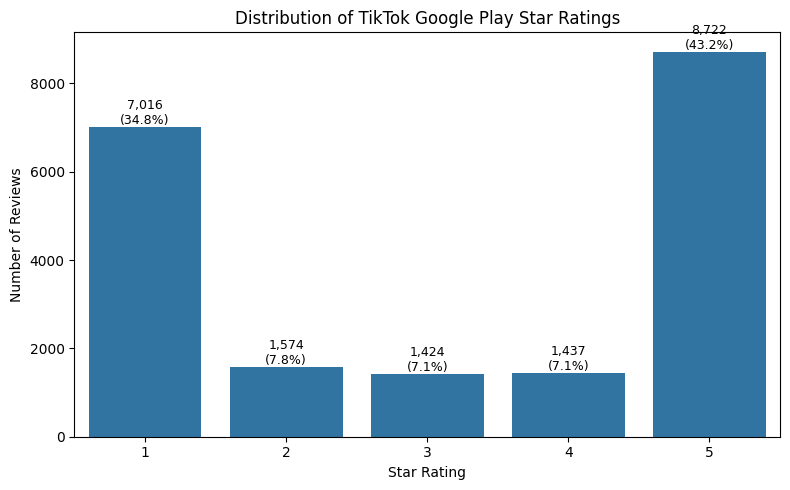

✅ Saved: /content/drive/MyDrive/SMC_Assignment/phase_04_eda/eda_rating_distribution.png


In [ ]:
rating_counts = (
    eda_df["rating"]
    .value_counts()
    .sort_index()
    .reindex(
        [1, 2, 3, 4, 5],
        fill_value=0
    )
)

rating_summary = pd.DataFrame({
    "rating": rating_counts.index.astype(int),
    "review_count": rating_counts.values,
    "percentage": (
        rating_counts.values
        / rating_counts.values.sum()
        * 100
    )
})

display(
    rating_summary.style.format({
        "review_count": "{:,.0f}",
        "percentage": "{:.2f}%"
    })
)

plt.figure(figsize=(8, 5))

axis = sns.barplot(
    data=rating_summary,
    x="rating",
    y="review_count"
)

axis.set_title(
    "Distribution of TikTok Google Play Star Ratings"
)
axis.set_xlabel("Star Rating")
axis.set_ylabel("Number of Reviews")

for bar, count, percentage in zip(
    axis.patches,
    rating_summary["review_count"],
    rating_summary["percentage"]
):
    axis.annotate(
        f"{int(count):,}\n({percentage:.1f}%)",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

EDA_RATING_FIGURE = os.path.join(
    EDA_OUTPUT_DIR,
    "eda_rating_distribution.png"
)

EDA_RATING_TABLE = os.path.join(
    EDA_OUTPUT_DIR,
    "eda_rating_distribution.csv"
)

plt.savefig(
    EDA_RATING_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

rating_summary.to_csv(
    EDA_RATING_TABLE,
    index=False
)

print(f"✅ Saved: {EDA_RATING_FIGURE}")

## 4.4 Review-Length Distribution

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
review_word_count,20173.0,20.386259,21.112526,2.0,6.0,12.0,27.0,51.0,72.0,92.0,118.0
review_character_count,20173.0,107.003371,114.760506,8.0,30.0,60.0,139.0,271.0,385.0,497.0,500.0
processed_word_count,20173.0,10.862688,11.059108,0.0,3.0,6.0,14.0,27.0,37.0,49.0,88.0


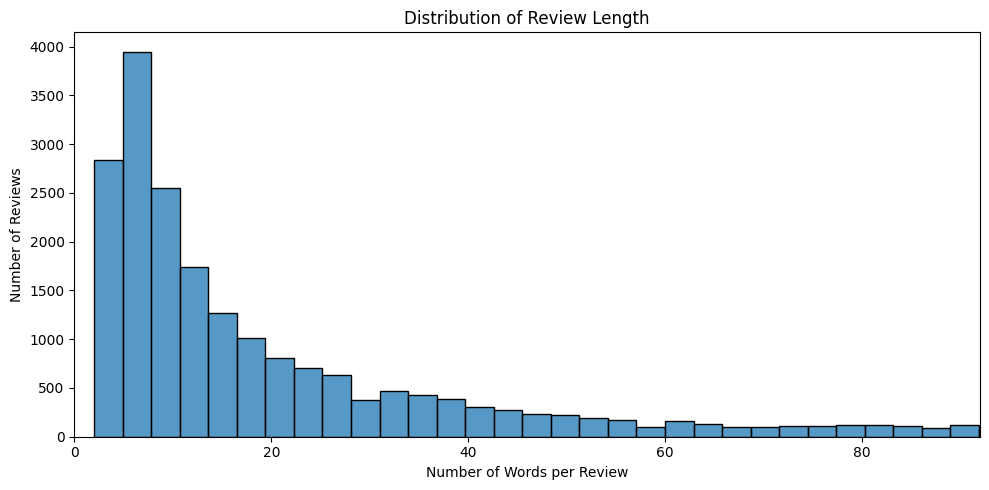

✅ Saved: /content/drive/MyDrive/SMC_Assignment/phase_04_eda/eda_review_length_distribution.png


In [ ]:
review_length_summary = (
    eda_df[
        [
            "review_word_count",
            "review_character_count",
            "processed_word_count"
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

display(review_length_summary)

word_count_cap = max(
    10,
    int(
        eda_df["review_word_count"]
        .quantile(0.99)
    )
)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="review_word_count",
    bins=40
)

plt.xlim(0, word_count_cap)
plt.title("Distribution of Review Length")
plt.xlabel("Number of Words per Review")
plt.ylabel("Number of Reviews")
plt.tight_layout()

EDA_LENGTH_FIGURE = os.path.join(
    EDA_OUTPUT_DIR,
    "eda_review_length_distribution.png"
)

EDA_LENGTH_TABLE = os.path.join(
    EDA_OUTPUT_DIR,
    "eda_review_length_summary.csv"
)

plt.savefig(
    EDA_LENGTH_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

review_length_summary.to_csv(
    EDA_LENGTH_TABLE
)

print(f"✅ Saved: {EDA_LENGTH_FIGURE}")

## 4.5 Review Activity Over Time

,month,review_count,average_rating
0,2026-04-01,4100,2.699512
1,2026-05-01,8718,3.225855
2,2026-06-01,7355,3.345071


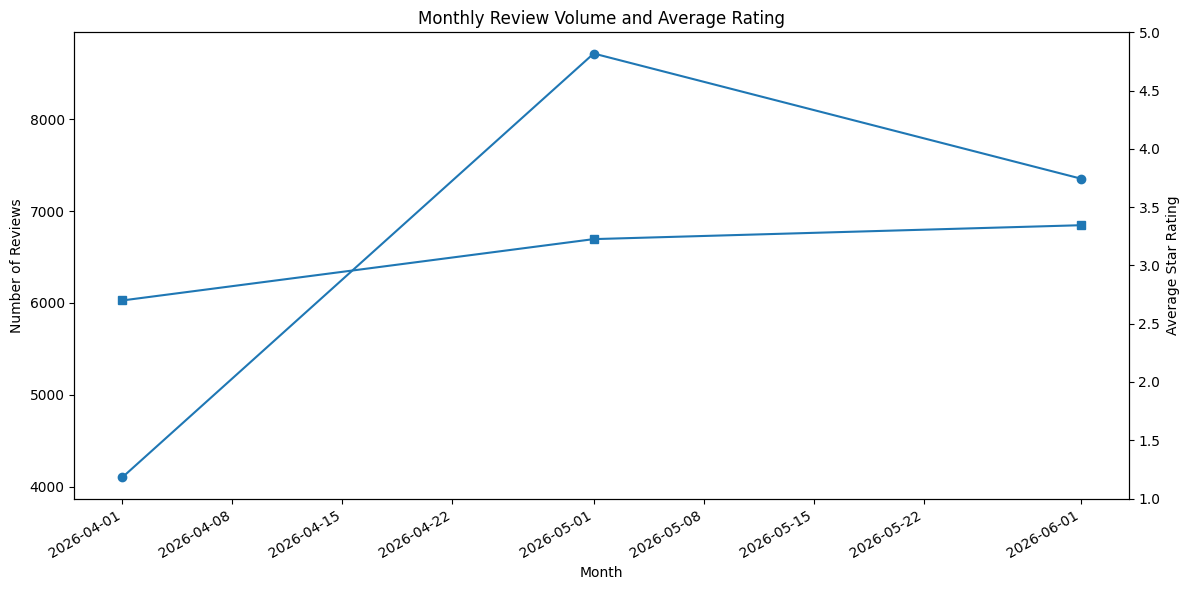

✅ Saved temporal summary: /content/drive/MyDrive/SMC_Assignment/phase_04_eda/eda_monthly_review_activity.csv


In [ ]:
valid_date_df = eda_df.dropna(
    subset=["date"]
).copy()

if valid_date_df.empty:
    print(
        "⚠️ No valid dates were available for temporal EDA."
    )

    monthly_review_summary = pd.DataFrame(
        columns=[
            "month",
            "review_count",
            "average_rating"
        ]
    )
else:
    valid_date_df["month"] = (
        valid_date_df["date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    monthly_review_summary = (
        valid_date_df
        .groupby("month")
        .agg(
            review_count=(
                "review_text",
                "size"
            ),
            average_rating=(
                "rating",
                "mean"
            )
        )
        .reset_index()
        .sort_values("month")
    )

    display(
        monthly_review_summary.tail(12)
    )

    figure, first_axis = plt.subplots(
        figsize=(12, 6)
    )

    first_axis.plot(
        monthly_review_summary["month"],
        monthly_review_summary["review_count"],
        marker="o"
    )

    first_axis.set_title(
        "Monthly Review Volume and Average Rating"
    )
    first_axis.set_xlabel("Month")
    first_axis.set_ylabel("Number of Reviews")

    second_axis = first_axis.twinx()

    second_axis.plot(
        monthly_review_summary["month"],
        monthly_review_summary["average_rating"],
        marker="s"
    )

    second_axis.set_ylabel(
        "Average Star Rating"
    )
    second_axis.set_ylim(1, 5)

    figure.autofmt_xdate()
    figure.tight_layout()

    EDA_TIME_FIGURE = os.path.join(
        EDA_OUTPUT_DIR,
        "eda_monthly_review_activity.png"
    )

    plt.savefig(
        EDA_TIME_FIGURE,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

EDA_TIME_TABLE = os.path.join(
    EDA_OUTPUT_DIR,
    "eda_monthly_review_activity.csv"
)

monthly_review_summary.to_csv(
    EDA_TIME_TABLE,
    index=False
)

print(f"✅ Saved temporal summary: {EDA_TIME_TABLE}")

## 4.6 Likes and App-Version Patterns

In [ ]:
likes_by_rating = (
    eda_df
    .groupby("rating")
    .agg(
        review_count=(
            "review_text",
            "size"
        ),
        average_likes=(
            "likes",
            "mean"
        ),
        median_likes=(
            "likes",
            "median"
        ),
        maximum_likes=(
            "likes",
            "max"
        )
    )
    .reset_index()
)

display(likes_by_rating)

if "app_version" in eda_df.columns:
    app_version_summary = (
        eda_df["app_version"]
        .fillna("Unknown")
        .astype(str)
        .value_counts()
        .head(15)
        .rename_axis("app_version")
        .reset_index(name="review_count")
    )
else:
    app_version_summary = pd.DataFrame(
        columns=[
            "app_version",
            "review_count"
        ]
    )

display(app_version_summary)

EDA_LIKES_TABLE = os.path.join(
    EDA_OUTPUT_DIR,
    "eda_likes_by_rating.csv"
)

EDA_VERSION_TABLE = os.path.join(
    EDA_OUTPUT_DIR,
    "eda_top_app_versions.csv"
)

likes_by_rating.to_csv(
    EDA_LIKES_TABLE,
    index=False
)

app_version_summary.to_csv(
    EDA_VERSION_TABLE,
    index=False
)

print("✅ Engagement and app-version summaries saved.")

,rating,review_count,average_likes,median_likes,maximum_likes
0,1,7016,7.658780,0.0,13015
1,2,1574,15.080051,1.0,11100
2,3,1424,10.488062,0.0,6976
3,4,1437,1.389701,0.0,74
4,5,8722,1.135749,0.0,1827


,app_version,review_count
0,unknown,5960
1,45.0.3,2056
2,45.5.4,1637
3,45.4.3,1413
4,44.8.3,1323
5,44.9.3,1289
6,45.3.3,1118
7,45.2.3,1068
8,44.6.4,1039
9,45.7.3,330


✅ Engagement and app-version summaries saved.


## 4.7 Frequent Terms and Phrases Before Labeling

📊 Most Frequent Unigrams


,term,frequency
0,app,9443
1,not,9364
2,tiktok,5939
3,video,3594
4,good,3139
5,account,3116
6,please,2646
7,get,2517
8,like,2232
9,ai,2202



📊 Most Frequent Bigrams


,term,frequency
0,good app,761
1,tik tok,633
2,love app,603
3,not work,504
4,tiktok team,490
5,app not,485
6,not even,477
7,best app,453
8,tiktok account,367
9,not know,366


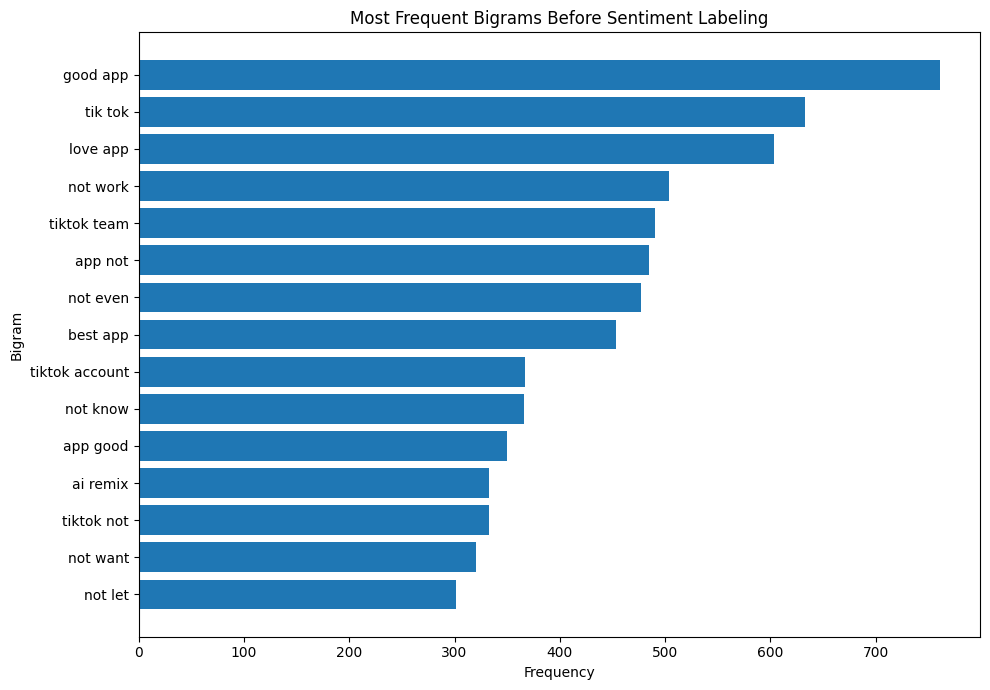

✅ Saved: /content/drive/MyDrive/SMC_Assignment/phase_04_eda/eda_top_bigrams.png


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


def extract_eda_terms(
    text_series,
    ngram_range,
    top_n=20,
    min_df=2
):
    clean_text = (
        text_series
        .fillna("")
        .astype(str)
    )

    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        min_df=min_df,
        max_features=10_000
    )

    matrix = vectorizer.fit_transform(
        clean_text
    )

    frequencies = np.asarray(
        matrix.sum(axis=0)
    ).ravel()

    return (
        pd.DataFrame({
            "term": (
                vectorizer
                .get_feature_names_out()
            ),
            "frequency": frequencies
        })
        .sort_values(
            "frequency",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


eda_top_unigrams = extract_eda_terms(
    eda_df["processed_text"],
    ngram_range=(1, 1),
    top_n=20
)

eda_top_bigrams = extract_eda_terms(
    eda_df["processed_text"],
    ngram_range=(2, 2),
    top_n=20
)

print("📊 Most Frequent Unigrams")
display(eda_top_unigrams)

print("\n📊 Most Frequent Bigrams")
display(eda_top_bigrams)

plt.figure(figsize=(10, 7))

plot_data = (
    eda_top_bigrams
    .head(15)
    .sort_values(
        "frequency",
        ascending=True
    )
)

plt.barh(
    plot_data["term"],
    plot_data["frequency"]
)

plt.title(
    "Most Frequent Bigrams Before Sentiment Labeling"
)
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.tight_layout()

EDA_BIGRAM_FIGURE = os.path.join(
    EDA_OUTPUT_DIR,
    "eda_top_bigrams.png"
)

plt.savefig(
    EDA_BIGRAM_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

eda_top_unigrams.to_csv(
    os.path.join(
        EDA_OUTPUT_DIR,
        "eda_top_unigrams.csv"
    ),
    index=False
)

eda_top_bigrams.to_csv(
    os.path.join(
        EDA_OUTPUT_DIR,
        "eda_top_bigrams.csv"
    ),
    index=False
)

print(f"✅ Saved: {EDA_BIGRAM_FIGURE}")

## 4.8 EDA Output Manifest

In [ ]:
eda_manifest = pd.DataFrame([
    {
        "output": "Dataset overview",
        "file": EDA_OVERVIEW_FILE
    },
    {
        "output": "Missing-value summary",
        "file": EDA_MISSING_FILE
    },
    {
        "output": "Rating distribution",
        "file": EDA_RATING_FIGURE
    },
    {
        "output": "Review-length distribution",
        "file": EDA_LENGTH_FIGURE
    },
    {
        "output": "Monthly review activity",
        "file": EDA_TIME_TABLE
    },
    {
        "output": "Likes by rating",
        "file": EDA_LIKES_TABLE
    },
    {
        "output": "Top app versions",
        "file": EDA_VERSION_TABLE
    },
    {
        "output": "Top bigrams",
        "file": EDA_BIGRAM_FIGURE
    }
])

EDA_MANIFEST_FILE = os.path.join(
    EDA_OUTPUT_DIR,
    "eda_output_manifest.csv"
)

eda_manifest.to_csv(
    EDA_MANIFEST_FILE,
    index=False
)

display(eda_manifest)

print(
    f"✅ Phase 4 EDA completed. Manifest saved to: "
    f"{EDA_MANIFEST_FILE}"
)

,output,file
0,Dataset overview,/content/drive/MyDrive/SMC_Assignment/phase_04...
1,Missing-value summary,/content/drive/MyDrive/SMC_Assignment/phase_04...
2,Rating distribution,/content/drive/MyDrive/SMC_Assignment/phase_04...
3,Review-length distribution,/content/drive/MyDrive/SMC_Assignment/phase_04...
4,Monthly review activity,/content/drive/MyDrive/SMC_Assignment/phase_04...
5,Likes by rating,/content/drive/MyDrive/SMC_Assignment/phase_04...
6,Top app versions,/content/drive/MyDrive/SMC_Assignment/phase_04...
7,Top bigrams,/content/drive/MyDrive/SMC_Assignment/phase_04...


✅ Phase 4 EDA completed. Manifest saved to: /content/drive/MyDrive/SMC_Assignment/phase_04_eda/eda_output_manifest.csv


---
# Phase 5: Sentiment Labeling Strategy

## 4.5 Labeling Strategy

VADER is used to assign text-based pseudo-labels because manually labeling the full review dataset is impractical. The compound score is calculated from the original `review_text`, preserving punctuation, capitalization, emojis and intensifiers. The standard thresholds classify each review as positive, neutral or negative.

- Compound score ≥ 0.05: **positive**
- Compound score ≤ −0.05: **negative**
- Otherwise: **neutral**

These labels are treated as automated pseudo-labels rather than human-verified ground truth.

## 5.1 Labeling Environment and Imports

In [ ]:
# ─────────────────────────────────────────────
# PHASE 5 — INSTALL & IMPORTS
# ─────────────────────────────────────────────
!pip install vaderSentiment --quiet

import pandas as pd
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print("✅ VADER installed and imported.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.6 MB/s eta 0:00:00
✅ VADER installed and imported.


## 5.2 Load the Phase 3 Processed Dataset

In [ ]:
# ─────────────────────────────────────────────
# LOAD PROCESSED DATASET FROM PHASE 2
# ─────────────────────────────────────────────

INPUT_FILE = os.path.join(PHASE_03_DIR, 'TikTok_Reviews_Phase3_Processed.csv')

df = pd.read_csv(INPUT_FILE, index_col='review_id')

print(f"✅ Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"   Columns: {list(df.columns)}")
df.head(3)

✅ Loaded dataset: 20,173 rows, 9 columns
   Columns: ['username', 'rating', 'review_text', 'date', 'likes', 'app_version', 'corrected_text', 'tokens', 'processed_text']


,username,rating,review_text,date,likes,app_version,corrected_text,tokens,processed_text
review_id,,,,,,,,,
0,Rawa Friday,1,fleczy dee a boat plug am active for anything ...,2026-06-24 17:42,0,45.7.3,sleazy dee a boat plug am active for anything ...,sleazy|dee|boat|plug|active|anything|water|lik...,sleazy dee boat plug active anything water lik...
1,Fuwad amad Mume,5,Rate this app,2026-06-24 17:42,0,unknown,rate this app,rate|app,rate app
2,Nick M,1,tiktok your board members are looking real cut...,2026-06-24 17:41,2,45.5.4,tiktok your board members are looking real cut...,tiktok|board|member|look|real|cute|right|expla...,tiktok board member look real cute right expla...


## 5.3 Compute VADER Scores and Assign Labels

In [ ]:
# ─────────────────────────────────────────────
# STEP 4.1–4.2 — COMPUTE VADER SCORE & ASSIGN LABEL
# ─────────────────────────────────────────────

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm import tqdm
import nltk

nltk.download('vader_lexicon', quiet=True)

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Domain-specific terms frequently found in mobile-app reviews
custom_lexicon = {
    # Technical failures
    'crashing': -3.0,
    'crash': -3.0,
    'crashes': -3.0,
    'bug': -2.5,
    'bugs': -2.5,
    'glitch': -2.5,
    'glitches': -2.5,
    'glitchy': -2.5,
    'error': -2.5,
    'frozen': -2.0,
    'freeze': -2.0,
    'freezing': -2.0,
    'lag': -2.0,
    'laggy': -2.0,
    'lagging': -2.0,
    'broken': -2.5,
    'issue': -2.0,
    'issues': -2.0,

    # Account and moderation frustrations
    'shadowban': -2.5,
    'shadowbanned': -2.5,
    'banned': -2.5,
    'suspended': -2.0,
    'violation': -2.0,
    'guidelines': -1.5,
    'muted': -2.0,
    'copyright': -1.5,
    'deleted': -2.0,
    'unfollowed': -2.0,

    # User experience and spam
    'bots': -2.0,
    'scam': -2.0,
    'scammers': -2.0,
    'spam': -1.5,
    'fake': -1.5,
    'ruined': -2.5,
    'useless': -2.5,
    'worst': -3.0
}

analyzer.lexicon.update(custom_lexicon)


def get_vader_label(text: str):
    """Return a VADER pseudo-label and compound score for original review text."""
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']

    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'

    return label, round(compound, 4)


# IMPORTANT: VADER must use the original review text because punctuation,
# capitalisation, intensifiers and emojis contribute to its score.
tqdm.pandas(desc="VADER sentiment scoring")
results = (
    df['review_text']
    .fillna('')
    .astype(str)
    .progress_apply(get_vader_label)
)

df['sentiment_label'] = results.apply(lambda result: result[0])
df['vader_compound'] = results.apply(lambda result: result[1])

print("\n✅ VADER pseudo-labeling complete using original review text.")
print(df[['review_text', 'vader_compound', 'sentiment_label']].head(5))

VADER sentiment scoring: 100%|██████████| 20173/20173 [00:10<00:00, 1876.78it/s]



✅ VADER pseudo-labeling complete using original review text.
                                                 review_text  vader_compound  \
review_id                                                                      
0          fleczy dee a boat plug am active for anything ...          0.6369   
1                                              Rate this app          0.0000   
2          tiktok your board members are looking real cut...          0.7219   
3                    good but add a remove all repost button          0.2382   
4          love all the videos from funny to sad , real a...          0.6124   

          sentiment_label  
review_id                  
0                positive  
1                 neutral  
2                positive  
3                positive  
4                positive  


## 5.4 Review the Label Distribution

In [ ]:
# ─────────────────────────────────────────────
# STEP 4.3 — LABEL DISTRIBUTION & SAMPLE REVIEW
# ─────────────────────────────────────────────

print("=" * 55)
print("  PHASE 5 — LABELING SUMMARY")
print("=" * 55)

label_counts = df['sentiment_label'].value_counts()
label_pct = df['sentiment_label'].value_counts(normalize=True) * 100

for label in ['positive', 'neutral', 'negative']:
    count = label_counts.get(label, 0)
    pct = label_pct.get(label, 0)
    print(f"  {label.capitalize():<10}: {count:>8,} reviews  ({pct:>5.1f}%)")

print("=" * 55)

print("\n📋 Sample reviews per sentiment label:")
for label in ['positive', 'neutral', 'negative']:
    sample = df[df['sentiment_label'] == label].sample(1, random_state=42)
    text = sample['review_text'].values[0]
    score = sample['vader_compound'].values[0]
    print(f"\n  [{label.upper()}] (compound = {score})")
    print(f"  \"{text[:150]}\"")

  PHASE 5 — LABELING SUMMARY
  Positive  :   10,567 reviews  ( 52.4%)
  Neutral   :    3,209 reviews  ( 15.9%)
  Negative  :    6,397 reviews  ( 31.7%)

📋 Sample reviews per sentiment label:

  [POSITIVE] (compound = 0.3996)
  "a really good video sharing app! but the problem is that I am on iPad. and I will not let me share videos with my friends"

  [NEUTRAL] (compound = 0.0)
  "waest of time"

  [NEGATIVE] (compound = -0.798)
  "STOP WITH THE AI OMG I know you losers are being paid big money by these ai corporations but it's Not Going To Happen. Every time I figure out how to "


## 5.5 Visualize the Label Distribution

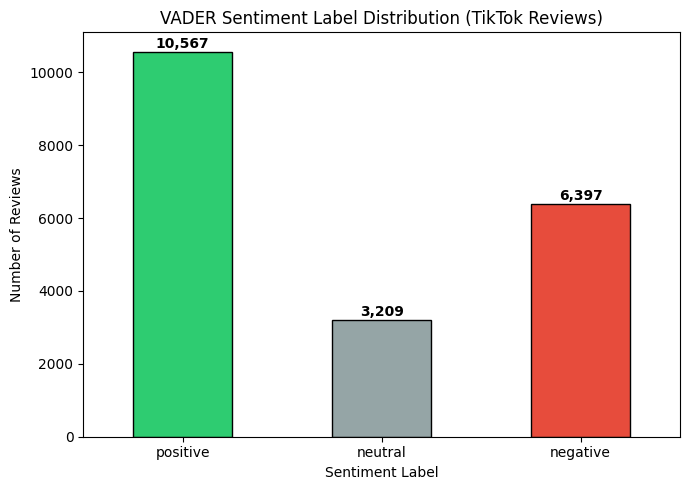

In [ ]:
# ─────────────────────────────────────────────
# VISUALIZATION — SENTIMENT LABEL DISTRIBUTION
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt

colors = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
order = ['positive', 'neutral', 'negative']
counts = df['sentiment_label'].value_counts().reindex(order)

plt.figure(figsize=(7, 5))
counts.plot(kind='bar', color=[colors[l] for l in order], edgecolor='black')
plt.title('VADER Sentiment Label Distribution (TikTok Reviews)')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    plt.text(i, v + max(counts) * 0.01, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PHASE_05_DIR, 'phase5_sentiment_distribution.png'), dpi=150)
plt.show()

## 5.6 Save the Labeled Dataset

In [ ]:
# ─────────────────────────────────────────────
# SAVE PHASE 5 OUTPUT
# ─────────────────────────────────────────────

OUTPUT_FILE = os.path.join(PHASE_05_DIR, 'TikTok_Reviews_Phase5_Labeled.csv')

df.to_csv(OUTPUT_FILE, index=True)

print("✅ Phase 5 labeled dataset saved!")
print(f"   File   : {OUTPUT_FILE}")
print(f"   Rows   : {len(df):,}")
print(f"   Columns: {list(df.columns)}")
print()
print("👉 Next step: Phase 5 — Train/Validation/Test Split (Section 4.6)")

✅ Phase 5 labeled dataset saved!
   File   : /content/drive/MyDrive/SMC_Assignment/phase_05_sentiment_labeling/TikTok_Reviews_Phase5_Labeled.csv
   Rows   : 20,173
   Columns: ['username', 'rating', 'review_text', 'date', 'likes', 'app_version', 'corrected_text', 'tokens', 'processed_text', 'sentiment_label', 'vader_compound']

👉 Next step: Phase 5 — Train/Validation/Test Split (Section 4.6)


---
# Phase 6: Train, Validation and Test Split

## 4.6 Train / Validation / Test Split

The labeled dataset is divided into 70% training, 15% validation and 15% test data. Stratification preserves the positive, neutral and negative class proportions. The test split remains untouched until final model evaluation.

## 6.1 Load the Labeled Dataset

In [ ]:
# ─────────────────────────────────────────────
# PHASE 6 — IMPORTS & LOAD LABELED DATASET
# ─────────────────────────────────────────────

import pandas as pd
from sklearn.model_selection import train_test_split

INPUT_FILE = os.path.join(PHASE_05_DIR, 'TikTok_Reviews_Phase5_Labeled.csv')

df = pd.read_csv(INPUT_FILE, index_col='review_id')

print(f"✅ Loaded labeled dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"   Columns: {list(df.columns)}")
print()
print("Label distribution (full dataset):")
counts = df['sentiment_label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<10}: {count:>7,}  ({count/len(df)*100:.1f}%)")

✅ Loaded labeled dataset: 20,173 rows, 11 columns
   Columns: ['username', 'rating', 'review_text', 'date', 'likes', 'app_version', 'corrected_text', 'tokens', 'processed_text', 'sentiment_label', 'vader_compound']

Label distribution (full dataset):
  positive  :  10,567  (52.4%)
  negative  :   6,397  (31.7%)
  neutral   :   3,209  (15.9%)


## 6.2 Create the Stratified Splits

In [ ]:
# ─────────────────────────────────────────────
# PHASE 6 — STRATIFIED TRAIN / VAL / TEST SPLIT
# ─────────────────────────────────────────────

# Features passed to models — keep all columns except the label itself
FEATURE_COLS = ['review_text', 'processed_text', 'tokens', 'rating']
LABEL_COL    = 'sentiment_label'

# Keep only columns that exist in the dataframe (safe guard)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS]
y = df[LABEL_COL]

# ── Step 1: Split off test set (15%) ─────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# ── Step 2: Split remaining 85% into train (70%) and val (15%) ───
# val_size relative to X_temp = 0.15 / 0.85 ≈ 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

print(f"✅ Split complete.")
print(f"   Train : {len(X_train):>7,} rows  ({len(X_train)/len(df)*100:.1f}%)")
print(f"   Val   : {len(X_val):>7,} rows  ({len(X_val)/len(df)*100:.1f}%)")
print(f"   Test  : {len(X_test):>7,} rows  ({len(X_test)/len(df)*100:.1f}%)")

✅ Split complete.
   Train :  14,120 rows  (70.0%)
   Val   :   3,027 rows  (15.0%)
   Test  :   3,026 rows  (15.0%)


## 6.3 Verify Class Proportions

In [ ]:
# ─────────────────────────────────────────────
# VERIFY STRATIFICATION ACROSS ALL THREE SPLITS
# ─────────────────────────────────────────────

print("=" * 58)
print(f"  {'Label':<12} {'Train':>10} {'Val':>10} {'Test':>10}")
print("=" * 58)

for label in ['positive', 'neutral', 'negative']:
    tr = (y_train == label).sum()
    va = (y_val   == label).sum()
    te = (y_test  == label).sum()
    tr_pct = tr / len(y_train) * 100
    va_pct = va / len(y_val)   * 100
    te_pct = te / len(y_test)  * 100
    print(f"  {label:<12} {tr:>5,} ({tr_pct:.1f}%)  {va:>5,} ({va_pct:.1f}%)  {te:>5,} ({te_pct:.1f}%)")

print("=" * 58)
print()
print("✅ Stratification verified — label proportions are consistent across all splits.")

  Label             Train        Val       Test
  positive     7,396 (52.4%)  1,586 (52.4%)  1,585 (52.4%)
  neutral      2,247 (15.9%)    481 (15.9%)    481 (15.9%)
  negative     4,477 (31.7%)    960 (31.7%)    960 (31.7%)

✅ Stratification verified — label proportions are consistent across all splits.


## 6.4 Save the Three Splits

In [ ]:
# ─────────────────────────────────────────────
# SAVE ALL THREE SPLITS TO DRIVE
# ─────────────────────────────────────────────

# Reconstruct full split DataFrames (features + label)
train_df = X_train.copy(); train_df[LABEL_COL] = y_train
val_df   = X_val.copy();   val_df[LABEL_COL]   = y_val
test_df  = X_test.copy();  test_df[LABEL_COL]  = y_test

train_df.to_csv(os.path.join(PHASE_06_DIR, 'TikTok_Split_Train.csv'), index=True)
val_df.to_csv(os.path.join(PHASE_06_DIR, 'TikTok_Split_Val.csv'), index=True)
test_df.to_csv(os.path.join(PHASE_06_DIR, 'TikTok_Split_Test.csv'), index=True)

print("✅ All splits saved to Google Drive!")
print(f"   TikTok_Split_Train.csv — {len(train_df):,} rows")
print(f"   TikTok_Split_Val.csv   — {len(val_df):,} rows")
print(f"   TikTok_Split_Test.csv  — {len(test_df):,} rows")
print()
print("👉 Next step: Phase 6 — Feature Engineering (Section 4.7)")

✅ All splits saved to Google Drive!
   TikTok_Split_Train.csv — 14,120 rows
   TikTok_Split_Val.csv   — 3,027 rows
   TikTok_Split_Test.csv  — 3,026 rows

👉 Next step: Phase 6 — Feature Engineering (Section 4.7)


---
# Phase 7: Feature Engineering

## 4.7 Feature Engineering

Three input representations are prepared:

1. TF-IDF features for SVM.
2. Token sequences and trainable embeddings for GRU.
3. Contextual WordPiece tokens for BERT.

All vocabularies and preprocessing objects are fitted only on the training data to prevent data leakage.

## 7.1 Load the Saved Splits

In [ ]:
import pandas as pd
import numpy as np
import os

# Load the split datasets
print("📥 Loading Train, Val, and Test splits...")
train_df = pd.read_csv(os.path.join(PHASE_06_DIR, 'TikTok_Split_Train.csv'))
val_df = pd.read_csv(os.path.join(PHASE_06_DIR, 'TikTok_Split_Val.csv'))
test_df = pd.read_csv(os.path.join(PHASE_06_DIR, 'TikTok_Split_Test.csv'))

# Handle any NaN values that might have appeared during CSV saving
for df in [train_df, val_df, test_df]:
    df['processed_text'] = df['processed_text'].fillna('')
    df['tokens'] = df['tokens'].fillna('')
    df['review_text'] = df['review_text'].fillna('')

print(f"✅ Loaded successfully! Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

📥 Loading Train, Val, and Test splits...
✅ Loaded successfully! Train: 14120, Val: 3027, Test: 3026


## 7.2 TF-IDF Features for SVM

TF-IDF converts processed reviews into sparse vectors. The vectorizer is fitted only on the training split and saved for later evaluation and inference.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

print("⚙️ Building TF-IDF Vectorizer (for SVM)...")

# Initialize the Vectorizer
# max_features=5000 is a standard starting point for NLP to prevent memory crashes
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# FIT ONLY ON TRAIN DATA! (Prevents data leakage)
# Then immediately transform the train data
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['processed_text'])

# TRANSFORM ONLY for Val and Test data
X_val_tfidf = tfidf_vectorizer.transform(val_df['processed_text'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['processed_text'])

print(f"✅ TF-IDF Matrix Shapes:")
print(f"   Train: {X_train_tfidf.shape}")
print(f"   Val:   {X_val_tfidf.shape}")
print(f"   Test:  {X_test_tfidf.shape}")

# Optional: Save the vectorizer to use later
with open(os.path.join(PHASE_07_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

⚙️ Building TF-IDF Vectorizer (for SVM)...
✅ TF-IDF Matrix Shapes:
   Train: (14120, 5000)
   Val:   (3027, 5000)
   Test:  (3026, 5000)


## 7.3 Token Sequences and Padding for GRU

The GRU receives integer sequences. A training-only tokenizer is saved, and sequence length is selected from the training distribution.

In [ ]:
# ─────────────────────────────────────────────
# 6.3 DEEP LEARNING: TOKEN SEQUENCES AND PADDING
# ─────────────────────────────────────────────

import os
import json
import pickle
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("⚙️ Preparing Token Sequences for GRU...")


def prepare_token_text(text_series):
    """
    Convert token lists or CSV-loaded token strings into clean text.

    This keeps the tokenizer input consistent whether the notebook is run
    directly after preprocessing or restarted from saved CSV files.
    """
    return text_series.fillna("").apply(
        lambda value: " ".join(value) if isinstance(value, list) else str(value)
    )


train_token_text = prepare_token_text(train_df["tokens"])
val_token_text = prepare_token_text(val_df["tokens"])
test_token_text = prepare_token_text(test_df["tokens"])

# Limit extremely rare words while retaining enough vocabulary for this dataset.
MAX_VOCAB_SIZE = 15_000

dl_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<OOV>"
)

# Fit only on the training split to prevent data leakage.
dl_tokenizer.fit_on_texts(train_token_text)

vocab_size = min(
    MAX_VOCAB_SIZE,
    len(dl_tokenizer.word_index) + 1
)

print(f"   Full learned vocabulary : {len(dl_tokenizer.word_index):,}")
print(f"   Vocabulary used by GRU  : {vocab_size:,}")

X_train_seq = dl_tokenizer.texts_to_sequences(train_token_text)
X_val_seq = dl_tokenizer.texts_to_sequences(val_token_text)
X_test_seq = dl_tokenizer.texts_to_sequences(test_token_text)

# Select the sequence length using training data only.
train_sequence_lengths = np.asarray(
    [len(sequence) for sequence in X_train_seq],
    dtype=np.int32
)

MAX_SEQUENCE_LENGTH = int(
    np.clip(
        np.percentile(train_sequence_lengths, 95),
        30,
        80
    )
)

print(f"   Selected sequence length: {MAX_SEQUENCE_LENGTH} tokens")

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("\n✅ Padded Sequence Shapes:")
print(f"   Train: {X_train_pad.shape}")
print(f"   Val:   {X_val_pad.shape}")
print(f"   Test:  {X_test_pad.shape}")

# Save the tokenizer and preprocessing configuration for evaluation/inference.
DL_TOKENIZER_FILE = os.path.join(PHASE_07_DIR, 'dl_tokenizer.pkl')
GRU_CONFIG_FILE = os.path.join(PHASE_07_DIR, 'gru_preprocessing_config.json')

with open(DL_TOKENIZER_FILE, "wb") as file:
    pickle.dump(dl_tokenizer, file)

gru_preprocessing_config = {
    "max_vocabulary_size": int(MAX_VOCAB_SIZE),
    "vocabulary_size_used": int(vocab_size),
    "max_sequence_length": int(MAX_SEQUENCE_LENGTH),
    "padding": "post",
    "truncating": "post",
    "oov_token": "<OOV>"
}

with open(GRU_CONFIG_FILE, "w", encoding="utf-8") as file:
    json.dump(gru_preprocessing_config, file, indent=2)

print(f"\n💾 Tokenizer saved: {DL_TOKENIZER_FILE}")
print(f"💾 GRU preprocessing configuration saved: {GRU_CONFIG_FILE}")

⚙️ Preparing Token Sequences for GRU...
   Full learned vocabulary : 6,963
   Vocabulary used by GRU  : 6,964
   Selected sequence length: 37 tokens

✅ Padded Sequence Shapes:
   Train: (14120, 37)
   Val:   (3027, 37)
   Test:  (3026, 37)

💾 Tokenizer saved: /content/drive/MyDrive/SMC_Assignment/phase_07_feature_engineering/dl_tokenizer.pkl
💾 GRU preprocessing configuration saved: /content/drive/MyDrive/SMC_Assignment/phase_07_feature_engineering/gru_preprocessing_config.json


## 7.4 Contextual Tokenization for BERT

BERT tokenization uses the original review text. The tokenized arrays and tokenizer are saved so model training uses the exact same inputs.

In [ ]:
from transformers import AutoTokenizer
import os
import numpy as np

print("⚙️ Preparing Contextual Tokenization (for BERT)...")

BERT_MODEL_NAME = 'bert-base-uncased'
BERT_MAX_LENGTH = 64

# Load the tokenizer that matches the pre-trained BERT model
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)


def tokenize_for_bert(text_series, max_len=BERT_MAX_LENGTH):
    """Batch-tokenize a Pandas Series for BERT."""
    clean_text = text_series.fillna('').astype(str).tolist()

    return bert_tokenizer(
        clean_text,
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='np'
    )


print("   Tokenizing Train...")
X_train_bert = tokenize_for_bert(train_df['review_text'])

print("   Tokenizing Val...")
X_val_bert = tokenize_for_bert(val_df['review_text'])

print("   Tokenizing Test...")
X_test_bert = tokenize_for_bert(test_df['review_text'])

print("✅ BERT Tokenization Complete!")
print(f"   Train input_ids shape      : {X_train_bert['input_ids'].shape}")
print(f"   Train attention_mask shape : {X_train_bert['attention_mask'].shape}")

# Save the tokenized arrays so Phase 7 can reload and model the exact same inputs
BERT_TOKENIZED_FILE = os.path.join(PHASE_07_DIR, 'tiktok_bert_tokenized_data.npz')

bert_arrays_to_save = {
    'train_input_ids': X_train_bert['input_ids'],
    'train_attention_mask': X_train_bert['attention_mask'],
    'val_input_ids': X_val_bert['input_ids'],
    'val_attention_mask': X_val_bert['attention_mask'],
    'test_input_ids': X_test_bert['input_ids'],
    'test_attention_mask': X_test_bert['attention_mask']
}

# BERT tokenizers may also produce token_type_ids
if 'token_type_ids' in X_train_bert:
    bert_arrays_to_save.update({
        'train_token_type_ids': X_train_bert['token_type_ids'],
        'val_token_type_ids': X_val_bert['token_type_ids'],
        'test_token_type_ids': X_test_bert['token_type_ids']
    })

np.savez_compressed(BERT_TOKENIZED_FILE, **bert_arrays_to_save)

# Save the matching tokenizer separately from the trained model
BERT_TOKENIZER_DIR = os.path.join(PHASE_07_DIR, 'tiktok_bert_tokenizer')
os.makedirs(BERT_TOKENIZER_DIR, exist_ok=True)
bert_tokenizer.save_pretrained(BERT_TOKENIZER_DIR)

print("✅ BERT tokenized arrays and tokenizer saved to Google Drive.")
print(f"   Arrays   : {BERT_TOKENIZED_FILE}")
print(f"   Tokenizer: {BERT_TOKENIZER_DIR}")

⚙️ Preparing Contextual Tokenization (for BERT)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

   Tokenizing Train...
   Tokenizing Val...
   Tokenizing Test...
✅ BERT Tokenization Complete!
   Train input_ids shape      : (14120, 64)
   Train attention_mask shape : (14120, 64)
✅ BERT tokenized arrays and tokenizer saved to Google Drive.
   Arrays   : /content/drive/MyDrive/SMC_Assignment/phase_07_feature_engineering/tiktok_bert_tokenized_data.npz
   Tokenizer: /content/drive/MyDrive/SMC_Assignment/phase_07_feature_engineering/tiktok_bert_tokenizer


---
# Phase 8: Modeling Approach

## 4.8 Modeling Approach

SVM, GRU and BERT are trained on the same sentiment task. Labels are encoded once and the encoder is saved to maintain the same class order across training, evaluation and inference.

## 8.0 Install the Hugging Face Training Dependency

In [ ]:
!pip install accelerate -U

## 8.1 Encode and Save Sentiment Labels

In [ ]:
from sklearn.preprocessing import LabelEncoder
import os
import json
import pickle

print("⚙️ Encoding Labels for Neural Networks...")

label_encoder = LabelEncoder()

# Fit only on training labels, then apply the same mapping to validation and test
y_train_enc = label_encoder.fit_transform(train_df['sentiment_label'])
y_val_enc = label_encoder.transform(val_df['sentiment_label'])
y_test_enc = label_encoder.transform(test_df['sentiment_label'])

mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_).tolist()
    )
)

print(f"✅ Label Mapping: {mapping}")

# Save the encoder so evaluation uses exactly the same class mapping
LABEL_ENCODER_FILE = os.path.join(PHASE_07_DIR, 'label_encoder.pkl')
with open(LABEL_ENCODER_FILE, 'wb') as file:
    pickle.dump(label_encoder, file)

with open(os.path.join(PHASE_07_DIR, 'label_mapping.json'), 'w', encoding='utf-8') as file:
    json.dump(mapping, file, indent=2)

print(f"💾 Label encoder saved: {LABEL_ENCODER_FILE}")

⚙️ Encoding Labels for Neural Networks...
✅ Label Mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
💾 Label encoder saved: /content/drive/MyDrive/SMC_Assignment/phase_07_feature_engineering/label_encoder.pkl


## 8.2 Support Vector Machine

LinearSVC is trained on the TF-IDF representation and evaluated on the validation split before being saved.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
import time

print("🚀 Training SVM Model...")

svm_model = LinearSVC(
    max_iter=5000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

svm_start_time = time.time()
svm_model.fit(X_train_tfidf, y_train_enc)
svm_training_seconds = time.time() - svm_start_time

# Validation is used for an early performance check only
svm_val_preds = svm_model.predict(X_val_tfidf)
svm_val_acc = accuracy_score(y_val_enc, svm_val_preds)
svm_val_macro_f1 = f1_score(
    y_val_enc,
    svm_val_preds,
    average='macro',
    zero_division=0
)

print("✅ SVM Training Complete!")
print(f"📊 Validation Accuracy : {svm_val_acc * 100:.2f}%")
print(f"📊 Validation Macro F1 : {svm_val_macro_f1:.4f}")
print(f"⏱️ Training Time       : {svm_training_seconds:.2f} seconds")

🚀 Training SVM Model...
✅ SVM Training Complete!
📊 Validation Accuracy : 82.69%
📊 Validation Macro F1 : 0.7997
⏱️ Training Time       : 1.20 seconds


### 8.2.1 Save the Trained SVM

In [ ]:
# SAVE TRAINED SVM MODEL TO GOOGLE DRIVE
import os
import pickle

SVM_MODEL_FILE = os.path.join(PHASE_08_SVM_DIR, 'tiktok_svm_model.pkl')

print(f"💾 Saving SVM model to: {SVM_MODEL_FILE}")

with open(SVM_MODEL_FILE, 'wb') as file:
    pickle.dump(svm_model, file)

print("✅ SVM model saved successfully!")

💾 Saving SVM model to: /content/drive/MyDrive/SMC_Assignment/phase_08_model_training/svm/tiktok_svm_model.pkl
✅ SVM model saved successfully!


## 8.3 Gated Recurrent Unit

The GRU uses masking for padded values, softened class weights, early stopping, learning-rate reduction and checkpointing. cuDNN is disabled to safely support the generated sequence masks.

In [ ]:
# ─────────────────────────────────────────────
# 7.3 DEEP LEARNING: IMPROVED GRU MODEL
# ─────────────────────────────────────────────

import os
import random
import time
import numpy as np
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    GRU,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("🚀 Building and Training Improved GRU Model...")

# ------------------------------------------------------------
# 1. Clear previous TensorFlow model
# ------------------------------------------------------------

tf.keras.backend.clear_session()

# ------------------------------------------------------------
# 2. Reproducibility
# ------------------------------------------------------------

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Prevent TensorFlow from reserving all GPU memory
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(
            gpu,
            True
        )
    except RuntimeError:
        pass

# ------------------------------------------------------------
# 3. Validate and standardise input arrays
# ------------------------------------------------------------

X_train_pad = np.asarray(
    X_train_pad,
    dtype=np.int32
)

X_val_pad = np.asarray(
    X_val_pad,
    dtype=np.int32
)

X_test_pad = np.asarray(
    X_test_pad,
    dtype=np.int32
)

y_train_enc = np.asarray(
    y_train_enc,
    dtype=np.int32
)

y_val_enc = np.asarray(
    y_val_enc,
    dtype=np.int32
)

y_test_enc = np.asarray(
    y_test_enc,
    dtype=np.int32
)

if X_train_pad.ndim != 2:
    raise ValueError(
        f"X_train_pad must be two-dimensional. "
        f"Current shape: {X_train_pad.shape}"
    )

if X_train_pad.shape[1] != MAX_SEQUENCE_LENGTH:
    raise ValueError(
        "X_train_pad sequence length does not match "
        "MAX_SEQUENCE_LENGTH."
    )

if X_train_pad.min() < 0:
    raise ValueError(
        "Token IDs cannot contain negative values."
    )

if X_train_pad.max() >= vocab_size:
    raise ValueError(
        f"Maximum token ID is {X_train_pad.max()}, "
        f"but vocab_size is only {vocab_size}."
    )

print("✅ GRU input validation passed.")
print(f"   Training shape  : {X_train_pad.shape}")
print(f"   Validation shape: {X_val_pad.shape}")
print(f"   Testing shape   : {X_test_pad.shape}")

# ------------------------------------------------------------
# 4. Calculate softened class weights
# ------------------------------------------------------------

classes = np.unique(y_train_enc)

raw_class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

# Reduce the strength of extreme class weights
softened_class_weight_values = np.sqrt(
    raw_class_weight_values
)

softened_class_weight_values = (
    softened_class_weight_values
    / softened_class_weight_values.mean()
)

gru_class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        classes,
        softened_class_weight_values
    )
}

print("\n⚖️ Softened GRU class weights:")

for class_id, weight in gru_class_weights.items():
    print(
        f"   {label_encoder.classes_[class_id]:<10}: "
        f"{weight:.4f}"
    )

# ------------------------------------------------------------
# 5. GRU settings
# ------------------------------------------------------------

GRU_MODEL_FILE = os.path.join(PHASE_08_GRU_DIR, 'tiktok_gru_model.keras')

GRU_MAX_EPOCHS = 15
GRU_BATCH_SIZE = 32

# ------------------------------------------------------------
# 6. Build the GRU model
# ------------------------------------------------------------

gru_model = Sequential([
    Input(
        shape=(MAX_SEQUENCE_LENGTH,),
        dtype="int32"
    ),

    # Zero is used for padding.
    # mask_zero=True prevents padding from affecting the GRU.
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        mask_zero=True,
        name="embedding_layer"
    ),

    SpatialDropout1D(
        rate=0.20,
        name="embedding_dropout"
    ),

    GRU(
        units=64,
        return_sequences=False,

        # Prevent the cuDNN masking error encountered in Colab.
        use_cudnn=False,

        name="gru_layer"
    ),

    Dropout(
        rate=0.30,
        name="classification_dropout"
    ),

    Dense(
        units=len(label_encoder.classes_),
        activation="softmax",
        name="sentiment_output"
    )
])

gru_optimizer = Adam(
    learning_rate=5e-4,
    clipnorm=1.0
)

gru_model.compile(
    optimizer=gru_optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

# ------------------------------------------------------------
# 7. Training callbacks
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_learning_rate = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=GRU_MODEL_FILE,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# ------------------------------------------------------------
# 8. Train the GRU model
# ------------------------------------------------------------

gru_start_time = time.time()

gru_history = gru_model.fit(
    X_train_pad,
    y_train_enc,
    epochs=GRU_MAX_EPOCHS,
    batch_size=GRU_BATCH_SIZE,
    validation_data=(
        X_val_pad,
        y_val_enc
    ),
    class_weight=gru_class_weights,
    callbacks=[
        early_stopping,
        reduce_learning_rate,
        model_checkpoint
    ],
    verbose=1
)

gru_training_seconds = (
    time.time() - gru_start_time
)

print("\n✅ GRU Training Complete!")
print(
    f"⏱️ Training Time: "
    f"{gru_training_seconds:.2f} seconds"
)
print(
    f"💾 Best model checkpoint: "
    f"{GRU_MODEL_FILE}"
)

# ------------------------------------------------------------
# 9. Check validation prediction distribution
# ------------------------------------------------------------

gru_val_probabilities = gru_model.predict(
    X_val_pad,
    batch_size=GRU_BATCH_SIZE,
    verbose=0
)

gru_val_predictions = np.argmax(
    gru_val_probabilities,
    axis=1
)

actual_validation_counts = np.bincount(
    y_val_enc,
    minlength=len(label_encoder.classes_)
)

predicted_validation_counts = np.bincount(
    gru_val_predictions,
    minlength=len(label_encoder.classes_)
)

print("\n📊 GRU Validation Class Distribution")

for class_index, class_name in enumerate(
    label_encoder.classes_
):
    print(
        f"   {class_name:<10} | "
        f"Actual: {actual_validation_counts[class_index]:>4} | "
        f"Predicted: {predicted_validation_counts[class_index]:>4}"
    )

🚀 Building and Training Improved GRU Model...
✅ GRU input validation passed.
   Training shape  : (14120, 37)
   Validation shape: (3027, 37)
   Testing shape   : (3026, 37)

⚖️ Softened GRU class weights:
   negative  : 0.9406
   neutral   : 1.3276
   positive  : 0.7318


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 37, 128)        │       891,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dropout               │ (None, 37, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_layer (GRU)                 │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_dropout          │ (None, 64)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 928,835 (3.54 MB)

 Trainable params: 928,835 (3.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6480 - loss: 0.7835
Epoch 1: val_loss improved from None to 0.52675, saving model to /content/drive/MyDrive/SMC_Assignment/phase_08_model_training/gru/tiktok_gru_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SMC_Assignment/phase_08_model_training/gru/tiktok_gru_model.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 46s 40ms/step - accuracy: 0.7321 - loss: 0.6551 - val_accuracy: 0.8213 - val_loss: 0.5268 - learning_rate: 5.0000e-04
Epoch 2/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8562 - loss: 0.4258
Epoch 2: val_loss improved from 0.52675 to 0.48602, saving model to /content/drive/MyDrive/SMC_Assignment/phase_08_model_training/gru/tiktok_gru_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SMC_Assignment/phase_08_model_training/gru/tiktok_gru_model.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.8677 - loss: 0.3994 - val_accuracy: 0.8381 - val_loss: 0.4860 -

### 8.3.1 Save the Trained GRU and Training History

In [ ]:
# SAVE TRAINED GRU MODEL AND TRAINING HISTORY TO GOOGLE DRIVE
import os
import pandas as pd

GRU_MODEL_FILE = os.path.join(PHASE_08_GRU_DIR, 'tiktok_gru_model.keras')
GRU_HISTORY_FILE = os.path.join(PHASE_08_GRU_DIR, 'tiktok_gru_training_history.csv')

# EarlyStopping restored the best validation weights.
gru_model.save(GRU_MODEL_FILE)

pd.DataFrame(gru_history.history).to_csv(
    GRU_HISTORY_FILE,
    index=False
)

print("✅ Best GRU model and training history saved successfully!")
print(f"   Model  : {GRU_MODEL_FILE}")
print(f"   History: {GRU_HISTORY_FILE}")

✅ Best GRU model and training history saved successfully!
   Model  : /content/drive/MyDrive/SMC_Assignment/phase_08_model_training/gru/tiktok_gru_model.keras
   History: /content/drive/MyDrive/SMC_Assignment/phase_08_model_training/gru/tiktok_gru_training_history.csv


## 8.4 Fine-Tune BERT

`bert-base-uncased` is fine-tuned once using the saved contextual tokens. Validation Macro F1 is used to select the strongest checkpoint.

In [ ]:
import os
import time
import numpy as np
import torch

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

print("🚀 Loading Saved BERT Tokens and Fine-Tuning BERT...")

# Reproducibility
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# Load the exact tokenized arrays saved during Phase 6
BERT_TOKENIZED_FILE = os.path.join(PHASE_07_DIR, 'tiktok_bert_tokenized_data.npz')

if not os.path.exists(BERT_TOKENIZED_FILE):
    raise FileNotFoundError(
        f"BERT tokenized data was not found: {BERT_TOKENIZED_FILE}\n"
        "Run Phase 6.4 before this cell."
    )

saved_bert_arrays = np.load(BERT_TOKENIZED_FILE, allow_pickle=False)

train_features = {
    'input_ids': saved_bert_arrays['train_input_ids'],
    'attention_mask': saved_bert_arrays['train_attention_mask']
}
val_features = {
    'input_ids': saved_bert_arrays['val_input_ids'],
    'attention_mask': saved_bert_arrays['val_attention_mask']
}
test_features = {
    'input_ids': saved_bert_arrays['test_input_ids'],
    'attention_mask': saved_bert_arrays['test_attention_mask']
}

if 'train_token_type_ids' in saved_bert_arrays.files:
    train_features['token_type_ids'] = saved_bert_arrays['train_token_type_ids']
    val_features['token_type_ids'] = saved_bert_arrays['val_token_type_ids']
    test_features['token_type_ids'] = saved_bert_arrays['test_token_type_ids']


class TikTokDataset(torch.utils.data.Dataset):
    """PyTorch dataset backed by saved BERT token arrays."""

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = np.asarray(labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(values[idx], dtype=torch.long)
            for key, values in self.encodings.items()
        }
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = TikTokDataset(train_features, y_train_enc)
val_dataset = TikTokDataset(val_features, y_val_enc)
test_dataset = TikTokDataset(test_features, y_test_enc)

id2label = {
    int(index): str(label)
    for index, label in enumerate(label_encoder.classes_)
}
label2id = {
    str(label): int(index)
    for index, label in id2label.items()
}

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


def compute_bert_metrics(eval_prediction):
    """Return validation metrics used by the Hugging Face Trainer."""
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='macro',
        zero_division=0
    )

    return {
        'accuracy': accuracy_score(labels, predictions),
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1_macro
    }


BERT_CHECKPOINT_DIR = os.path.join(PHASE_08_BERT_DIR, 'bert_training_checkpoints')

training_args = TrainingArguments(
    output_dir=BERT_CHECKPOINT_DIR,
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    save_total_limit=1,
    report_to='none',
    seed=RANDOM_STATE,
    data_seed=RANDOM_STATE,
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_bert_metrics
)

print("   Starting training loop...")
bert_start_time = time.time()
trainer.train()  # IMPORTANT: BERT is trained exactly once
bert_training_seconds = time.time() - bert_start_time

print("✅ BERT Fine-Tuning Complete!")
print(f"⏱️ Training Time: {bert_training_seconds:.2f} seconds")

🚀 Loading Saved BERT Tokens and Fine-Tuning BERT...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

   Starting training loop...


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.505122,0.373008,0.870499,0.866294,0.860396,0.856948
2,0.242063,0.310957,0.903865,0.896670,0.882574,0.888876


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

✅ BERT Fine-Tuning Complete!
⏱️ Training Time: 197.40 seconds


### 8.4.1 Save the Fine-Tuned BERT Model

In [ ]:
# SAVE THE FINAL TRAINED BERT MODEL AND TOKENIZER TO GOOGLE DRIVE
import os
import pandas as pd

BERT_SAVE_DIR = os.path.join(PHASE_08_BERT_DIR, 'tiktok_bert_model')
BERT_HISTORY_FILE = os.path.join(PHASE_08_BERT_DIR, 'tiktok_bert_training_history.csv')

os.makedirs(BERT_SAVE_DIR, exist_ok=True)

print(f"💾 Saving final BERT model and tokenizer to: {BERT_SAVE_DIR}")

# No second trainer.train() call is made here
trainer.save_model(BERT_SAVE_DIR)
bert_tokenizer.save_pretrained(BERT_SAVE_DIR)
pd.DataFrame(trainer.state.log_history).to_csv(
    BERT_HISTORY_FILE,
    index=False
)

print("✅ BERT model, tokenizer and training history saved successfully!")
print(f"   Model folder: {BERT_SAVE_DIR}")
print(f"   History     : {BERT_HISTORY_FILE}")

💾 Saving final BERT model and tokenizer to: /content/drive/MyDrive/SMC_Assignment/phase_08_model_training/bert/tiktok_bert_model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ BERT model, tokenizer and training history saved successfully!
   Model folder: /content/drive/MyDrive/SMC_Assignment/phase_08_model_training/bert/tiktok_bert_model
   History     : /content/drive/MyDrive/SMC_Assignment/phase_08_model_training/bert/tiktok_bert_training_history.csv


---
# Phase 9: Model Evaluation

## 4.9 Evaluation

The models are evaluated using accuracy, macro precision, macro recall, macro F1, weighted F1, classification reports and confusion matrices. Five-fold stratified cross-validation retrains every model inside every fold, while the final test split remains excluded from cross-validation.

## 9.1 Held-Out Test-Set Evaluation

The final saved SVM, GRU and BERT models are evaluated on the untouched 15% test split.

### 9.1.1 Evaluation Functions and Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


def calculate_classification_metrics(y_true, y_pred):
    """Calculate the main evaluation metrics for a three-class model."""
    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average='macro',
            zero_division=0
        )
    )

    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0
    )

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro Precision': precision_macro,
        'Macro Recall': recall_macro,
        'Macro F1': f1_macro,
        'Weighted F1': f1_weighted
    }


print("✅ Evaluation utilities ready.")

✅ Evaluation utilities ready.


### 9.1.2 Load Saved Data, Preprocessors and Models

In [ ]:
# ─────────────────────────────────────────────
# LOAD SAVED DATA, PREPROCESSORS AND MODELS
# ─────────────────────────────────────────────

import os
import json
import pickle
import gc
import torch
import tensorflow as tf
import pandas as pd
import numpy as np

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

eval_train_df = pd.read_csv(
    os.path.join(PHASE_06_DIR, 'TikTok_Split_Train.csv'),
    index_col='review_id'
)
eval_test_df = pd.read_csv(
    os.path.join(PHASE_06_DIR, 'TikTok_Split_Test.csv'),
    index_col='review_id'
)

for dataframe in [eval_train_df, eval_test_df]:
    dataframe['processed_text'] = dataframe['processed_text'].fillna('')
    dataframe['review_text'] = dataframe['review_text'].fillna('')
    dataframe['tokens'] = dataframe['tokens'].fillna('')

# Reload the exact preprocessing tools saved during training
with open(os.path.join(PHASE_07_DIR, 'tfidf_vectorizer.pkl'), 'rb') as file:
    eval_tfidf_vec = pickle.load(file)

with open(os.path.join(PHASE_07_DIR, 'dl_tokenizer.pkl'), 'rb') as file:
    eval_gru_tokenizer = pickle.load(file)

with open(os.path.join(PHASE_07_DIR, 'label_encoder.pkl'), 'rb') as file:
    eval_label_encoder = pickle.load(file)

class_names = list(eval_label_encoder.classes_)
eval_y_test = eval_label_encoder.transform(
    eval_test_df['sentiment_label']
)


# Reload the exact GRU sequence length used during training.
GRU_CONFIG_FILE = os.path.join(PHASE_07_DIR, 'gru_preprocessing_config.json')

with open(GRU_CONFIG_FILE, 'r', encoding='utf-8') as file:
    eval_gru_config = json.load(file)

EVAL_GRU_MAX_LENGTH = int(
    eval_gru_config['max_sequence_length']
)

# Reload SVM
with open(os.path.join(PHASE_08_SVM_DIR, 'tiktok_svm_model.pkl'), 'rb') as file:
    eval_svm_model = pickle.load(file)

# Reload GRU on CPU to leave GPU memory available for BERT
with tf.device('/CPU:0'):
    eval_gru_model = tf.keras.models.load_model(
        os.path.join(PHASE_08_GRU_DIR, 'tiktok_gru_model.keras')
    )

# Release the training copy of BERT before loading the saved final copy
if 'trainer' in globals():
    del trainer
if 'bert_model' in globals():
    del bert_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

BERT_EVAL_DIR = os.path.join(PHASE_08_BERT_DIR, 'tiktok_bert_model')
eval_bert_tokenizer = AutoTokenizer.from_pretrained(BERT_EVAL_DIR)
eval_bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_EVAL_DIR
)

bert_device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
eval_bert_model.to(bert_device)
eval_bert_model.eval()

print("✅ Saved test data, preprocessors and all three models loaded.")
print(f"   Evaluation device for BERT: {bert_device}")
print(f"   Test rows: {len(eval_test_df):,}")
print(f"   Class order: {class_names}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Saved test data, preprocessors and all three models loaded.
   Evaluation device for BERT: cuda
   Test rows: 3,026
   Class order: ['negative', 'neutral', 'positive']


### 9.1.3 Evaluate the Three Models


SVM — HELD-OUT TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative     0.7949    0.8073    0.8010       960
     neutral     0.6793    0.7443    0.7103       481
    positive     0.8917    0.8574    0.8742      1585

    accuracy                         0.8235      3026
   macro avg     0.7886    0.8030    0.7952      3026
weighted avg     0.8272    0.8235    0.8250      3026


GRU — HELD-OUT TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative     0.7976    0.8250    0.8111       960
     neutral     0.7435    0.7775    0.7602       481
    positive     0.8954    0.8644    0.8796      1585

    accuracy                         0.8381      3026
   macro avg     0.8122    0.8223    0.8169      3026
weighted avg     0.8402    0.8381    0.8389      3026


BERT — HELD-OUT TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative     0.8617    0.9021    0.8814       960

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Inference Time (Seconds)
0,BERT,0.9038,0.8980,0.8868,0.8918,0.9038,10.56
1,GRU,0.8381,0.8122,0.8223,0.8169,0.8389,1.41
2,SVM,0.8235,0.7886,0.8030,0.7952,0.8250,0.06


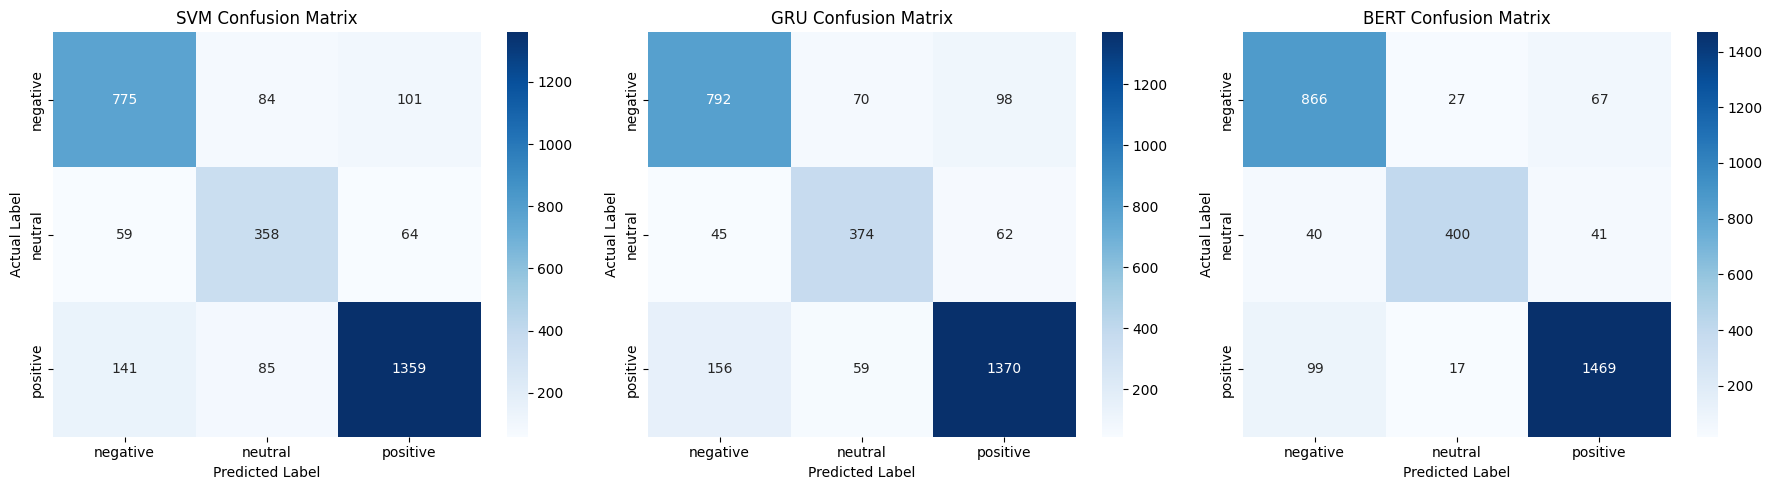


✅ Phase 9 held-out test evaluation saved to Google Drive.
   Metrics     : /content/drive/MyDrive/SMC_Assignment/phase_09_model_evaluation/held_out_test/phase9_model_evaluation.csv
   Predictions : /content/drive/MyDrive/SMC_Assignment/phase_09_model_evaluation/held_out_test/phase9_test_predictions.csv
   Figure      : /content/drive/MyDrive/SMC_Assignment/phase_09_model_evaluation/held_out_test/phase9_confusion_matrices.png


In [ ]:
# ─────────────────────────────────────────────
# HELD-OUT TEST-SET EVALUATION
# ─────────────────────────────────────────────

import os
import time
import numpy as np
import pandas as pd
import torch

BERT_EVAL_BATCH_SIZE = 32

# A. SVM predictions
svm_inference_start = time.time()
eval_x_test_tfidf = eval_tfidf_vec.transform(
    eval_test_df['processed_text']
)
eval_svm_preds = eval_svm_model.predict(eval_x_test_tfidf)
svm_inference_seconds = time.time() - svm_inference_start

# B. GRU predictions
gru_inference_start = time.time()
eval_x_test_seq = eval_gru_tokenizer.texts_to_sequences(
    eval_test_df['tokens']
)
eval_x_test_pad = tf.keras.preprocessing.sequence.pad_sequences(
    eval_x_test_seq,
    maxlen=EVAL_GRU_MAX_LENGTH,
    padding='post',
    truncating='post'
)

with tf.device('/CPU:0'):
    eval_gru_probs = eval_gru_model.predict(
        eval_x_test_pad,
        batch_size=32,
        verbose=0
    )

eval_gru_preds = np.argmax(eval_gru_probs, axis=1)
gru_inference_seconds = time.time() - gru_inference_start


def get_bert_predictions(text_series, batch_size=BERT_EVAL_BATCH_SIZE):
    """Generate BERT predictions in batches to control memory usage."""
    predictions = []
    texts = text_series.fillna('').astype(str).tolist()

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]

        encoded = eval_bert_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=64,
            return_tensors='pt'
        )
        encoded = {
            key: value.to(bert_device)
            for key, value in encoded.items()
        }

        with torch.no_grad():
            outputs = eval_bert_model(**encoded)

        batch_predictions = torch.argmax(
            outputs.logits,
            dim=1
        ).cpu().numpy()

        predictions.extend(batch_predictions.tolist())

    return np.asarray(predictions)


# C. BERT predictions
bert_inference_start = time.time()
eval_bert_preds = get_bert_predictions(
    eval_test_df['review_text']
)
bert_inference_seconds = time.time() - bert_inference_start

model_predictions = {
    'SVM': eval_svm_preds,
    'GRU': eval_gru_preds,
    'BERT': eval_bert_preds
}

inference_times = {
    'SVM': svm_inference_seconds,
    'GRU': gru_inference_seconds,
    'BERT': bert_inference_seconds
}

# Calculate and display metrics
evaluation_rows = []

for model_name, predictions in model_predictions.items():
    model_metrics = calculate_classification_metrics(
        eval_y_test,
        predictions
    )

    evaluation_rows.append({
        'Model': model_name,
        **model_metrics,
        'Inference Time (Seconds)': inference_times[model_name]
    })

    print("\n" + "=" * 72)
    print(f"{model_name} — HELD-OUT TEST CLASSIFICATION REPORT")
    print("=" * 72)
    print(
        classification_report(
            eval_y_test,
            predictions,
            labels=np.arange(len(class_names)),
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

evaluation_table = pd.DataFrame(evaluation_rows).sort_values(
    by='Macro F1',
    ascending=False
).reset_index(drop=True)

print("\n📊 FINAL HELD-OUT TEST COMPARISON")
display(
    evaluation_table.style.format({
        'Accuracy': '{:.4f}',
        'Macro Precision': '{:.4f}',
        'Macro Recall': '{:.4f}',
        'Macro F1': '{:.4f}',
        'Weighted F1': '{:.4f}',
        'Inference Time (Seconds)': '{:.2f}'
    })
)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, (model_name, predictions) in zip(
    axes,
    model_predictions.items()
):
    matrix = confusion_matrix(
        eval_y_test,
        predictions,
        labels=np.arange(len(class_names))
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axis,
        xticklabels=class_names,
        yticklabels=class_names
    )

    axis.set_title(f'{model_name} Confusion Matrix')
    axis.set_xlabel('Predicted Label')
    axis.set_ylabel('Actual Label')

plt.tight_layout()

CONFUSION_MATRIX_FILE = os.path.join(PHASE_09_HELDOUT_DIR, 'phase9_confusion_matrices.png')
plt.savefig(
    CONFUSION_MATRIX_FILE,
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Save evaluation results and row-level predictions
EVALUATION_TABLE_FILE = os.path.join(PHASE_09_HELDOUT_DIR, 'phase9_model_evaluation.csv')
PREDICTIONS_FILE = os.path.join(PHASE_09_HELDOUT_DIR, 'phase9_test_predictions.csv')

evaluation_table.to_csv(EVALUATION_TABLE_FILE, index=False)

prediction_output = eval_test_df[
    ['review_text', 'sentiment_label']
].copy()

for model_name, predictions in model_predictions.items():
    prediction_output[f'{model_name.lower()}_prediction'] = (
        eval_label_encoder.inverse_transform(predictions)
    )

prediction_output.to_csv(PREDICTIONS_FILE, index=True)

print("\n✅ Phase 9 held-out test evaluation saved to Google Drive.")
print(f"   Metrics     : {EVALUATION_TABLE_FILE}")
print(f"   Predictions : {PREDICTIONS_FILE}")
print(f"   Figure      : {CONFUSION_MATRIX_FILE}")

## 9.2 Stratified Five-Fold Cross-Validation

Each fold rebuilds its preprocessing and model from scratch. Fold models are temporary, while metrics and summaries are saved permanently.

### 9.2.1 Cross-Validation Configuration

In [ ]:
# ─────────────────────────────────────────────
# CROSS-VALIDATION CONFIGURATION
# ─────────────────────────────────────────────

import os
import gc
import time
import shutil
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import torch

from sklearn.model_selection import StratifiedKFold

CV_FOLDS = 5

# Keep these equal to the Phase 7 training settings for a fair comparison.
GRU_CV_EPOCHS = 15
GRU_CV_BATCH_SIZE = 32

BERT_CV_EPOCHS = 2
BERT_CV_BATCH_SIZE = 16
BERT_CV_MAX_LENGTH = 64

CV_OUTPUT_DIR = PHASE_09_CV_DIR
os.makedirs(CV_OUTPUT_DIR, exist_ok=True)

# Cross-validation uses only the original training split.
# The fixed validation and test sets are kept separate.
cv_df = eval_train_df.reset_index(drop=True).copy()

cv_df['processed_text'] = cv_df['processed_text'].fillna('')
cv_df['tokens'] = cv_df['tokens'].fillna('')
cv_df['review_text'] = cv_df['review_text'].fillna('')

cv_labels = eval_label_encoder.transform(cv_df['sentiment_label'])

cv_splitter = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("✅ Cross-validation configuration ready.")
print(f"   Folds            : {CV_FOLDS}")
print(f"   CV training rows : {len(cv_df):,}")
print(f"   Output folder    : {CV_OUTPUT_DIR}")
print(f"   GRU epochs/fold  : {GRU_CV_EPOCHS}")
print(f"   BERT epochs/fold : {BERT_CV_EPOCHS}")

✅ Cross-validation configuration ready.
   Folds            : 5
   CV training rows : 14,120
   Output folder    : /content/drive/MyDrive/SMC_Assignment/phase_09_model_evaluation/cross_validation
   GRU epochs/fold  : 15
   BERT epochs/fold : 2


### 9.2.2 SVM Five-Fold Cross-Validation

In [ ]:
# ─────────────────────────────────────────────
# 8.2.2 GENUINE STRATIFIED 5-FOLD CV — SVM
# ─────────────────────────────────────────────

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

print("⏳ Running stratified 5-fold cross-validation for SVM...")

svm_cv_rows = []

for fold_number, (fold_train_idx, fold_val_idx) in enumerate(
    cv_splitter.split(cv_df['processed_text'], cv_labels),
    start=1
):
    print(f"\n{'=' * 68}")
    print(f"SVM FOLD {fold_number}/{CV_FOLDS}")
    print(f"{'=' * 68}")

    fold_train_text = cv_df.iloc[fold_train_idx]['processed_text']
    fold_val_text = cv_df.iloc[fold_val_idx]['processed_text']

    fold_y_train = cv_labels[fold_train_idx]
    fold_y_val = cv_labels[fold_val_idx]

    # TF-IDF is fitted only on the fold's training portion.
    fold_svm_pipeline = Pipeline([
        (
            'tfidf',
            TfidfVectorizer(max_features=5000)
        ),
        (
            'svm',
            LinearSVC(
                max_iter=5000,
                class_weight='balanced',
                random_state=RANDOM_STATE + fold_number
            )
        )
    ])

    fit_start = time.time()
    fold_svm_pipeline.fit(fold_train_text, fold_y_train)
    fit_seconds = time.time() - fit_start

    predict_start = time.time()
    fold_predictions = fold_svm_pipeline.predict(fold_val_text)
    inference_seconds = time.time() - predict_start

    fold_metrics = calculate_classification_metrics(
        fold_y_val,
        fold_predictions
    )

    svm_cv_rows.append({
        'Model': 'SVM',
        'Fold': fold_number,
        **fold_metrics,
        'Training Time (Seconds)': fit_seconds,
        'Inference Time (Seconds)': inference_seconds,
        'Epochs Trained': np.nan
    })

    print(
        f"Accuracy={fold_metrics['Accuracy']:.4f} | "
        f"Macro F1={fold_metrics['Macro F1']:.4f} | "
        f"Training={fit_seconds:.2f}s"
    )

svm_cv_results = pd.DataFrame(svm_cv_rows)

SVM_CV_RESULTS_FILE = os.path.join(
    CV_OUTPUT_DIR,
    'phase9_svm_5fold_results.csv'
)
svm_cv_results.to_csv(SVM_CV_RESULTS_FILE, index=False)

print("\n✅ SVM 5-fold cross-validation completed.")
display(
    svm_cv_results.style.format({
        'Accuracy': '{:.4f}',
        'Macro Precision': '{:.4f}',
        'Macro Recall': '{:.4f}',
        'Macro F1': '{:.4f}',
        'Weighted F1': '{:.4f}',
        'Training Time (Seconds)': '{:.2f}',
        'Inference Time (Seconds)': '{:.2f}'
    })
)
print(f"💾 Saved: {SVM_CV_RESULTS_FILE}")

⏳ Running stratified 5-fold cross-validation for SVM...

SVM FOLD 1/5
Accuracy=0.8166 | Macro F1=0.7934 | Training=0.38s

SVM FOLD 2/5
Accuracy=0.8293 | Macro F1=0.8025 | Training=0.37s

SVM FOLD 3/5
Accuracy=0.8251 | Macro F1=0.7958 | Training=0.73s

SVM FOLD 4/5
Accuracy=0.8258 | Macro F1=0.8013 | Training=0.57s

SVM FOLD 5/5
Accuracy=0.8332 | Macro F1=0.8096 | Training=0.54s

✅ SVM 5-fold cross-validation completed.


,Model,Fold,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (Seconds),Inference Time (Seconds),Epochs Trained
0,SVM,1,0.8166,0.7845,0.8047,0.7934,0.8183,0.38,0.05,nan
1,SVM,2,0.8293,0.7944,0.8124,0.8025,0.8312,0.37,0.07,nan
2,SVM,3,0.8251,0.7895,0.8033,0.7958,0.8266,0.73,0.07,nan
3,SVM,4,0.8258,0.7922,0.8133,0.8013,0.8276,0.57,0.06,nan
4,SVM,5,0.8332,0.8016,0.8201,0.8096,0.8345,0.54,0.07,nan


💾 Saved: /content/drive/MyDrive/SMC_Assignment/phase_09_model_evaluation/cross_validation/phase9_svm_5fold_results.csv


### 9.2.3 GRU Five-Fold Cross-Validation

In [ ]:
# ─────────────────────────────────────────────
# 8.2.3 GENUINE STRATIFIED 5-FOLD CV — IMPROVED GRU
# ─────────────────────────────────────────────

import os
import gc
import random
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    GRU,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

print("⏳ Running stratified 5-fold cross-validation for GRU...")
print("ℹ️ cuDNN is disabled to safely support masked sequences.")

gru_cv_rows = []

for fold_number, (fold_train_idx, fold_val_idx) in enumerate(
    cv_splitter.split(
        cv_df["tokens"],
        cv_labels
    ),
    start=1
):
    print(f"\n{'=' * 68}")
    print(f"GRU FOLD {fold_number}/{CV_FOLDS}")
    print(f"{'=' * 68}")

    # Clear the previous fold model
    tf.keras.backend.clear_session()
    gc.collect()

    # Reproducibility for each fold
    fold_seed = RANDOM_STATE + fold_number

    random.seed(fold_seed)
    np.random.seed(fold_seed)
    tf.random.set_seed(fold_seed)

    # --------------------------------------------------------
    # Prepare fold data
    # --------------------------------------------------------

    fold_train_text = prepare_token_text(
        cv_df.iloc[fold_train_idx]["tokens"]
    )

    fold_val_text = prepare_token_text(
        cv_df.iloc[fold_val_idx]["tokens"]
    )

    fold_y_train = np.asarray(
        cv_labels[fold_train_idx],
        dtype=np.int32
    )

    fold_y_val = np.asarray(
        cv_labels[fold_val_idx],
        dtype=np.int32
    )

    # --------------------------------------------------------
    # Fit tokenizer on fold training data only
    # --------------------------------------------------------

    fold_tokenizer = Tokenizer(
        num_words=MAX_VOCAB_SIZE,
        oov_token="<OOV>"
    )

    fold_tokenizer.fit_on_texts(
        fold_train_text
    )

    fold_vocab_size = min(
        MAX_VOCAB_SIZE,
        len(fold_tokenizer.word_index) + 1
    )

    fold_train_sequences = (
        fold_tokenizer.texts_to_sequences(
            fold_train_text
        )
    )

    fold_val_sequences = (
        fold_tokenizer.texts_to_sequences(
            fold_val_text
        )
    )

    # Replace empty sequences with the OOV token.
    # This prevents completely masked rows.
    fold_oov_index = fold_tokenizer.word_index.get(
        "<OOV>",
        1
    )

    fold_train_sequences = [
        sequence if len(sequence) > 0
        else [fold_oov_index]
        for sequence in fold_train_sequences
    ]

    fold_val_sequences = [
        sequence if len(sequence) > 0
        else [fold_oov_index]
        for sequence in fold_val_sequences
    ]

    # Strict right-padding
    fold_x_train = pad_sequences(
        fold_train_sequences,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post",
        value=0,
        dtype="int32"
    )

    fold_x_val = pad_sequences(
        fold_val_sequences,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post",
        value=0,
        dtype="int32"
    )

    # --------------------------------------------------------
    # Validate padded sequences
    # --------------------------------------------------------

    def count_invalid_right_padded_rows(sequences):
        """
        Count sequences containing a non-zero token after padding starts.
        """
        invalid_count = 0

        for sequence in sequences:
            zero_positions = np.where(
                sequence == 0
            )[0]

            if len(zero_positions) == 0:
                continue

            first_zero_position = zero_positions[0]

            if np.any(
                sequence[first_zero_position:] != 0
            ):
                invalid_count += 1

        return invalid_count

    invalid_train_rows = count_invalid_right_padded_rows(
        fold_x_train
    )

    invalid_val_rows = count_invalid_right_padded_rows(
        fold_x_val
    )

    if invalid_train_rows > 0 or invalid_val_rows > 0:
        raise ValueError(
            f"Fold {fold_number} contains invalid padding. "
            f"Train invalid rows: {invalid_train_rows}, "
            f"Validation invalid rows: {invalid_val_rows}"
        )

    print(
        f"   Train rows: {len(fold_x_train):,} | "
        f"Validation rows: {len(fold_x_val):,}"
    )

    print(
        f"   Vocabulary size: {fold_vocab_size:,} | "
        f"Sequence length: {MAX_SEQUENCE_LENGTH}"
    )

    # --------------------------------------------------------
    # Calculate softened class weights
    # --------------------------------------------------------

    fold_classes = np.unique(
        fold_y_train
    )

    fold_raw_weights = compute_class_weight(
        class_weight="balanced",
        classes=fold_classes,
        y=fold_y_train
    )

    fold_softened_weights = np.sqrt(
        fold_raw_weights
    )

    fold_softened_weights = (
        fold_softened_weights
        / fold_softened_weights.mean()
    )

    fold_class_weights = {
        int(class_id): float(weight)
        for class_id, weight in zip(
            fold_classes,
            fold_softened_weights
        )
    }

    print("   Class weights:", fold_class_weights)

    # --------------------------------------------------------
    # Build a new GRU model for this fold
    # --------------------------------------------------------

    with tf.device("/CPU:0"):

        fold_gru_model = Sequential([
            Input(
                shape=(MAX_SEQUENCE_LENGTH,),
                dtype="int32"
            ),

            Embedding(
                input_dim=fold_vocab_size,
                output_dim=128,
                mask_zero=True,
                name=f"embedding_fold_{fold_number}"
            ),

            SpatialDropout1D(
                rate=0.20,
                name=f"spatial_dropout_fold_{fold_number}"
            ),

            GRU(
                units=64,
                return_sequences=False,

                # Important fix:
                # prevents the cuDNN masking assertion error
                use_cudnn=False,

                name=f"gru_fold_{fold_number}"
            ),

            Dropout(
                rate=0.30,
                name=f"dropout_fold_{fold_number}"
            ),

            Dense(
                units=len(class_names),
                activation="softmax",
                name=f"output_fold_{fold_number}"
            )
        ])

        fold_gru_model.compile(
            optimizer=Adam(
                learning_rate=5e-4,
                clipnorm=1.0
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        # ----------------------------------------------------
        # Callbacks
        # ----------------------------------------------------

        fold_early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1
        )

        fold_reduce_learning_rate = ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-5,
            verbose=1
        )

        # ----------------------------------------------------
        # Train fold model
        # ----------------------------------------------------

        fit_start = time.time()

        fold_history = fold_gru_model.fit(
            fold_x_train,
            fold_y_train,
            epochs=GRU_CV_EPOCHS,
            batch_size=GRU_CV_BATCH_SIZE,
            validation_data=(
                fold_x_val,
                fold_y_val
            ),
            class_weight=fold_class_weights,
            callbacks=[
                fold_early_stopping,
                fold_reduce_learning_rate
            ],
            verbose=1
        )

        fit_seconds = (
            time.time() - fit_start
        )

        # ----------------------------------------------------
        # Predict fold validation data
        # ----------------------------------------------------

        predict_start = time.time()

        fold_probabilities = (
            fold_gru_model.predict(
                fold_x_val,
                batch_size=GRU_CV_BATCH_SIZE,
                verbose=0
            )
        )

        inference_seconds = (
            time.time() - predict_start
        )

    fold_predictions = np.argmax(
        fold_probabilities,
        axis=1
    )

    # --------------------------------------------------------
    # Calculate fold metrics
    # --------------------------------------------------------

    fold_metrics = calculate_classification_metrics(
        fold_y_val,
        fold_predictions
    )

    epochs_trained = len(
        fold_history.history.get(
            "loss",
            []
        )
    )

    actual_fold_counts = np.bincount(
        fold_y_val,
        minlength=len(class_names)
    )

    predicted_fold_counts = np.bincount(
        fold_predictions,
        minlength=len(class_names)
    )

    gru_cv_rows.append({
        "Model": "GRU",
        "Fold": fold_number,
        **fold_metrics,
        "Training Time (Seconds)": fit_seconds,
        "Inference Time (Seconds)": inference_seconds,
        "Epochs Trained": epochs_trained
    })

    print(
        f"\n✅ Fold {fold_number} completed | "
        f"Accuracy={fold_metrics['Accuracy']:.4f} | "
        f"Macro F1={fold_metrics['Macro F1']:.4f} | "
        f"Epochs={epochs_trained} | "
        f"Training={fit_seconds:.2f}s"
    )

    print(
        "   Actual counts   :",
        actual_fold_counts.tolist()
    )

    print(
        "   Predicted counts:",
        predicted_fold_counts.tolist()
    )

    # --------------------------------------------------------
    # Clear fold resources
    # --------------------------------------------------------

    del fold_gru_model
    del fold_tokenizer
    del fold_history
    del fold_x_train
    del fold_x_val
    del fold_probabilities
    del fold_predictions

    tf.keras.backend.clear_session()
    gc.collect()

# ============================================================
# SAVE COMPLETE GRU CROSS-VALIDATION RESULTS
# ============================================================

gru_cv_results = pd.DataFrame(
    gru_cv_rows
)

GRU_CV_RESULTS_FILE = os.path.join(
    CV_OUTPUT_DIR,
    "phase9_gru_5fold_results.csv"
)

gru_cv_results.to_csv(
    GRU_CV_RESULTS_FILE,
    index=False
)

print(
    "\n✅ Improved GRU 5-fold "
    "cross-validation completed."
)

display(
    gru_cv_results.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Training Time (Seconds)": "{:.2f}",
        "Inference Time (Seconds)": "{:.2f}",
        "Epochs Trained": "{:.0f}"
    })
)

print(f"💾 Saved: {GRU_CV_RESULTS_FILE}")

⏳ Running stratified 5-fold cross-validation for GRU...
ℹ️ cuDNN is disabled to safely support masked sequences.

GRU FOLD 1/5
   Train rows: 11,296 | Validation rows: 2,824
   Vocabulary size: 6,225 | Sequence length: 37
   Class weights: {0: 0.9405621837534416, 1: 1.3275639803963246, 2: 0.7318738358502335}
Epoch 1/15
353/353 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.7062 - loss: 0.6911 - val_accuracy: 0.8116 - val_loss: 0.5434 - learning_rate: 5.0000e-04
Epoch 2/15
353/353 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8593 - loss: 0.4115 - val_accuracy: 0.8314 - val_loss: 0.5011 - learning_rate: 5.0000e-04
Epoch 3/15
351/353 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8922 - loss: 0.3139
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
353/353 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8980 - loss: 0.3074 - val_accuracy: 0.8300 - val_loss: 0.5224 - learning_rate: 5.0000e-04
Epoch 4/15
351/353 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0

,Model,Fold,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (Seconds),Inference Time (Seconds),Epochs Trained
0,GRU,1,0.8314,0.8074,0.8124,0.8098,0.8318,46.34,1.33,5
1,GRU,2,0.8275,0.7994,0.8058,0.8025,0.8281,52.56,1.28,5
2,GRU,3,0.8286,0.7898,0.8086,0.7980,0.8307,44.47,1.31,5
3,GRU,4,0.8346,0.8034,0.8148,0.8072,0.8352,43.87,1.88,5
4,GRU,5,0.8233,0.7861,0.8148,0.7951,0.8263,50.38,2.60,5


💾 Saved: /content/drive/MyDrive/SMC_Assignment/phase_09_model_evaluation/cross_validation/phase9_gru_5fold_results.csv


### 9.2.4 BERT Five-Fold Cross-Validation

In [ ]:
# ─────────────────────────────────────────────
# 8.2.4 GENUINE STRATIFIED 5-FOLD CV — BERT
# ─────────────────────────────────────────────

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

print("⏳ Running stratified 5-fold cross-validation for BERT...")
print("⚠️ This is the most computationally expensive Phase 9 cell.")

# Free the final evaluation model from GPU before starting fold training.
if 'eval_bert_model' in globals():
    del eval_bert_model
if 'eval_bert_tokenizer' in globals():
    del eval_bert_tokenizer

tf.keras.backend.clear_session()
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

bert_cv_device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"   BERT CV device: {bert_cv_device}")

cv_bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)


class BertCrossValidationDataset(torch.utils.data.Dataset):
    """PyTorch dataset used only for BERT cross-validation."""

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = np.asarray(labels)

    def __getitem__(self, index):
        item = {
            key: torch.tensor(values[index], dtype=torch.long)
            for key, values in self.encodings.items()
        }
        item['labels'] = torch.tensor(
            self.labels[index],
            dtype=torch.long
        )
        return item

    def __len__(self):
        return len(self.labels)


def tokenize_bert_cv_text(text_series):
    """Tokenize one fold without using validation or test labels."""
    return cv_bert_tokenizer(
        text_series.fillna('').astype(str).tolist(),
        padding='max_length',
        truncation=True,
        max_length=BERT_CV_MAX_LENGTH,
        return_tensors='np'
    )


bert_cv_rows = []
bert_cv_temp_root = '/content/bert_cv_temp'
os.makedirs(bert_cv_temp_root, exist_ok=True)

for fold_number, (fold_train_idx, fold_val_idx) in enumerate(
    cv_splitter.split(cv_df['review_text'], cv_labels),
    start=1
):
    print(f"\n{'=' * 68}")
    print(f"BERT FOLD {fold_number}/{CV_FOLDS}")
    print(f"{'=' * 68}")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    fold_seed = RANDOM_STATE + fold_number
    torch.manual_seed(fold_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(fold_seed)

    fold_train_text = cv_df.iloc[fold_train_idx]['review_text']
    fold_val_text = cv_df.iloc[fold_val_idx]['review_text']

    fold_y_train = cv_labels[fold_train_idx]
    fold_y_val = cv_labels[fold_val_idx]

    fold_train_encodings = tokenize_bert_cv_text(
        fold_train_text
    )
    fold_val_encodings = tokenize_bert_cv_text(
        fold_val_text
    )

    fold_train_dataset = BertCrossValidationDataset(
        fold_train_encodings,
        fold_y_train
    )
    fold_val_dataset = BertCrossValidationDataset(
        fold_val_encodings,
        fold_y_val
    )

    # A completely fresh BERT model is created for every fold.
    fold_bert_model = (
        AutoModelForSequenceClassification.from_pretrained(
            BERT_MODEL_NAME,
            num_labels=len(class_names),
            id2label={
                index: label
                for index, label in enumerate(class_names)
            },
            label2id={
                label: index
                for index, label in enumerate(class_names)
            }
        )
    )

    fold_output_dir = os.path.join(
        bert_cv_temp_root,
        f'fold_{fold_number}'
    )

    fold_training_args = TrainingArguments(
        output_dir=fold_output_dir,
        num_train_epochs=BERT_CV_EPOCHS,
        per_device_train_batch_size=BERT_CV_BATCH_SIZE,
        per_device_eval_batch_size=BERT_CV_BATCH_SIZE,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy='no',
        save_strategy='no',
        logging_strategy='epoch',
        report_to='none',
        seed=fold_seed,
        data_seed=fold_seed,
        fp16=torch.cuda.is_available()
    )

    fold_trainer = Trainer(
        model=fold_bert_model,
        args=fold_training_args,
        train_dataset=fold_train_dataset
    )

    fit_start = time.time()
    fold_trainer.train()
    fit_seconds = time.time() - fit_start

    predict_start = time.time()
    fold_prediction_output = fold_trainer.predict(
        fold_val_dataset
    )
    inference_seconds = time.time() - predict_start

    fold_logits = fold_prediction_output.predictions
    if isinstance(fold_logits, tuple):
        fold_logits = fold_logits[0]

    fold_predictions = np.argmax(
        fold_logits,
        axis=1
    )

    fold_metrics = calculate_classification_metrics(
        fold_y_val,
        fold_predictions
    )

    bert_cv_rows.append({
        'Model': 'BERT',
        'Fold': fold_number,
        **fold_metrics,
        'Training Time (Seconds)': fit_seconds,
        'Inference Time (Seconds)': inference_seconds,
        'Epochs Trained': BERT_CV_EPOCHS
    })

    print(
        f"Accuracy={fold_metrics['Accuracy']:.4f} | "
        f"Macro F1={fold_metrics['Macro F1']:.4f} | "
        f"Training={fit_seconds:.2f}s"
    )

    # Fold models are temporary. Final Phase 7 BERT remains saved in Drive.
    del fold_trainer
    del fold_bert_model
    del fold_train_dataset
    del fold_val_dataset
    del fold_train_encodings
    del fold_val_encodings
    del fold_prediction_output
    del fold_logits

    if os.path.exists(fold_output_dir):
        shutil.rmtree(
            fold_output_dir,
            ignore_errors=True
        )

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

bert_cv_results = pd.DataFrame(bert_cv_rows)

BERT_CV_RESULTS_FILE = os.path.join(
    CV_OUTPUT_DIR,
    'phase9_bert_5fold_results.csv'
)
bert_cv_results.to_csv(BERT_CV_RESULTS_FILE, index=False)

print("\n✅ BERT 5-fold cross-validation completed.")
display(
    bert_cv_results.style.format({
        'Accuracy': '{:.4f}',
        'Macro Precision': '{:.4f}',
        'Macro Recall': '{:.4f}',
        'Macro F1': '{:.4f}',
        'Weighted F1': '{:.4f}',
        'Training Time (Seconds)': '{:.2f}',
        'Inference Time (Seconds)': '{:.2f}',
        'Epochs Trained': '{:.0f}'
    })
)
print(f"💾 Saved: {BERT_CV_RESULTS_FILE}")

⏳ Running stratified 5-fold cross-validation for BERT...
⚠️ This is the most computationally expensive Phase 9 cell.
   BERT CV device: cuda

BERT FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Step,Training Loss
706,0.515304
1412,0.261310


Accuracy=0.8824 | Macro F1=0.8701 | Training=105.86s

BERT FOLD 2/5


...

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Step,Training Loss
706,0.531019
1412,0.266721


Accuracy=0.8959 | Macro F1=0.8845 | Training=106.00s

✅ BERT 5-fold cross-validation completed.


,Model,Fold,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (Seconds),Inference Time (Seconds),Epochs Trained
0,BERT,1,0.8824,0.8773,0.8649,0.8701,0.8825,105.86,3.00,2
1,BERT,2,0.9026,0.8951,0.8785,0.8863,0.9020,105.35,2.99,2
2,BERT,3,0.8909,0.8815,0.8694,0.8738,0.8908,105.96,3.03,2
3,BERT,4,0.8892,0.8793,0.8697,0.8740,0.8890,106.43,3.53,2
4,BERT,5,0.8959,0.8871,0.8832,0.8845,0.8961,106.00,3.49,2


💾 Saved: /content/drive/MyDrive/SMC_Assignment/phase_09_model_evaluation/cross_validation/phase9_bert_5fold_results.csv


### 9.2.5 Combine and Compare Cross-Validation Results

✅ SVM results loaded: 5 folds from memory
✅ GRU results loaded: 5 folds from memory
✅ BERT results loaded: 5 folds from memory

📊 ALL-MODEL 5-FOLD CROSS-VALIDATION — FOLD RESULTS


,Model,Fold,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (Seconds),Inference Time (Seconds),Epochs Trained
0,SVM,1,0.8166,0.7845,0.8047,0.7934,0.8183,0.3788,0.0543,NaN
1,SVM,2,0.8293,0.7944,0.8124,0.8025,0.8312,0.3726,0.0713,NaN
2,SVM,3,0.8251,0.7895,0.8033,0.7958,0.8266,0.7251,0.0749,NaN
3,SVM,4,0.8258,0.7922,0.8133,0.8013,0.8276,0.5746,0.0552,NaN
4,SVM,5,0.8332,0.8016,0.8201,0.8096,0.8345,0.5438,0.0682,NaN
5,GRU,1,0.8314,0.8074,0.8124,0.8098,0.8318,46.3380,1.3269,5.0
6,GRU,2,0.8275,0.7994,0.8058,0.8025,0.8281,52.5639,1.2814,5.0
7,GRU,3,0.8286,0.7898,0.8086,0.7980,0.8307,44.4659,1.3078,5.0
8,GRU,4,0.8346,0.8034,0.8148,0.8072,0.8352,43.8691,1.8784,5.0
9,GRU,5,0.8233,0.7861,0.8148,0.7951,0.8263,50.3807,2.6011,5.0



📊 ALL-MODEL 5-FOLD CROSS-VALIDATION — SUMMARY


,Model,Accuracy Mean,Accuracy Std,Macro Precision Mean,Macro Precision Std,Macro Recall Mean,Macro Recall Std,Macro F1 Mean,Macro F1 Std,Weighted F1 Mean,Weighted F1 Std,Training Time (Seconds) Mean,Training Time (Seconds) Std,Inference Time (Seconds) Mean,Inference Time (Seconds) Std
0,BERT,0.8922,0.0076,0.8840,0.0072,0.8731,0.0075,0.8777,0.0072,0.8921,0.0074,105.9220,0.3869,3.2065,0.2792
1,GRU,0.8291,0.0043,0.7972,0.0090,0.8113,0.0040,0.8025,0.0061,0.8304,0.0034,47.5235,3.7973,1.6791,0.5722
2,SVM,0.8260,0.0062,0.7924,0.0063,0.8108,0.0069,0.8005,0.0063,0.8276,0.0061,0.5190,0.1477,0.0648,0.0094


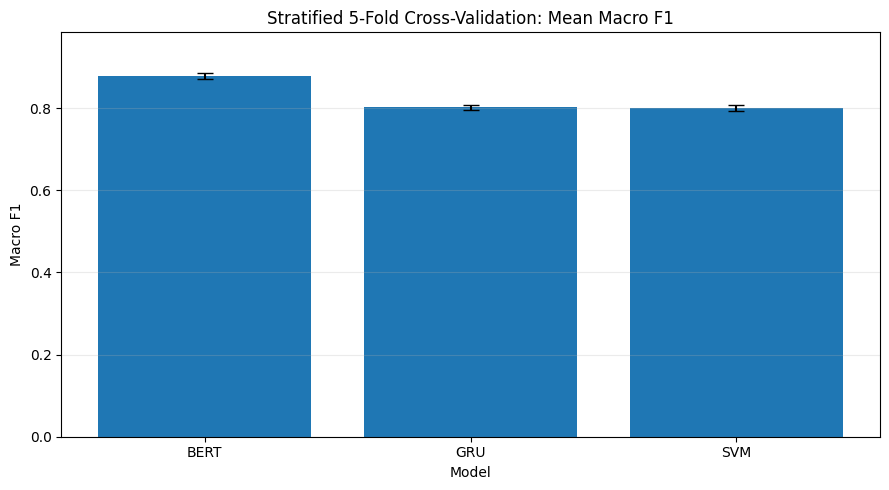


✅ All five-fold cross-validation outputs saved.
   Fold results : /content/drive/MyDrive/SMC_Assignment/phase_09_model_evaluation/cross_validation/phase9_all_models_5fold_results.csv
   Summary      : /content/drive/MyDrive/SMC_Assignment/phase_09_model_evaluation/cross_validation/phase9_all_models_5fold_summary.csv
   Figure       : /content/drive/MyDrive/SMC_Assignment/phase_09_model_evaluation/cross_validation/phase9_all_models_5fold_macro_f1.png


In [ ]:
# ─────────────────────────────────────────────
# 8.2.5 COMBINE AND COMPARE ALL 5-FOLD RESULTS
# ─────────────────────────────────────────────
# This cell can run even after a Colab runtime reset. It uses the
# in-memory DataFrames when available; otherwise, it reloads the saved
# fold-result CSV files from the Phase 9 cross-validation folder.

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs(PHASE_09_CV_DIR, exist_ok=True)

SVM_CV_RESULTS_FILE = os.path.join(
    PHASE_09_CV_DIR,
    'phase9_svm_5fold_results.csv'
)

GRU_CV_RESULTS_FILE = os.path.join(
    PHASE_09_CV_DIR,
    'phase9_gru_5fold_results.csv'
)

BERT_CV_RESULTS_FILE = os.path.join(
    PHASE_09_CV_DIR,
    'phase9_bert_5fold_results.csv'
)


def load_cv_results(variable_name, file_path, expected_model):
    """Use an existing DataFrame or reload the saved fold results."""
    current_value = globals().get(variable_name)

    if isinstance(current_value, pd.DataFrame) and not current_value.empty:
        loaded_df = current_value.copy()
        source_used = 'memory'
    elif os.path.exists(file_path):
        loaded_df = pd.read_csv(file_path)
        source_used = file_path
    else:
        raise FileNotFoundError(
            f"Missing {expected_model} cross-validation results.\n"
            f"Expected file: {file_path}\n"
            f"Run the {expected_model} five-fold cross-validation cell first."
        )

    required_columns = {
        'Model',
        'Fold',
        'Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1',
        'Weighted F1',
        'Training Time (Seconds)',
        'Inference Time (Seconds)'
    }

    missing_columns = required_columns.difference(loaded_df.columns)

    if missing_columns:
        raise ValueError(
            f"{expected_model} CV results are missing columns: "
            f"{sorted(missing_columns)}"
        )

    print(
        f"✅ {expected_model} results loaded: "
        f"{len(loaded_df)} folds from {source_used}"
    )

    return loaded_df


svm_cv_results = load_cv_results(
    'svm_cv_results',
    SVM_CV_RESULTS_FILE,
    'SVM'
)

gru_cv_results = load_cv_results(
    'gru_cv_results',
    GRU_CV_RESULTS_FILE,
    'GRU'
)

bert_cv_results = load_cv_results(
    'bert_cv_results',
    BERT_CV_RESULTS_FILE,
    'BERT'
)

all_models_cv_results = pd.concat(
    [
        svm_cv_results,
        gru_cv_results,
        bert_cv_results
    ],
    ignore_index=True
)

# Ensure numeric columns are numeric when they were reloaded from CSV.
metric_columns = [
    'Accuracy',
    'Macro Precision',
    'Macro Recall',
    'Macro F1',
    'Weighted F1',
    'Training Time (Seconds)',
    'Inference Time (Seconds)'
]

for metric_name in metric_columns:
    all_models_cv_results[metric_name] = pd.to_numeric(
        all_models_cv_results[metric_name],
        errors='coerce'
    )

summary_rows = []

for model_name, model_group in all_models_cv_results.groupby('Model'):
    summary_row = {'Model': model_name}

    for metric_name in metric_columns:
        summary_row[f'{metric_name} Mean'] = model_group[metric_name].mean()
        summary_row[f'{metric_name} Std'] = model_group[metric_name].std(ddof=1)

    summary_rows.append(summary_row)

all_models_cv_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(
        by='Macro F1 Mean',
        ascending=False
    )
    .reset_index(drop=True)
)

ALL_CV_RESULTS_FILE = os.path.join(
    PHASE_09_CV_DIR,
    'phase9_all_models_5fold_results.csv'
)

ALL_CV_SUMMARY_FILE = os.path.join(
    PHASE_09_CV_DIR,
    'phase9_all_models_5fold_summary.csv'
)

ALL_CV_FIGURE_FILE = os.path.join(
    PHASE_09_CV_DIR,
    'phase9_all_models_5fold_macro_f1.png'
)

all_models_cv_results.to_csv(
    ALL_CV_RESULTS_FILE,
    index=False
)

all_models_cv_summary.to_csv(
    ALL_CV_SUMMARY_FILE,
    index=False
)

print("\n📊 ALL-MODEL 5-FOLD CROSS-VALIDATION — FOLD RESULTS")

fold_display_columns = [
    'Model',
    'Fold',
    'Accuracy',
    'Macro Precision',
    'Macro Recall',
    'Macro F1',
    'Weighted F1',
    'Training Time (Seconds)',
    'Inference Time (Seconds)',
    'Epochs Trained'
]

available_fold_columns = [
    column
    for column in fold_display_columns
    if column in all_models_cv_results.columns
]

display(
    all_models_cv_results[
        available_fold_columns
    ].round(4)
)

print("\n📊 ALL-MODEL 5-FOLD CROSS-VALIDATION — SUMMARY")

display(
    all_models_cv_summary.round(4)
)

plt.figure(figsize=(9, 5))

plt.bar(
    all_models_cv_summary['Model'],
    all_models_cv_summary['Macro F1 Mean'],
    yerr=all_models_cv_summary['Macro F1 Std'],
    capsize=6
)

plt.title(
    'Stratified 5-Fold Cross-Validation: Mean Macro F1'
)
plt.xlabel('Model')
plt.ylabel('Macro F1')

upper_limit = (
    all_models_cv_summary['Macro F1 Mean']
    + all_models_cv_summary['Macro F1 Std'].fillna(0)
).max() + 0.10

plt.ylim(
    0,
    min(1.0, max(0.1, upper_limit))
)

plt.grid(
    axis='y',
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    ALL_CV_FIGURE_FILE,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print("\n✅ All five-fold cross-validation outputs saved.")
print(f"   Fold results : {ALL_CV_RESULTS_FILE}")
print(f"   Summary      : {ALL_CV_SUMMARY_FILE}")
print(f"   Figure       : {ALL_CV_FIGURE_FILE}")


---
# Phase 10: Opinion Mining

## 4.10 Opinion Mining

Dependency parsing traces opinion expressions to the specific targets discussed in each review. Explicit opinions directly describe a target, while implicit opinions communicate evaluation through an event or operational problem. The extraction is rule-based and its records should be interpreted as transparent opinion candidates rather than human-verified ground truth.

## 10.1 Install and Load Opinion-Mining Resources

In [ ]:
# ─────────────────────────────────────────────
# 9.1 INSTALL AND LOAD OPINION-MINING RESOURCES
# ─────────────────────────────────────────────

import os
import re
import sys
import subprocess
import numpy as np
import pandas as pd
import nltk

try:
    import spacy
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "spacy", "--quiet"],
        check=True
    )
    import spacy

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("📥 Downloading spaCy English model...")
    subprocess.run(
        [
            sys.executable,
            "-m",
            "spacy",
            "download",
            "en_core_web_sm"
        ],
        check=True
    )
    nlp = spacy.load("en_core_web_sm")

from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download("vader_lexicon", quiet=True)

# Recreate the analyser if the Phase 4 object is not available.
if "analyzer" not in globals():
    analyzer = SentimentIntensityAnalyzer()

    if "custom_lexicon" in globals():
        analyzer.lexicon.update(custom_lexicon)

OPINION_INPUT_FILE = os.path.join(PHASE_05_DIR, 'TikTok_Reviews_Phase5_Labeled.csv')

opinion_source_df = pd.read_csv(
    OPINION_INPUT_FILE,
    index_col="review_id"
)

opinion_source_df["review_text"] = (
    opinion_source_df["review_text"]
    .fillna("")
    .astype(str)
)

# Use all currently cleaned rows. Set an integer for a faster trial run.
OPINION_MINING_LIMIT = None

if OPINION_MINING_LIMIT is not None:
    opinion_work_df = opinion_source_df.head(
        OPINION_MINING_LIMIT
    ).copy()
else:
    opinion_work_df = opinion_source_df.copy()

print("✅ Opinion-mining resources loaded.")
print(f"   Reviews to analyse: {len(opinion_work_df):,}")
print(f"   spaCy pipeline     : {nlp.pipe_names}")

✅ Opinion-mining resources loaded.
   Reviews to analyse: 20,173
   spaCy pipeline     : ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## 10.2 Define Dependency-Based Extraction Rules

In [ ]:
# ─────────────────────────────────────────────
# 9.2 DEPENDENCY-BASED OPINION EXTRACTION RULES
# ─────────────────────────────────────────────

# Words that directly communicate an evaluation.
EXPLICIT_OPINION_WORDS = {
    "amazing", "awesome", "bad", "beautiful", "broken", "confusing",
    "disappointing", "easy", "excellent", "fantastic", "fast",
    "frustrating", "good", "great", "hard", "helpful", "horrible",
    "impossible", "poor", "reliable", "slow", "smooth", "terrible",
    "unfair", "unhelpful", "useful", "useless", "wonderful", "worst"
}

# Event patterns communicate an opinion even when no direct adjective is used.
IMPLICIT_OPINION_PATTERNS = [
    (
        re.compile(
            r"\b(crash|crashes|crashed|crashing|freeze|freezes|"
            r"froze|frozen|lag|lags|lagging)\b",
            flags=re.IGNORECASE
        ),
        "app performance",
        "negative"
    ),
    (
        re.compile(
            r"\b(won'?t open|cannot open|can'?t open|doesn'?t open|"
            r"not opening|stuck on loading)\b",
            flags=re.IGNORECASE
        ),
        "app accessibility",
        "negative"
    ),
    (
        re.compile(
            r"\b(ban|banned|suspend|suspended|shadowban|shadowbanned|"
            r"violation)\b",
            flags=re.IGNORECASE
        ),
        "account moderation",
        "negative"
    ),
    (
        re.compile(
            r"\b(ad|ads|advertisement|advertisements|sponsored)\b",
            flags=re.IGNORECASE
        ),
        "advertisements",
        "negative"
    ),
    (
        re.compile(
            r"\b(logs? me out|logged me out|signs? me out|"
            r"keeps? logging out)\b",
            flags=re.IGNORECASE
        ),
        "account access",
        "negative"
    ),
    (
        re.compile(
            r"\b(drains? (my )?battery|battery drain|uses? too much data|"
            r"data drain)\b",
            flags=re.IGNORECASE
        ),
        "resource usage",
        "negative"
    ),
    (
        re.compile(
            r"\b(keeps? deleting|deleted my|removed my|takes? down|"
            r"took down)\b",
            flags=re.IGNORECASE
        ),
        "content moderation",
        "negative"
    )
]


def label_compound_score(compound_score):
    """Convert a VADER compound score into the project's three labels."""
    if compound_score >= 0.05:
        return "positive"

    if compound_score <= -0.05:
        return "negative"

    return "neutral"


def build_opinion_expression(token):
    """Include local negation and adverb modifiers with an opinion word."""
    modifiers = [
        child.text
        for child in token.children
        if child.dep_ in {"neg", "advmod"}
    ]

    return " ".join(modifiers + [token.text]).strip()


def noun_chunk_for_token(token, sentence):
    """Return the noun phrase containing a target token when available."""
    for chunk in sentence.doc.noun_chunks:
        if (
            chunk.start >= sentence.start
            and chunk.end <= sentence.end
            and chunk.start <= token.i < chunk.end
        ):
            return chunk.text

    return token.text


def resolve_explicit_target(opinion_token, sentence):
    """
    Resolve the noun or noun phrase described by an opinion token.

    Rules cover:
    - adjectival modifiers: 'broken account'
    - complements: 'the account is broken'
    - sentiment verbs: 'I hate the update'
    """

    # Direct adjectival modifier: "broken account"
    if (
        opinion_token.dep_ == "amod"
        and opinion_token.head.pos_ in {"NOUN", "PROPN"}
    ):
        return noun_chunk_for_token(
            opinion_token.head,
            sentence
        )

    # Search grammatical children of the token and its head.
    candidates = []

    for possible_parent in {
        opinion_token,
        opinion_token.head
    }:
        for child in possible_parent.children:
            if (
                child.dep_ in {
                    "nsubj",
                    "nsubjpass",
                    "dobj",
                    "obj",
                    "pobj",
                    "attr"
                }
                and child.pos_ in {
                    "NOUN",
                    "PROPN",
                    "PRON"
                }
            ):
                candidates.append(child)

    if candidates:
        candidate = min(
            candidates,
            key=lambda token: abs(
                token.i - opinion_token.i
            )
        )

        if candidate.lower_ in {"it", "this", "that"}:
            return "TikTok app"

        return noun_chunk_for_token(
            candidate,
            sentence
        )

    # Fallback to the nearest noun in the same sentence.
    noun_candidates = [
        token
        for token in sentence
        if token.pos_ in {"NOUN", "PROPN"}
    ]

    if noun_candidates:
        candidate = min(
            noun_candidates,
            key=lambda token: abs(
                token.i - opinion_token.i
            )
        )

        return noun_chunk_for_token(
            candidate,
            sentence
        )

    return "TikTok app"


def extract_explicit_opinions(sentence):
    """Extract direct opinion word-to-target relationships."""
    extracted = []

    for token in sentence:
        lemma = token.lemma_.lower()

        vader_lexicon_score = analyzer.lexicon.get(
            token.lower_,
            analyzer.lexicon.get(lemma, 0.0)
        )

        is_opinion_word = (
            lemma in EXPLICIT_OPINION_WORDS
            or (
                token.pos_ in {"ADJ", "ADV"}
                and vader_lexicon_score != 0
            )
        )

        if not is_opinion_word:
            continue

        expression = build_opinion_expression(token)
        target = resolve_explicit_target(
            token,
            sentence
        )

        local_score = analyzer.polarity_scores(
            expression
        )["compound"]

        if local_score == 0:
            local_score = analyzer.polarity_scores(
                sentence.text
            )["compound"]

        extracted.append({
            "opinion_type": "explicit",
            "target": target,
            "opinion_expression": expression,
            "sentiment": label_compound_score(
                local_score
            ),
            "compound_score": round(
                local_score,
                4
            )
        })

    return extracted


def extract_implicit_opinions(sentence):
    """Extract operational events that imply a user evaluation."""
    extracted = []
    sentence_text = sentence.text

    for pattern, target, default_sentiment in IMPLICIT_OPINION_PATTERNS:
        for match in pattern.finditer(sentence_text):
            sentence_score = analyzer.polarity_scores(
                sentence_text
            )["compound"]

            sentiment = label_compound_score(
                sentence_score
            )

            # If VADER is neutral, use the transparent domain-rule default.
            if sentiment == "neutral":
                sentiment = default_sentiment

            extracted.append({
                "opinion_type": "implicit",
                "target": target,
                "opinion_expression": match.group(0),
                "sentiment": sentiment,
                "compound_score": round(
                    sentence_score,
                    4
                )
            })

    return extracted


print("✅ Opinion-mining extraction rules defined.")

✅ Opinion-mining extraction rules defined.


## 10.3 Extract and Save Opinion Records

In [ ]:
# ─────────────────────────────────────────────
# 9.3 RUN OPINION MINING AND SAVE STRUCTURED RESULTS
# ─────────────────────────────────────────────

from tqdm.auto import tqdm

opinion_records = []

review_texts = opinion_work_df["review_text"].tolist()
review_indices = opinion_work_df.index.tolist()

# spaCy pipe is considerably faster than parsing reviews one at a time.
parsed_documents = nlp.pipe(
    review_texts,
    batch_size=64
)

for review_id, document in tqdm(
    zip(review_indices, parsed_documents),
    total=len(review_indices),
    desc="Extracting opinions"
):
    source_row = opinion_work_df.loc[review_id]

    for sentence in document.sents:
        sentence_text = sentence.text.strip()

        if not sentence_text:
            continue

        sentence_opinions = (
            extract_explicit_opinions(sentence)
            + extract_implicit_opinions(sentence)
        )

        for opinion in sentence_opinions:
            opinion_records.append({
                "review_id": review_id,
                "review_text": source_row["review_text"],
                "sentence": sentence_text,
                "opinion_holder": "anonymous_reviewer",
                "target": opinion["target"],
                "opinion_expression": opinion["opinion_expression"],
                "opinion_type": opinion["opinion_type"],
                "sentiment": opinion["sentiment"],
                "compound_score": opinion["compound_score"],
                "review_sentiment_label": source_row.get(
                    "sentiment_label",
                    np.nan
                ),
                "review_vader_compound": source_row.get(
                    "vader_compound",
                    np.nan
                ),
                "rating": source_row.get(
                    "rating",
                    np.nan
                ),
                "date": source_row.get(
                    "date",
                    np.nan
                )
            })

opinion_results_df = pd.DataFrame(opinion_records)

if opinion_results_df.empty:
    raise ValueError(
        "No opinion records were extracted. "
        "Check the input text and spaCy model."
    )

# Remove duplicate extractions from overlapping rules.
opinion_results_df = opinion_results_df.drop_duplicates(
    subset=[
        "review_id",
        "sentence",
        "target",
        "opinion_expression",
        "opinion_type"
    ]
).reset_index(drop=True)

OPINION_RESULTS_FILE = os.path.join(PHASE_10_DIR, 'phase10_opinion_mining_results.csv')

opinion_results_df.to_csv(
    OPINION_RESULTS_FILE,
    index=False
)

print("\n✅ Opinion mining completed.")
print(f"   Reviews analysed : {len(opinion_work_df):,}")
print(f"   Opinions extracted: {len(opinion_results_df):,}")
print(f"   Saved to         : {OPINION_RESULTS_FILE}")

display(
    opinion_results_df[
        [
            "sentence",
            "target",
            "opinion_expression",
            "opinion_type",
            "sentiment"
        ]
    ].head(20)
)

Extracting opinions:   0%|          | 0/20173 [00:00<?, ?it/s]


✅ Opinion mining completed.
   Reviews analysed : 20,173
   Opinions extracted: 21,314
   Saved to         : /content/drive/MyDrive/SMC_Assignment/phase_10_opinion_mining/phase10_opinion_mining_results.csv


,sentence,target,opinion_expression,opinion_type,sentiment
0,fleczy dee a boat plug am active for anything ...,fleczy dee a boat plug,active,explicit,positive
1,tiktok your board members are looking real cut...,real cute right,real cute,explicit,positive
2,"explain how ""sure ma'am"" is violating terms???","""sure ma'am",sure,explicit,positive
3,good but add a remove all repost button,a remove,good,explicit,positive
4,"love all the videos from funny to sad , real a...",all the videos,funny,explicit,positive
5,"love all the videos from funny to sad , real a...",all the videos,sad,explicit,negative
6,great app for me with good features as a conte...,great app,great,explicit,positive
7,great app for me with good features as a conte...,good features,good,explicit,positive
8,Disgusting negligence.,Disgusting negligence,Disgusting,explicit,negative
9,You let young kids bypass age checks easily an...,young kids,easily,explicit,positive


## 10.4 Summarize Explicit and Implicit Opinions

📊 Opinion Type by Sentiment


sentiment,negative,neutral,positive
opinion_type,,,
explicit,5949,288,12255
implicit,2424,0,398



🎯 Most Frequent Opinion Targets


,target,opinion_count
0,TikTok app,3697
1,account moderation,967
2,app performance,900
3,I,869
4,advertisements,759
5,this app,538
6,the app,288
7,app,253
8,This app,243
9,the best app,203


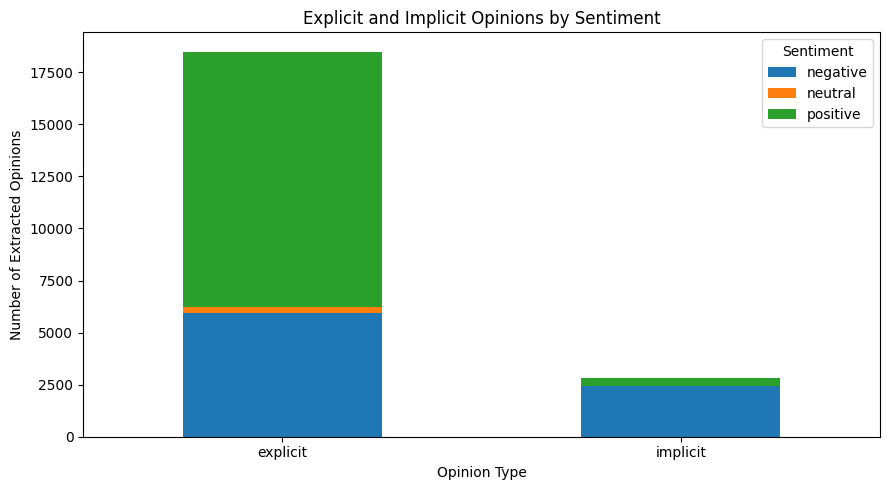


📋 Representative Explicit Opinions


,sentence,target,opinion_expression,sentiment
0,fleczy dee a boat plug am active for anything ...,fleczy dee a boat plug,active,positive
1,tiktok your board members are looking real cut...,real cute right,real cute,positive
2,"explain how ""sure ma'am"" is violating terms???","""sure ma'am",sure,positive
3,good but add a remove all repost button,a remove,good,positive
4,"love all the videos from funny to sad , real a...",all the videos,funny,positive
5,"love all the videos from funny to sad , real a...",all the videos,sad,negative
6,great app for me with good features as a conte...,great app,great,positive
7,great app for me with good features as a conte...,good features,good,positive
8,Disgusting negligence.,Disgusting negligence,Disgusting,negative
9,You let young kids bypass age checks easily an...,young kids,easily,positive



📋 Representative Implicit Opinions


,sentence,target,opinion_expression,sentiment
21,not a nice app its banned me for no reason so ...,account moderation,banned,negative
49,They removed my ability to repost videos for n...,content moderation,removed my,negative
64,I can barely use tiktok at all because of how ...,app performance,crashes,negative
70,Hello TikTok team I am finding the problem mes...,account moderation,violation,negative
89,they banned me for my face im 18 and they bann...,account moderation,banned,negative
92,"so I can add effects on writing, couldn't edit...",app performance,freeze,negative
93,"so I can add effects on writing, couldn't edit...",app performance,lag,negative
95,it crashes and closes even after being updated.,app performance,crashes,negative
96,It lags videos and it buffers the videos befor...,app performance,lags,negative
97,It lags videos and it buffers the videos befor...,app performance,crash,negative



✅ Opinion-mining summaries saved.
   Type summary : /content/drive/MyDrive/SMC_Assignment/phase_10_opinion_mining/phase10_opinion_type_summary.csv
   Target summary: /content/drive/MyDrive/SMC_Assignment/phase_10_opinion_mining/phase10_top_opinion_targets.csv
   Figure       : /content/drive/MyDrive/SMC_Assignment/phase_10_opinion_mining/phase10_explicit_implicit_opinions.png


In [ ]:
# ─────────────────────────────────────────────
# 9.4 OPINION-MINING SUMMARY AND VISUALISATION
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt

opinion_type_summary = (
    opinion_results_df
    .groupby(
        ["opinion_type", "sentiment"]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

target_summary = (
    opinion_results_df["target"]
    .value_counts()
    .head(15)
    .rename_axis("target")
    .reset_index(name="opinion_count")
)

OPINION_TYPE_SUMMARY_FILE = os.path.join(PHASE_10_DIR, 'phase10_opinion_type_summary.csv')

TARGET_SUMMARY_FILE = os.path.join(PHASE_10_DIR, 'phase10_top_opinion_targets.csv')

OPINION_FIGURE_FILE = os.path.join(PHASE_10_DIR, 'phase10_explicit_implicit_opinions.png')

opinion_type_summary.to_csv(
    OPINION_TYPE_SUMMARY_FILE
)

target_summary.to_csv(
    TARGET_SUMMARY_FILE,
    index=False
)

print("📊 Opinion Type by Sentiment")
display(opinion_type_summary)

print("\n🎯 Most Frequent Opinion Targets")
display(target_summary)

opinion_type_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title(
    "Explicit and Implicit Opinions by Sentiment"
)
plt.xlabel("Opinion Type")
plt.ylabel("Number of Extracted Opinions")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()

plt.savefig(
    OPINION_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n📋 Representative Explicit Opinions")
display(
    opinion_results_df[
        opinion_results_df["opinion_type"] == "explicit"
    ][
        [
            "sentence",
            "target",
            "opinion_expression",
            "sentiment"
        ]
    ].head(10)
)

print("\n📋 Representative Implicit Opinions")
display(
    opinion_results_df[
        opinion_results_df["opinion_type"] == "implicit"
    ][
        [
            "sentence",
            "target",
            "opinion_expression",
            "sentiment"
        ]
    ].head(10)
)

print("\n✅ Opinion-mining summaries saved.")
print(f"   Type summary : {OPINION_TYPE_SUMMARY_FILE}")
print(f"   Target summary: {TARGET_SUMMARY_FILE}")
print(f"   Figure       : {OPINION_FIGURE_FILE}")

---
# Phase 11: Aspect-Based Sentiment Analysis

## 4.11 Aspect-Based Sentiment Analysis

spaCy noun phrases and domain keywords identify candidate TikTok aspects. Generic phrases are removed and meaningful candidates are mapped to a controlled taxonomy. A fine-tuned DeBERTa ABSA model then predicts a separate sentiment for every sentence-aspect pair.

## 11.1 Load ABSA Data, Tokenizer and Model

In [ ]:
# ─────────────────────────────────────────────
# 10.1 LOAD ABSA DATA, TOKENIZER AND MODEL
# ─────────────────────────────────────────────

import os
import gc
import re
import sys
import subprocess
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

# Ensure sentencepiece is available for the DeBERTa tokenizer.
try:
    import sentencepiece
except ImportError:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "sentencepiece",
            "--quiet"
        ],
        check=True
    )

# Reuse the spaCy pipeline created in Phase 9.
if "nlp" not in globals():
    import spacy

    try:
        nlp = spacy.load("en_core_web_sm")
    except OSError:
        subprocess.run(
            [
                sys.executable,
                "-m",
                "spacy",
                "download",
                "en_core_web_sm"
            ],
            check=True
        )
        nlp = spacy.load("en_core_web_sm")

ABSA_MODEL_NAME = "yangheng/deberta-v3-base-absa-v1.1"

ABSA_MODEL_DIR = os.path.join(PHASE_11_DIR, 'absa_deberta_model')

ABSA_INPUT_FILE = os.path.join(PHASE_05_DIR, 'TikTok_Reviews_Phase5_Labeled.csv')

ABSA_DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

ABSA_BATCH_SIZE = 32
ABSA_MAX_LENGTH = 128

# None means use all currently cleaned reviews.
# Set an integer such as 1000 for a faster trial run.
ABSA_REVIEW_LIMIT = None

absa_source_df = pd.read_csv(
    ABSA_INPUT_FILE,
    index_col="review_id"
)

absa_source_df["review_text"] = (
    absa_source_df["review_text"]
    .fillna("")
    .astype(str)
)

if ABSA_REVIEW_LIMIT is not None:
    absa_work_df = absa_source_df.head(
        ABSA_REVIEW_LIMIT
    ).copy()
else:
    absa_work_df = absa_source_df.copy()

local_absa_is_complete = (
    os.path.exists(
        os.path.join(
            ABSA_MODEL_DIR,
            "config.json"
        )
    )
    and (
        os.path.exists(
            os.path.join(
                ABSA_MODEL_DIR,
                "model.safetensors"
            )
        )
        or os.path.exists(
            os.path.join(
                ABSA_MODEL_DIR,
                "pytorch_model.bin"
            )
        )
    )
)

absa_model_source = (
    ABSA_MODEL_DIR
    if local_absa_is_complete
    else ABSA_MODEL_NAME
)

print(f"⚙️ Loading ABSA model from: {absa_model_source}")

absa_tokenizer = AutoTokenizer.from_pretrained(
    absa_model_source
)

absa_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        absa_model_source
    )
    .to(ABSA_DEVICE)
)

absa_model.eval()

# Save the downloaded model once so future runs can load it from Drive.
if not local_absa_is_complete:
    os.makedirs(
        ABSA_MODEL_DIR,
        exist_ok=True
    )

    absa_model.save_pretrained(
        ABSA_MODEL_DIR
    )

    absa_tokenizer.save_pretrained(
        ABSA_MODEL_DIR
    )

print("✅ ABSA resources loaded.")
print(f"   Device             : {ABSA_DEVICE}")
print(f"   Reviews to analyse : {len(absa_work_df):,}")
print(f"   Saved model folder : {ABSA_MODEL_DIR}")

⚙️ Loading ABSA model from: yangheng/deberta-v3-base-absa-v1.1


config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ ABSA resources loaded.
   Device             : cuda
   Reviews to analyse : 20,173
   Saved model folder : /content/drive/MyDrive/SMC_Assignment/phase_11_absa/absa_deberta_model


## 11.2 Extract and Normalize Aspect Candidates

In [ ]:
# ─────────────────────────────────────────────
# 10.2 EXTRACT AND NORMALIZE ASPECT CANDIDATES
# ─────────────────────────────────────────────

from collections import OrderedDict
from tqdm.auto import tqdm

# Generic noun phrases that do not identify a useful product feature.
GENERIC_ASPECT_PHRASES = {
    "app",
    "the app",
    "this app",
    "tiktok",
    "tik tok",
    "thing",
    "this thing",
    "it",
    "this",
    "that",
    "something",
    "anything",
    "everything",
    "nothing",
    "people",
    "user",
    "users",
    "person",
    "someone"
}

# A checked TikTok-specific aspect taxonomy.
# Order matters: more specific categories appear before broad categories.
ASPECT_CATEGORY_KEYWORDS = OrderedDict({
    "Account Management": {
        "account", "login", "log in", "sign in", "password",
        "username", "profile", "ban", "banned", "suspension",
        "verification", "age restriction", "appeal"
    },

    "Content Moderation": {
        "moderation", "community guideline", "guideline",
        "violation", "content removal", "removed video",
        "deleted video", "report", "reporting", "censorship",
        "copyright", "strike"
    },

    "App Performance": {
        "performance", "crash", "crashing", "freeze",
        "freezing", "lag", "lagging", "loading", "speed",
        "slow", "bug", "glitch", "update", "storage",
        "battery", "data usage"
    },

    "Algorithm and Recommendations": {
        "algorithm", "recommendation", "recommendations",
        "for you page", "fyp", "feed", "timeline",
        "suggested video", "suggestion"
    },

    "Advertisements": {
        "ad", "ads", "advert", "advertisement",
        "advertisements", "sponsored content"
    },

    "Privacy and Security": {
        "privacy", "security", "permission", "permissions",
        "personal data", "data collection", "location",
        "camera permission", "microphone permission"
    },

    "Messaging and Social Features": {
        "message", "messages", "messaging", "direct message",
        "dm", "chat", "friend", "friends", "follower",
        "followers", "following", "comment", "comments",
        "share", "sharing"
    },

    "Video Creation and Editing": {
        "camera", "video", "videos", "upload", "uploading",
        "editor", "editing", "filter", "filters", "effect",
        "effects", "sound", "sounds", "music", "draft",
        "drafts", "caption", "captions", "recording"
    },

    "Customer Support": {
        "support", "customer service", "help centre",
        "help center", "response", "staff", "developer",
        "developers"
    },

    "Notifications": {
        "notification", "notifications", "alert", "alerts"
    },

    "Monetization and Purchases": {
        "coin", "coins", "payment", "payments", "purchase",
        "purchases", "shop", "shopping", "gift", "gifts",
        "creator fund", "monetization", "subscription",
        "live", "livestream"
    }
})


def normalize_aspect_phrase(phrase):
    """Normalize a noun phrase before filtering and mapping."""
    phrase = str(phrase).lower().strip()

    phrase = re.sub(
        r"[^a-z0-9\s'-]",
        " ",
        phrase
    )

    phrase = re.sub(
        r"\s+",
        " ",
        phrase
    ).strip()

    return phrase


def map_aspect_category(aspect_phrase):
    """Map a raw noun phrase to the checked TikTok aspect taxonomy."""
    normalized_phrase = normalize_aspect_phrase(
        aspect_phrase
    )

    for category, keywords in ASPECT_CATEGORY_KEYWORDS.items():
        for keyword in keywords:
            if (
                normalized_phrase == keyword
                or keyword in normalized_phrase
                or normalized_phrase in keyword
            ):
                return category

    return None


def valid_noun_phrase(chunk):
    """Return True only for useful noun-phrase aspect candidates."""
    normalized_phrase = normalize_aspect_phrase(
        chunk.text
    )

    if not normalized_phrase:
        return False

    if normalized_phrase in GENERIC_ASPECT_PHRASES:
        return False

    if len(normalized_phrase) < 2:
        return False

    if len(normalized_phrase.split()) > 6:
        return False

    # Require at least one content noun or proper noun.
    if not any(
        token.pos_ in {"NOUN", "PROPN"}
        for token in chunk
    ):
        return False

    return True


aspect_candidate_records = []

review_ids = absa_work_df.index.tolist()
review_texts = absa_work_df["review_text"].tolist()

parsed_reviews = nlp.pipe(
    review_texts,
    batch_size=64
)

for review_id, document in tqdm(
    zip(review_ids, parsed_reviews),
    total=len(review_ids),
    desc="Extracting aspect candidates"
):
    source_row = absa_work_df.loc[review_id]

    for sentence in document.sents:
        sentence_text = sentence.text.strip()

        if not sentence_text:
            continue

        sentence_candidates = set()

        # Primary extraction: spaCy noun phrases.
        for noun_chunk in sentence.noun_chunks:
            if not valid_noun_phrase(noun_chunk):
                continue

            raw_aspect = normalize_aspect_phrase(
                noun_chunk.text
            )

            aspect_category = map_aspect_category(
                raw_aspect
            )

            if aspect_category is None:
                continue

            sentence_candidates.add(
                (
                    raw_aspect,
                    aspect_category,
                    "spacy_noun_phrase"
                )
            )

        # Supplement explicit technical terms that spaCy may tokenize
        # outside a complete noun phrase.
        normalized_sentence = normalize_aspect_phrase(
            sentence_text
        )

        for category, keywords in ASPECT_CATEGORY_KEYWORDS.items():
            for keyword in keywords:
                if keyword in normalized_sentence:
                    if keyword not in GENERIC_ASPECT_PHRASES:
                        sentence_candidates.add(
                            (
                                keyword,
                                category,
                                "domain_keyword"
                            )
                        )
                    break

        for (
            raw_aspect,
            aspect_category,
            extraction_method
        ) in sorted(sentence_candidates):
            aspect_candidate_records.append({
                "review_id": review_id,
                "review_text": source_row["review_text"],
                "sentence": sentence_text,
                "raw_aspect": raw_aspect,
                "aspect_category": aspect_category,
                "extraction_method": extraction_method,
                "review_sentiment_label": source_row.get(
                    "sentiment_label",
                    np.nan
                ),
                "rating": source_row.get(
                    "rating",
                    np.nan
                )
            })

aspect_candidates_df = pd.DataFrame(
    aspect_candidate_records
)

if aspect_candidates_df.empty:
    raise ValueError(
        "No meaningful aspect candidates were found. "
        "Check the taxonomy and input data."
    )

aspect_candidates_df = (
    aspect_candidates_df
    .drop_duplicates(
        subset=[
            "review_id",
            "sentence",
            "raw_aspect",
            "aspect_category"
        ]
    )
    .reset_index(drop=True)
)

ASPECT_CANDIDATES_FILE = os.path.join(PHASE_11_DIR, 'phase11_absa_aspect_candidates.csv')

aspect_candidates_df.to_csv(
    ASPECT_CANDIDATES_FILE,
    index=False
)

print("\n✅ Aspect extraction completed.")
print(f"   Candidate pairs: {len(aspect_candidates_df):,}")
print(f"   Saved to       : {ASPECT_CANDIDATES_FILE}")

display(
    aspect_candidates_df[
        [
            "sentence",
            "raw_aspect",
            "aspect_category",
            "extraction_method"
        ]
    ].head(20)
)

Extracting aspect candidates:   0%|          | 0/20173 [00:00<?, ?it/s]


✅ Aspect extraction completed.
   Candidate pairs: 38,664
   Saved to       : /content/drive/MyDrive/SMC_Assignment/phase_11_absa/phase11_absa_aspect_candidates.csv


,sentence,raw_aspect,aspect_category,extraction_method
0,you're gonna have a lawsuit on your hands appe...,appeal,Account Management,domain_keyword
1,you're gonna have a lawsuit on your hands appe...,comment,Messaging and Social Features,domain_keyword
2,you're gonna have a lawsuit on your hands appe...,the same comment,Messaging and Social Features,spacy_noun_phrase
3,good but add a remove all repost button,ad,Advertisements,domain_keyword
4,"love all the videos from funny to sad , real a...",ad,Advertisements,domain_keyword
5,"love all the videos from funny to sad , real a...",all the videos,Video Creation and Editing,spacy_noun_phrase
6,"love all the videos from funny to sad , real a...",videos,Video Creation and Editing,domain_keyword
7,You let young kids bypass age checks easily an...,algorithm,Algorithm and Recommendations,domain_keyword
8,You let young kids bypass age checks easily an...,your algorithm,Algorithm and Recommendations,spacy_noun_phrase
9,"Minors cyberbullying, scamming TikTok Shop sel...",shop,Monetization and Purchases,domain_keyword


## 11.3 Predict Aspect-Level Sentiment

In [ ]:
# ─────────────────────────────────────────────
# 10.3 RUN THE FINE-TUNED ABSA MODEL
# ─────────────────────────────────────────────

from tqdm.auto import tqdm


def normalize_absa_label(
    raw_label,
    predicted_index
):
    """
    Normalize model labels into:
    negative, neutral or positive.
    """
    label_text = str(raw_label).lower()

    if "negative" in label_text:
        return "negative"

    if "neutral" in label_text:
        return "neutral"

    if "positive" in label_text:
        return "positive"

    # Fallback for generic LABEL_0, LABEL_1, LABEL_2 configurations.
    fallback_mapping = {
        0: "negative",
        1: "neutral",
        2: "positive"
    }

    return fallback_mapping.get(
        int(predicted_index),
        label_text
    )


def predict_aspect_sentiment(
    dataframe,
    batch_size=ABSA_BATCH_SIZE
):
    """
    Predict sentiment for each sentence-aspect pair.

    The sentence is the main text and the extracted raw aspect term
    is supplied as the paired text.
    """
    predicted_labels = []
    confidence_scores = []
    negative_probabilities = []
    neutral_probabilities = []
    positive_probabilities = []

    sentences = (
        dataframe["sentence"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    aspects = (
        dataframe["raw_aspect"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    id_to_label = {
        int(index): label
        for index, label in absa_model.config.id2label.items()
    }

    for start_index in tqdm(
        range(0, len(dataframe), batch_size),
        desc="Running ABSA inference"
    ):
        end_index = start_index + batch_size

        batch_sentences = sentences[
            start_index:end_index
        ]

        batch_aspects = aspects[
            start_index:end_index
        ]

        encoded_batch = absa_tokenizer(
            batch_sentences,
            batch_aspects,
            padding=True,
            truncation=True,
            max_length=ABSA_MAX_LENGTH,
            return_tensors="pt"
        )

        encoded_batch = {
            key: value.to(ABSA_DEVICE)
            for key, value in encoded_batch.items()
        }

        with torch.no_grad():
            outputs = absa_model(
                **encoded_batch
            )

            probabilities = torch.softmax(
                outputs.logits,
                dim=-1
            )

        probabilities = (
            probabilities
            .detach()
            .cpu()
            .numpy()
        )

        batch_prediction_indices = np.argmax(
            probabilities,
            axis=1
        )

        for probability_row, predicted_index in zip(
            probabilities,
            batch_prediction_indices
        ):
            raw_label = id_to_label.get(
                int(predicted_index),
                f"LABEL_{predicted_index}"
            )

            normalized_label = normalize_absa_label(
                raw_label,
                predicted_index
            )

            probability_by_label = {
                normalize_absa_label(
                    id_to_label.get(
                        class_index,
                        f"LABEL_{class_index}"
                    ),
                    class_index
                ): float(class_probability)
                for class_index, class_probability
                in enumerate(probability_row)
            }

            predicted_labels.append(
                normalized_label
            )

            confidence_scores.append(
                float(
                    probability_row[
                        predicted_index
                    ]
                )
            )

            negative_probabilities.append(
                probability_by_label.get(
                    "negative",
                    np.nan
                )
            )

            neutral_probabilities.append(
                probability_by_label.get(
                    "neutral",
                    np.nan
                )
            )

            positive_probabilities.append(
                probability_by_label.get(
                    "positive",
                    np.nan
                )
            )

    return {
        "aspect_sentiment": predicted_labels,
        "absa_confidence": confidence_scores,
        "negative_probability": negative_probabilities,
        "neutral_probability": neutral_probabilities,
        "positive_probability": positive_probabilities
    }


absa_predictions = predict_aspect_sentiment(
    aspect_candidates_df
)

absa_results_df = aspect_candidates_df.copy()

for output_column, output_values in absa_predictions.items():
    absa_results_df[output_column] = output_values

ABSA_RESULTS_FILE = os.path.join(PHASE_11_DIR, 'phase11_absa_results.csv')

absa_results_df.to_csv(
    ABSA_RESULTS_FILE,
    index=False
)

print("\n✅ ABSA inference completed.")
print(f"   Aspect-sentiment pairs: {len(absa_results_df):,}")
print(f"   Saved to              : {ABSA_RESULTS_FILE}")

display(
    absa_results_df[
        [
            "sentence",
            "raw_aspect",
            "aspect_category",
            "aspect_sentiment",
            "absa_confidence"
        ]
    ].head(20)
)

# Release GPU memory before later visualisation cells.
absa_model.to("cpu")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

gc.collect()

Running ABSA inference:   0%|          | 0/1209 [00:00<?, ?it/s]


✅ ABSA inference completed.
   Aspect-sentiment pairs: 38,664
   Saved to              : /content/drive/MyDrive/SMC_Assignment/phase_11_absa/phase11_absa_results.csv


,sentence,raw_aspect,aspect_category,aspect_sentiment,absa_confidence
0,you're gonna have a lawsuit on your hands appe...,appeal,Account Management,neutral,0.842471
1,you're gonna have a lawsuit on your hands appe...,comment,Messaging and Social Features,negative,0.916746
2,you're gonna have a lawsuit on your hands appe...,the same comment,Messaging and Social Features,negative,0.907939
3,good but add a remove all repost button,ad,Advertisements,positive,0.576858
4,"love all the videos from funny to sad , real a...",ad,Advertisements,positive,0.848343
5,"love all the videos from funny to sad , real a...",all the videos,Video Creation and Editing,positive,0.998360
6,"love all the videos from funny to sad , real a...",videos,Video Creation and Editing,positive,0.997978
7,You let young kids bypass age checks easily an...,algorithm,Algorithm and Recommendations,negative,0.990334
8,You let young kids bypass age checks easily an...,your algorithm,Algorithm and Recommendations,negative,0.984472
9,"Minors cyberbullying, scamming TikTok Shop sel...",shop,Monetization and Purchases,neutral,0.996758


7168

## 11.4 Summarize Aspect-Level Sentiment

In [ ]:
# ─────────────────────────────────────────────
# 10.4 SUMMARIZE ASPECT-LEVEL SENTIMENT
# ─────────────────────────────────────────────

aspect_sentiment_counts = (
    absa_results_df
    .groupby(
        [
            "aspect_category",
            "aspect_sentiment"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

for sentiment_name in [
    "negative",
    "neutral",
    "positive"
]:
    if sentiment_name not in aspect_sentiment_counts.columns:
        aspect_sentiment_counts[
            sentiment_name
        ] = 0

aspect_sentiment_counts = (
    aspect_sentiment_counts[
        [
            "negative",
            "neutral",
            "positive"
        ]
    ]
)

aspect_sentiment_percentages = (
    aspect_sentiment_counts
    .div(
        aspect_sentiment_counts.sum(axis=1),
        axis=0
    )
    .mul(100)
    .round(2)
)

aspect_summary_df = (
    aspect_sentiment_counts
    .reset_index()
)

aspect_summary_df["total_mentions"] = (
    aspect_summary_df[
        [
            "negative",
            "neutral",
            "positive"
        ]
    ]
    .sum(axis=1)
)

aspect_summary_df["negative_percentage"] = (
    aspect_summary_df["negative"]
    / aspect_summary_df["total_mentions"]
    * 100
).round(2)

aspect_summary_df["neutral_percentage"] = (
    aspect_summary_df["neutral"]
    / aspect_summary_df["total_mentions"]
    * 100
).round(2)

aspect_summary_df["positive_percentage"] = (
    aspect_summary_df["positive"]
    / aspect_summary_df["total_mentions"]
    * 100
).round(2)

aspect_summary_df = aspect_summary_df.sort_values(
    by="total_mentions",
    ascending=False
).reset_index(drop=True)

ABSA_COUNT_SUMMARY_FILE = os.path.join(PHASE_11_DIR, 'phase11_absa_aspect_sentiment_counts.csv')

ABSA_PERCENTAGE_SUMMARY_FILE = os.path.join(PHASE_11_DIR, 'phase11_absa_aspect_sentiment_percentages.csv')

ABSA_ASPECT_SUMMARY_FILE = os.path.join(PHASE_11_DIR, 'phase11_absa_aspect_summary.csv')

aspect_sentiment_counts.to_csv(
    ABSA_COUNT_SUMMARY_FILE
)

aspect_sentiment_percentages.to_csv(
    ABSA_PERCENTAGE_SUMMARY_FILE
)

aspect_summary_df.to_csv(
    ABSA_ASPECT_SUMMARY_FILE,
    index=False
)

print("📊 Aspect-Sentiment Counts")
display(aspect_sentiment_counts)

print("\n📊 Aspect-Sentiment Percentages")
display(aspect_sentiment_percentages)

print("\n📊 Ranked Aspect Summary")
display(aspect_summary_df)

print("\n✅ ABSA summaries saved.")
print(f"   Counts      : {ABSA_COUNT_SUMMARY_FILE}")
print(f"   Percentages : {ABSA_PERCENTAGE_SUMMARY_FILE}")
print(f"   Summary     : {ABSA_ASPECT_SUMMARY_FILE}")

📊 Aspect-Sentiment Counts


aspect_sentiment,negative,neutral,positive
aspect_category,,,
Account Management,4583,1935,717
Advertisements,3976,1141,885
Algorithm and Recommendations,941,355,329
App Performance,3966,443,347
Content Moderation,1620,436,221
Customer Support,687,136,206
Messaging and Social Features,2292,1661,722
Monetization and Purchases,998,695,469
Notifications,234,48,22



📊 Aspect-Sentiment Percentages


aspect_sentiment,negative,neutral,positive
aspect_category,,,
Account Management,63.34,26.74,9.91
Advertisements,66.24,19.01,14.75
Algorithm and Recommendations,57.91,21.85,20.25
App Performance,83.39,9.31,7.30
Content Moderation,71.15,19.15,9.71
Customer Support,66.76,13.22,20.02
Messaging and Social Features,49.03,35.53,15.44
Monetization and Purchases,46.16,32.15,21.69
Notifications,76.97,15.79,7.24



📊 Ranked Aspect Summary


aspect_sentiment,aspect_category,negative,neutral,positive,total_mentions,negative_percentage,neutral_percentage,positive_percentage
0,Video Creation and Editing,4026,2085,1895,8006,50.29,26.04,23.67
1,Account Management,4583,1935,717,7235,63.34,26.74,9.91
2,Advertisements,3976,1141,885,6002,66.24,19.01,14.75
3,App Performance,3966,443,347,4756,83.39,9.31,7.30
4,Messaging and Social Features,2292,1661,722,4675,49.03,35.53,15.44
5,Content Moderation,1620,436,221,2277,71.15,19.15,9.71
6,Monetization and Purchases,998,695,469,2162,46.16,32.15,21.69
7,Algorithm and Recommendations,941,355,329,1625,57.91,21.85,20.25
8,Customer Support,687,136,206,1029,66.76,13.22,20.02
9,Privacy and Security,394,147,52,593,66.44,24.79,8.77



✅ ABSA summaries saved.
   Counts      : /content/drive/MyDrive/SMC_Assignment/phase_11_absa/phase11_absa_aspect_sentiment_counts.csv
   Percentages : /content/drive/MyDrive/SMC_Assignment/phase_11_absa/phase11_absa_aspect_sentiment_percentages.csv
   Summary     : /content/drive/MyDrive/SMC_Assignment/phase_11_absa/phase11_absa_aspect_summary.csv


---
# Phase 12: Visualization

## 4.12 Visualization

The final results are visualized using Matplotlib, Seaborn and WordCloud. The core outputs include:

- overall sentiment distribution,
- positive and negative word clouds,
- sentiment distribution for each TikTok aspect,
- held-out model-performance comparison,
- five-fold cross-validation comparison.

All figures are displayed in the notebook and saved as PNG files for the report and presentation.

A separate analytical subsection then uses the same results to answer the four project questions and produce actionable complaint profiles supported by bigrams, trigrams and four-grams.

## 12.1 Visualization Setup and Data Loading

In [ ]:
import os
import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    from wordcloud import WordCloud
except ImportError:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "wordcloud",
            "--quiet"
        ],
        check=True
    )
    from wordcloud import WordCloud


PHASE12_OUTPUT_DIR = PHASE_12_DIR

PHASE12_ANALYTICAL_DIR = os.path.join(
    PHASE12_OUTPUT_DIR,
    "analytical_questions"
)

os.makedirs(
    PHASE12_OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    PHASE12_ANALYTICAL_DIR,
    exist_ok=True
)

PHASE12_LABELED_FILE = os.path.join(PHASE_05_DIR, 'TikTok_Reviews_Phase5_Labeled.csv')

PHASE12_ABSA_FILE = os.path.join(PHASE_11_DIR, 'phase11_absa_results.csv')

PHASE12_MODEL_EVALUATION_FILE = os.path.join(PHASE_09_HELDOUT_DIR, 'phase9_model_evaluation.csv')

PHASE12_CV_SUMMARY_FILE = os.path.join(PHASE_09_CV_DIR,
    "phase9_all_models_5fold_summary.csv"
)

required_phase12_files = {
    "Labeled review data": PHASE12_LABELED_FILE,
    "ABSA results": PHASE12_ABSA_FILE,
    "Held-out model evaluation": PHASE12_MODEL_EVALUATION_FILE,
    "Five-fold CV summary": PHASE12_CV_SUMMARY_FILE
}

missing_phase12_files = [
    f"{name}: {path}"
    for name, path in required_phase12_files.items()
    if not os.path.exists(path)
]

if missing_phase12_files:
    raise FileNotFoundError(
        "Run the required earlier phases first. "
        "The following files are missing:\n\n"
        + "\n".join(missing_phase12_files)
    )

phase12_reviews_df = pd.read_csv(
    PHASE12_LABELED_FILE
)

phase12_absa_df = pd.read_csv(
    PHASE12_ABSA_FILE
)

phase12_model_df = pd.read_csv(
    PHASE12_MODEL_EVALUATION_FILE
)

phase12_cv_df = pd.read_csv(
    PHASE12_CV_SUMMARY_FILE
)

phase12_reviews_df["review_text"] = (
    phase12_reviews_df["review_text"]
    .fillna("")
    .astype(str)
)

phase12_reviews_df["processed_text"] = (
    phase12_reviews_df["processed_text"]
    .fillna("")
    .astype(str)
)

phase12_reviews_df["sentiment_label"] = (
    phase12_reviews_df["sentiment_label"]
    .fillna("neutral")
    .astype(str)
    .str.lower()
)

phase12_absa_df["aspect_category"] = (
    phase12_absa_df["aspect_category"]
    .fillna("Other")
    .astype(str)
)

phase12_absa_df["aspect_sentiment"] = (
    phase12_absa_df["aspect_sentiment"]
    .fillna("neutral")
    .astype(str)
    .str.lower()
)

SENTIMENT_ORDER = [
    "negative",
    "neutral",
    "positive"
]

MODEL_PARADIGM = {
    "SVM": "Traditional Machine Learning",
    "GRU": "Deep Learning",
    "BERT": "Transformer"
}

phase12_model_df["Paradigm"] = (
    phase12_model_df["Model"]
    .map(MODEL_PARADIGM)
    .fillna(
        phase12_model_df["Model"]
    )
)

phase12_cv_df["Paradigm"] = (
    phase12_cv_df["Model"]
    .map(MODEL_PARADIGM)
    .fillna(
        phase12_cv_df["Model"]
    )
)

print("✅ Phase 12 data loaded.")
print(f"   Reviews      : {len(phase12_reviews_df):,}")
print(f"   Aspect pairs : {len(phase12_absa_df):,}")
print(f"   Output folder: {PHASE12_OUTPUT_DIR}")

✅ Phase 12 data loaded.
   Reviews      : 20,173
   Aspect pairs : 38,664
   Output folder: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization


## 12.2 Overall Sentiment Distribution

This chart shows the number and percentage of positive, neutral and negative VADER-labeled reviews.

,sentiment,review_count,percentage
0,negative,"6,397",31.71%
1,neutral,"3,209",15.91%
2,positive,"10,567",52.38%


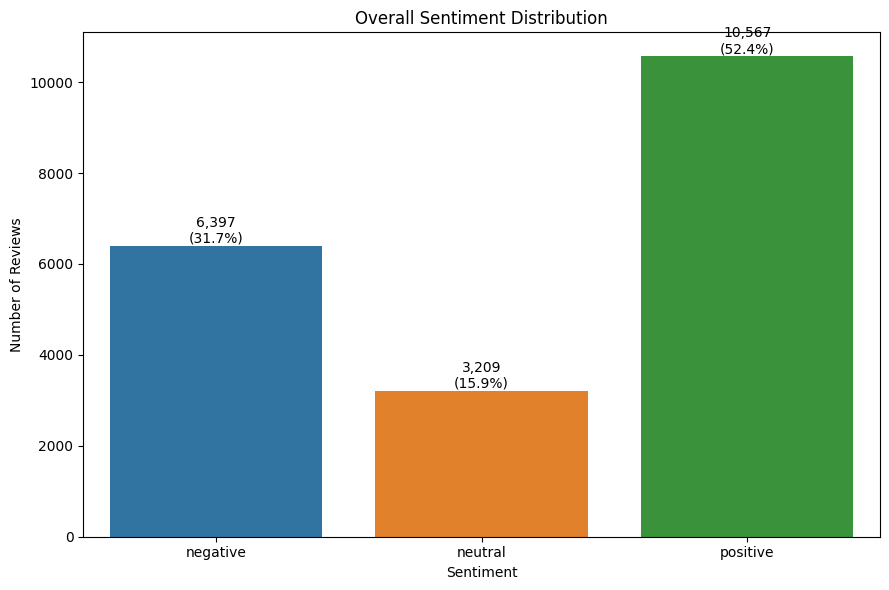

✅ Saved: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/overall_sentiment_distribution.png


In [ ]:
sentiment_counts = (
    phase12_reviews_df["sentiment_label"]
    .value_counts()
    .reindex(
        SENTIMENT_ORDER,
        fill_value=0
    )
)

sentiment_summary_df = pd.DataFrame({
    "sentiment": SENTIMENT_ORDER,
    "review_count": sentiment_counts.values,
    "percentage": (
        sentiment_counts.values
        / sentiment_counts.values.sum()
        * 100
    )
})

display(
    sentiment_summary_df.style.format({
        "review_count": "{:,.0f}",
        "percentage": "{:.2f}%"
    })
)

plt.figure(figsize=(9, 6))

axis = sns.barplot(
    data=sentiment_summary_df,
    x="sentiment",
    y="review_count",
    hue="sentiment",
    legend=False
)

axis.set_title(
    "Overall Sentiment Distribution"
)
axis.set_xlabel("Sentiment")
axis.set_ylabel("Number of Reviews")

for bar, count, percentage in zip(
    axis.patches,
    sentiment_summary_df["review_count"],
    sentiment_summary_df["percentage"]
):
    axis.annotate(
        f"{int(count):,}\n({percentage:.1f}%)",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

SENTIMENT_DISTRIBUTION_FILE = os.path.join(
    PHASE12_OUTPUT_DIR,
    "overall_sentiment_distribution.png"
)

plt.savefig(
    SENTIMENT_DISTRIBUTION_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Saved: {SENTIMENT_DISTRIBUTION_FILE}")

## 12.3 Positive and Negative Word Clouds

The word clouds provide a quick visual overview of terms that occur frequently in positive and negative processed reviews.

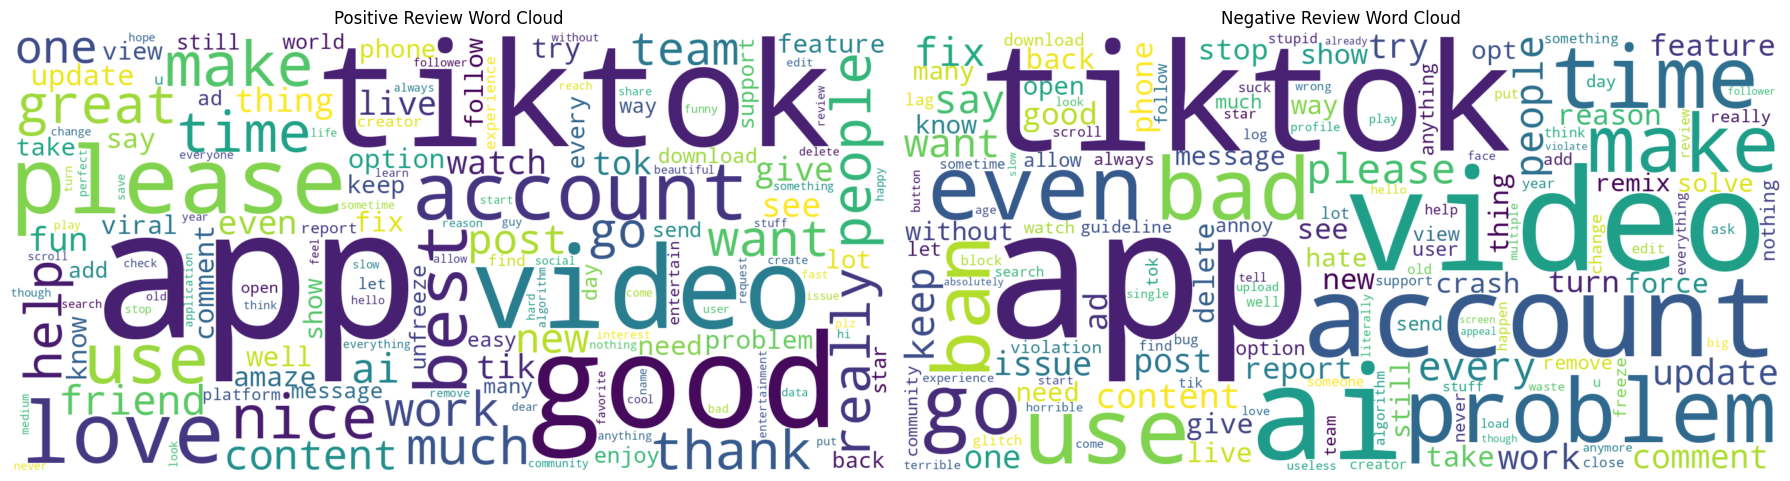

✅ Saved: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/positive_negative_wordclouds.png


In [ ]:
positive_text = " ".join(
    phase12_reviews_df.loc[
        phase12_reviews_df["sentiment_label"] == "positive",
        "processed_text"
    ].tolist()
)

negative_text = " ".join(
    phase12_reviews_df.loc[
        phase12_reviews_df["sentiment_label"] == "negative",
        "processed_text"
    ].tolist()
)

if not positive_text.strip():
    positive_text = "no positive terms"

if not negative_text.strip():
    negative_text = "no negative terms"

positive_wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=150,
    collocations=False,
    random_state=RANDOM_STATE
).generate(positive_text)

negative_wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=150,
    collocations=False,
    random_state=RANDOM_STATE
).generate(negative_text)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)

axes[0].imshow(
    positive_wordcloud,
    interpolation="bilinear"
)
axes[0].set_title(
    "Positive Review Word Cloud"
)
axes[0].axis("off")

axes[1].imshow(
    negative_wordcloud,
    interpolation="bilinear"
)
axes[1].set_title(
    "Negative Review Word Cloud"
)
axes[1].axis("off")

figure.tight_layout()

WORDCLOUD_FILE = os.path.join(
    PHASE12_OUTPUT_DIR,
    "positive_negative_wordclouds.png"
)

plt.savefig(
    WORDCLOUD_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Saved: {WORDCLOUD_FILE}")

## 12.4 Sentiment Distribution by TikTok Aspect

The stacked horizontal bar chart compares the proportion of negative, neutral and positive predictions for every mapped TikTok aspect. The graph is displayed in the notebook and saved as a PNG file for use in the report and presentation.


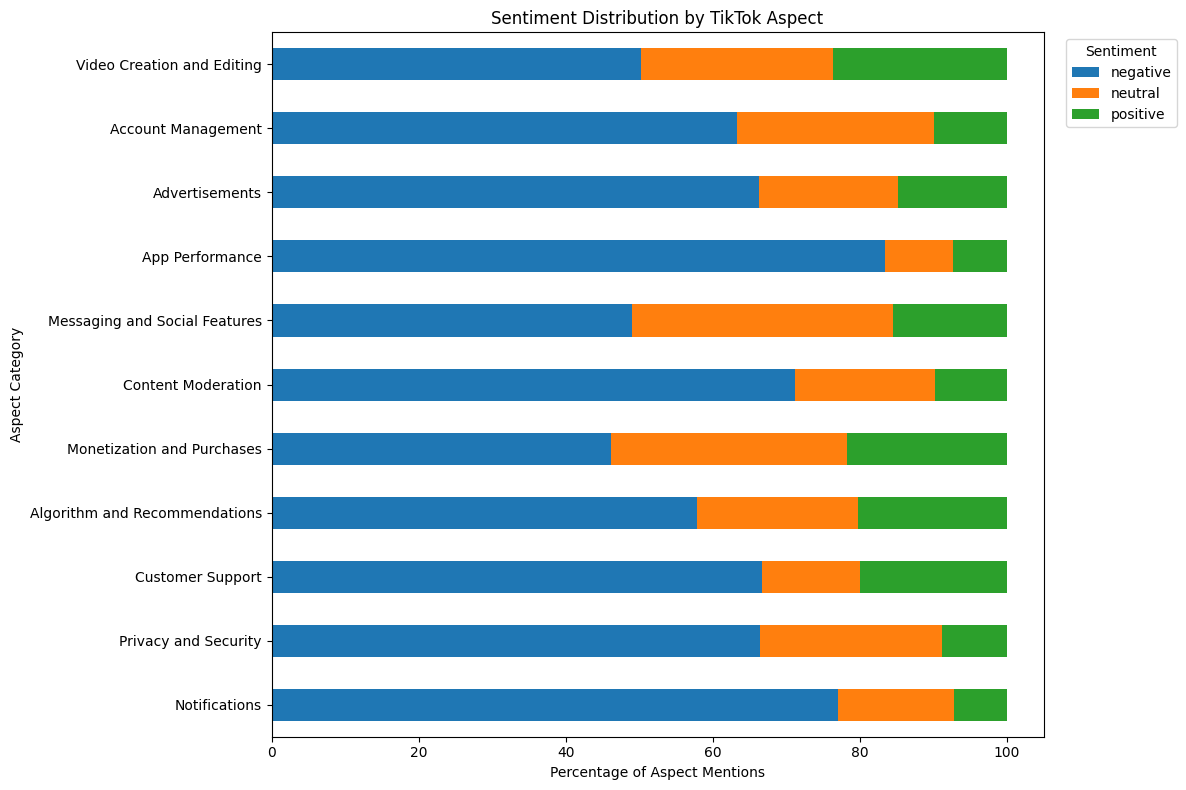

✅ Figure saved: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/aspect_sentiment_distribution.png


In [ ]:
aspect_sentiment_counts = pd.crosstab(
    phase12_absa_df["aspect_category"],
    phase12_absa_df["aspect_sentiment"]
)

for sentiment_name in SENTIMENT_ORDER:
    if sentiment_name not in aspect_sentiment_counts.columns:
        aspect_sentiment_counts[
            sentiment_name
        ] = 0

aspect_sentiment_counts = (
    aspect_sentiment_counts[
        SENTIMENT_ORDER
    ]
)

aspect_sentiment_percentages = (
    aspect_sentiment_counts
    .div(
        aspect_sentiment_counts.sum(axis=1),
        axis=0
    )
    .mul(100)
)

aspect_order = (
    aspect_sentiment_counts
    .sum(axis=1)
    .sort_values(ascending=True)
    .index
)

aspect_sentiment_percentages = (
    aspect_sentiment_percentages
    .loc[aspect_order]
)

aspect_sentiment_percentages.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 8)
)

plt.title(
    "Sentiment Distribution by TikTok Aspect"
)
plt.xlabel(
    "Percentage of Aspect Mentions"
)
plt.ylabel(
    "Aspect Category"
)
plt.legend(
    title="Sentiment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

ASPECT_SENTIMENT_FILE = os.path.join(
    PHASE12_OUTPUT_DIR,
    "aspect_sentiment_distribution.png"
)

plt.savefig(
    ASPECT_SENTIMENT_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(f"✅ Figure saved: {ASPECT_SENTIMENT_FILE}")


## 12.5 Held-Out Model-Performance Comparison

Accuracy, Macro F1 and Weighted F1 are compared across SVM, GRU and BERT on the untouched test split.

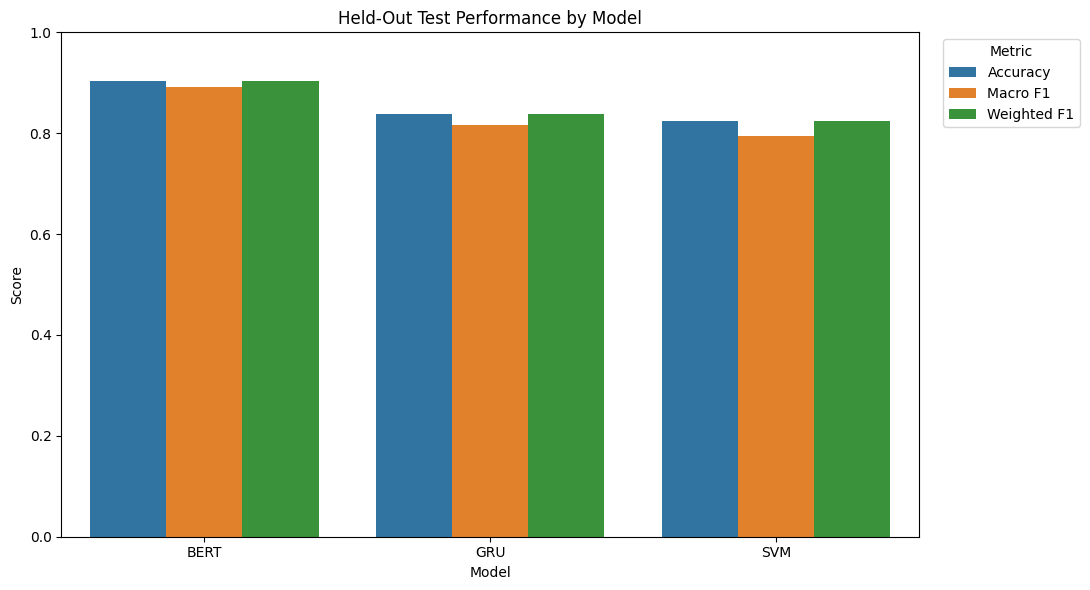

✅ Figure saved: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/held_out_model_performance.png


In [ ]:
held_out_metrics = phase12_model_df.melt(
    id_vars=[
        "Model",
        "Paradigm"
    ],
    value_vars=[
        "Accuracy",
        "Macro F1",
        "Weighted F1"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=held_out_metrics,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Held-Out Test Performance by Model"
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

HELD_OUT_MODEL_FILE = os.path.join(
    PHASE12_OUTPUT_DIR,
    "held_out_model_performance.png"
)

plt.savefig(
    HELD_OUT_MODEL_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(f"✅ Figure saved: {HELD_OUT_MODEL_FILE}")


## 12.6 Five-Fold Cross-Validation Comparison

Mean Macro F1 is displayed with standard-deviation error bars to compare both average performance and fold-to-fold stability.

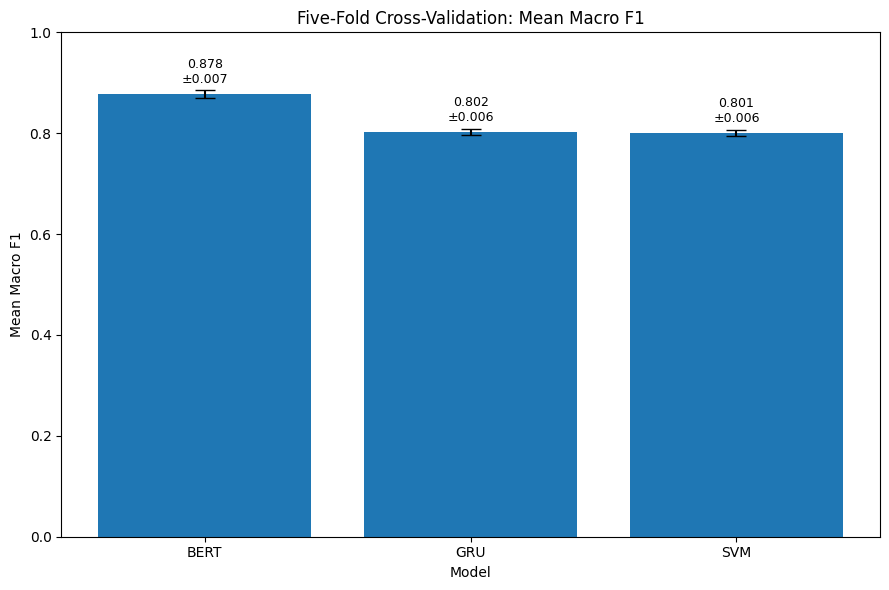

✅ Saved: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/five_fold_model_macro_f1.png


In [ ]:
cv_plot_df = phase12_cv_df.sort_values(
    "Macro F1 Mean",
    ascending=False
).copy()

plt.figure(figsize=(9, 6))

bars = plt.bar(
    cv_plot_df["Model"],
    cv_plot_df["Macro F1 Mean"],
    yerr=cv_plot_df["Macro F1 Std"],
    capsize=7
)

plt.title(
    "Five-Fold Cross-Validation: Mean Macro F1"
)
plt.xlabel("Model")
plt.ylabel("Mean Macro F1")
plt.ylim(0, 1)

for bar, mean_score, standard_deviation in zip(
    bars,
    cv_plot_df["Macro F1 Mean"],
    cv_plot_df["Macro F1 Std"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + standard_deviation + 0.015,
        f"{mean_score:.3f}\n±{standard_deviation:.3f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

CV_MODEL_FILE = os.path.join(
    PHASE12_OUTPUT_DIR,
    "five_fold_model_macro_f1.png"
)

plt.savefig(
    CV_MODEL_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Saved: {CV_MODEL_FILE}")

---
## 12.7 Analytical Questions

The following subsections transform the Phase 12 outputs into direct evidence for the four project questions.

1. What is the distribution of sentiment in TikTok Google Play reviews?
2. Which TikTok features are linked to negative sentiment?
3. What performance differences are observed among traditional ML, deep learning and transformer models, and why?
4. What actionable insights can be developed from the complaint profiles?

### 12.7.1 Analytical Question 1 — Sentiment Distribution

,sentiment,review_count,percentage
0,positive,"10,567",52.38%
1,negative,"6,397",31.71%
2,neutral,"3,209",15.91%


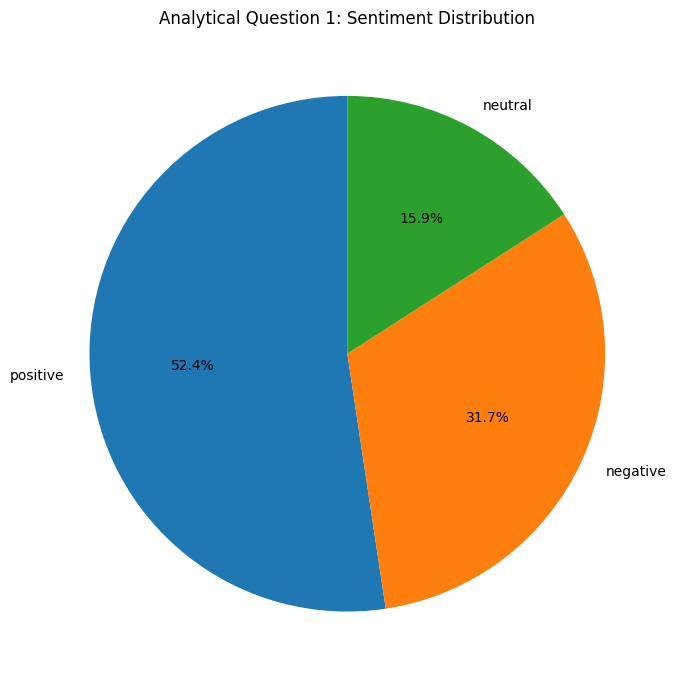

Answer: Positive is the largest sentiment group, representing 52.38% of the analyzed reviews.
✅ Saved: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/analytical_questions/question1_sentiment_distribution.png


In [ ]:
question1_summary_df = (
    sentiment_summary_df
    .sort_values(
        "review_count",
        ascending=False
    )
    .reset_index(drop=True)
)

dominant_sentiment_row = (
    question1_summary_df.iloc[0]
)

display(
    question1_summary_df.style.format({
        "review_count": "{:,.0f}",
        "percentage": "{:.2f}%"
    })
)

plt.figure(figsize=(7, 7))

plt.pie(
    question1_summary_df["review_count"],
    labels=question1_summary_df["sentiment"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Analytical Question 1: "
    "Sentiment Distribution"
)

plt.tight_layout()

QUESTION1_FIGURE = os.path.join(
    PHASE12_ANALYTICAL_DIR,
    "question1_sentiment_distribution.png"
)

plt.savefig(
    QUESTION1_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Answer: {dominant_sentiment_row['sentiment'].title()} "
    f"is the largest sentiment group, representing "
    f"{dominant_sentiment_row['percentage']:.2f}% "
    f"of the analyzed reviews."
)

print(f"✅ Saved: {QUESTION1_FIGURE}")

### 12.7.2 Analytical Question 2 — TikTok Features Linked to Negative Sentiment

Negative complaint **volume** shows how frequently an aspect is criticized. Negative **rate** shows how strongly an aspect is associated with negative sentiment relative to all of its mentions. Both measures are needed because a frequently discussed feature may have many complaints without having the highest negative proportion.

aspect_sentiment,aspect_category,negative,neutral,positive,total_mentions,negative_rate
0,Account Management,4583,1935,717,7235,63.34%
1,Video Creation and Editing,4026,2085,1895,8006,50.29%
2,Advertisements,3976,1141,885,6002,66.24%
3,App Performance,3966,443,347,4756,83.39%
4,Messaging and Social Features,2292,1661,722,4675,49.03%
5,Content Moderation,1620,436,221,2277,71.15%
6,Monetization and Purchases,998,695,469,2162,46.16%
7,Algorithm and Recommendations,941,355,329,1625,57.91%
8,Customer Support,687,136,206,1029,66.76%
9,Privacy and Security,394,147,52,593,66.44%


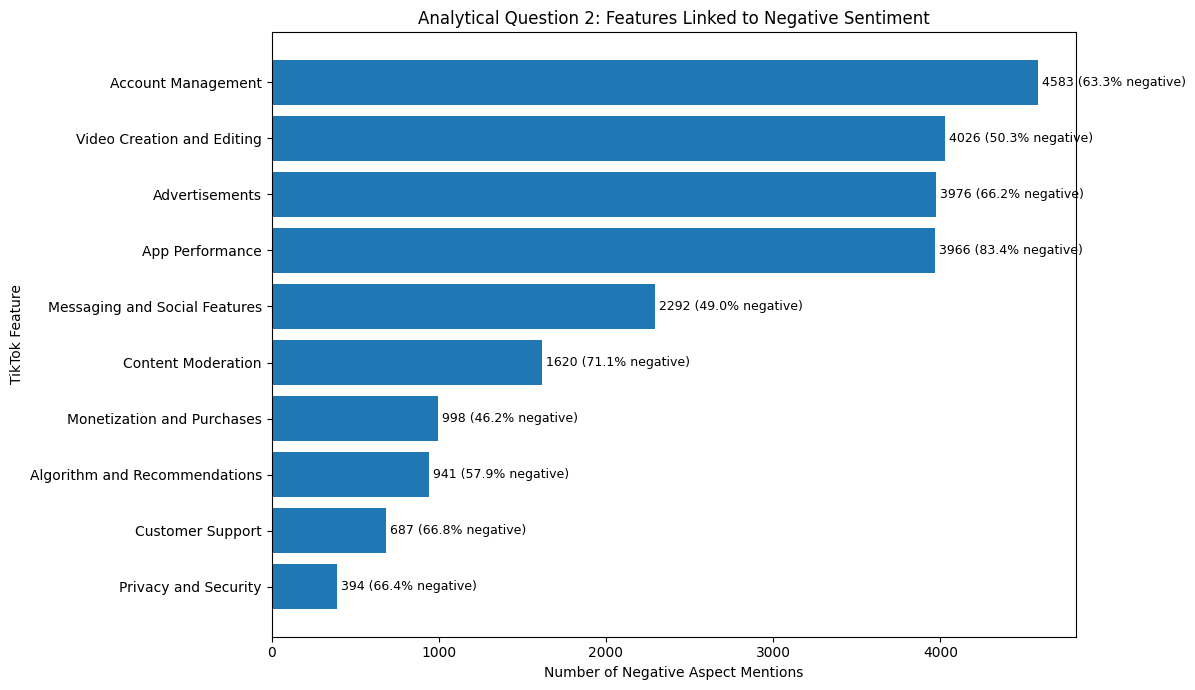

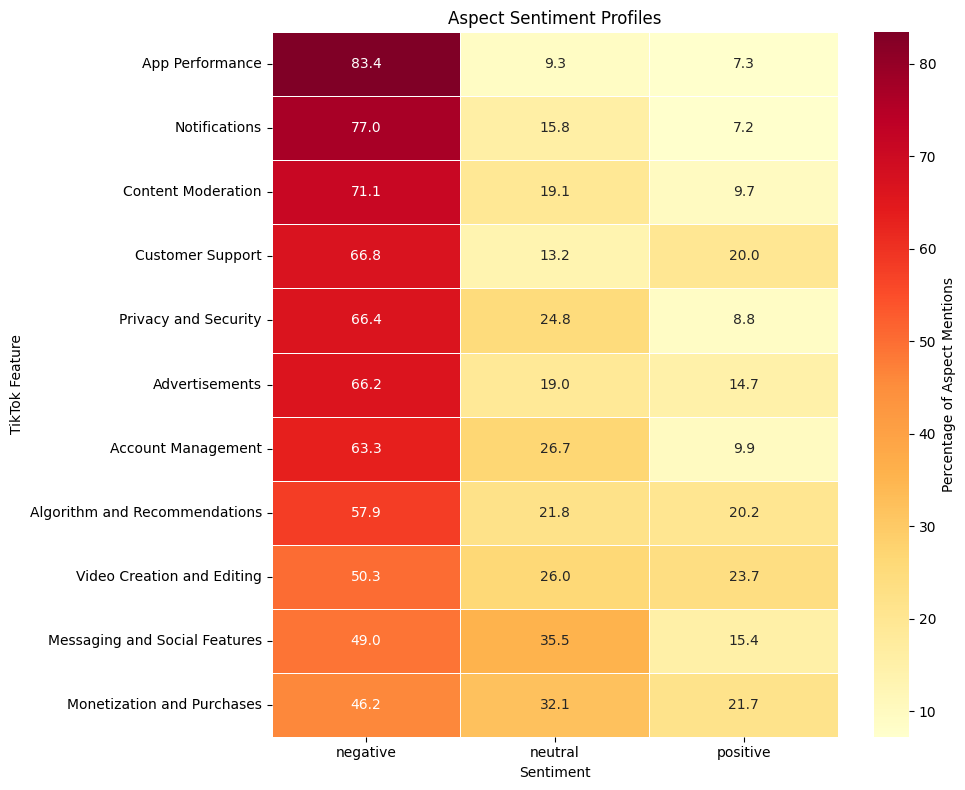

Answer: Account Management has the highest complaint priority by negative volume (4583 negative mentions; 63.34% negative rate).
✅ Saved: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/analytical_questions/question2_negative_aspect_volume.png
✅ Saved: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/analytical_questions/question2_aspect_sentiment_heatmap.png


In [ ]:
negative_aspect_summary_df = (
    aspect_sentiment_counts
    .reset_index()
)

negative_aspect_summary_df[
    "total_mentions"
] = (
    negative_aspect_summary_df[
        SENTIMENT_ORDER
    ]
    .sum(axis=1)
)

negative_aspect_summary_df[
    "negative_rate"
] = (
    negative_aspect_summary_df["negative"]
    / negative_aspect_summary_df["total_mentions"]
    * 100
)

MINIMUM_ASPECT_MENTIONS = 5

reliable_negative_aspects_df = (
    negative_aspect_summary_df[
        negative_aspect_summary_df[
            "total_mentions"
        ] >= MINIMUM_ASPECT_MENTIONS
    ]
    .sort_values(
        [
            "negative",
            "negative_rate"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    reliable_negative_aspects_df.style.format({
        "negative_rate": "{:.2f}%"
    })
)

top_negative_aspects_df = (
    reliable_negative_aspects_df
    .head(10)
    .sort_values(
        "negative",
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_negative_aspects_df["aspect_category"],
    top_negative_aspects_df["negative"]
)

plt.title(
    "Analytical Question 2: "
    "Features Linked to Negative Sentiment"
)
plt.xlabel(
    "Number of Negative Aspect Mentions"
)
plt.ylabel(
    "TikTok Feature"
)

for bar, count, rate in zip(
    bars,
    top_negative_aspects_df["negative"],
    top_negative_aspects_df["negative_rate"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {int(count)} ({rate:.1f}% negative)",
        va="center",
        fontsize=9
    )

plt.tight_layout()

QUESTION2_VOLUME_FIGURE = os.path.join(
    PHASE12_ANALYTICAL_DIR,
    "question2_negative_aspect_volume.png"
)

plt.savefig(
    QUESTION2_VOLUME_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

aspect_heatmap_df = (
    aspect_sentiment_counts
    .div(
        aspect_sentiment_counts.sum(axis=1),
        axis=0
    )
    .mul(100)
)

aspect_heatmap_df = aspect_heatmap_df.loc[
    aspect_heatmap_df["negative"]
    .sort_values(
        ascending=False
    )
    .index
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    aspect_heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={
        "label": "Percentage of Aspect Mentions"
    }
)

plt.title(
    "Aspect Sentiment Profiles"
)
plt.xlabel("Sentiment")
plt.ylabel("TikTok Feature")
plt.tight_layout()

QUESTION2_HEATMAP_FIGURE = os.path.join(
    PHASE12_ANALYTICAL_DIR,
    "question2_aspect_sentiment_heatmap.png"
)

plt.savefig(
    QUESTION2_HEATMAP_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

top_negative_feature = (
    reliable_negative_aspects_df.iloc[0]
)

print(
    f"Answer: {top_negative_feature['aspect_category']} "
    f"has the highest complaint priority by negative volume "
    f"({int(top_negative_feature['negative'])} negative mentions; "
    f"{top_negative_feature['negative_rate']:.2f}% negative rate)."
)

print(f"✅ Saved: {QUESTION2_VOLUME_FIGURE}")
print(f"✅ Saved: {QUESTION2_HEATMAP_FIGURE}")

### 12.7.3 Analytical Question 3 — Performance Differences Across Model Paradigms

- **SVM** uses TF-IDF and is computationally efficient, but it has limited understanding of context and word order.
- **GRU** learns sequential patterns and embeddings from the project dataset, but it is more sensitive to sample size, initialization, class imbalance and noisy pseudo-labels.
- **BERT** begins with pretrained contextual language knowledge and is better suited to informal wording, negation and context, but it requires greater training and inference resources.

,Model,Paradigm,Accuracy Mean,Accuracy Std,Macro F1 Mean,Macro F1 Std,Training Time (Seconds) Mean,Inference Time (Seconds) Mean,Interpretation
0,BERT,Transformer,0.8922,0.0076,0.8777,0.0072,105.92,3.21,Uses pretrained contextual representations; better at informal wording and context but more computationally costly.
1,GRU,Deep Learning,0.8291,0.0043,0.8025,0.0061,47.52,1.68,"Learns sequence patterns from project data; more sensitive to limited data, initialization and label noise."
2,SVM,Traditional Machine Learning,0.8260,0.0062,0.8005,0.0063,0.52,0.06,Fast TF-IDF baseline; strong lexical pattern detection but limited contextual understanding.


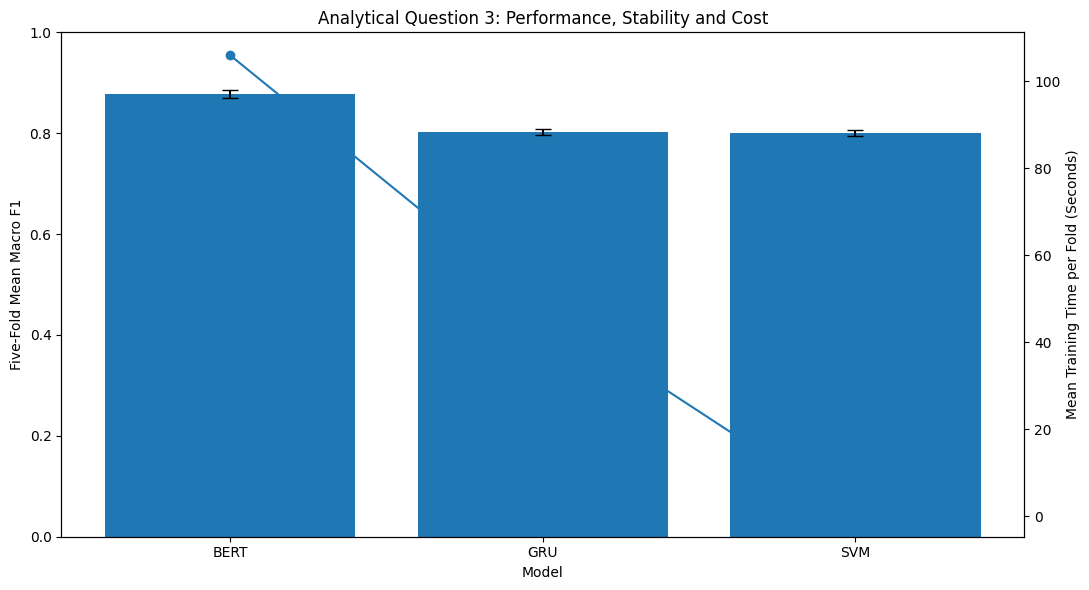

Best performance: BERT (Macro F1=0.8777).
Fastest training: SVM (0.52s per fold on average).
Most stable: GRU (Macro F1 standard deviation=0.0061).
✅ Saved: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/analytical_questions/question3_model_performance_and_cost.png


In [ ]:
model_analysis_df = phase12_cv_df[
    [
        "Model",
        "Paradigm",
        "Accuracy Mean",
        "Accuracy Std",
        "Macro F1 Mean",
        "Macro F1 Std",
        "Training Time (Seconds) Mean",
        "Inference Time (Seconds) Mean"
    ]
].copy()

model_analysis_df["Interpretation"] = (
    model_analysis_df["Model"]
    .map({
        "SVM": (
            "Fast TF-IDF baseline; strong lexical pattern detection "
            "but limited contextual understanding."
        ),
        "GRU": (
            "Learns sequence patterns from project data; more sensitive "
            "to limited data, initialization and label noise."
        ),
        "BERT": (
            "Uses pretrained contextual representations; better at "
            "informal wording and context but more computationally costly."
        )
    })
)

display(
    model_analysis_df.style.format({
        "Accuracy Mean": "{:.4f}",
        "Accuracy Std": "{:.4f}",
        "Macro F1 Mean": "{:.4f}",
        "Macro F1 Std": "{:.4f}",
        "Training Time (Seconds) Mean": "{:.2f}",
        "Inference Time (Seconds) Mean": "{:.2f}"
    })
)

figure, first_axis = plt.subplots(
    figsize=(11, 6)
)

bars = first_axis.bar(
    model_analysis_df["Model"],
    model_analysis_df["Macro F1 Mean"],
    yerr=model_analysis_df["Macro F1 Std"],
    capsize=6
)

first_axis.set_title(
    "Analytical Question 3: "
    "Performance, Stability and Cost"
)
first_axis.set_xlabel("Model")
first_axis.set_ylabel("Five-Fold Mean Macro F1")
first_axis.set_ylim(0, 1)

second_axis = first_axis.twinx()

second_axis.plot(
    model_analysis_df["Model"],
    model_analysis_df[
        "Training Time (Seconds) Mean"
    ],
    marker="o"
)

second_axis.set_ylabel(
    "Mean Training Time per Fold (Seconds)"
)

figure.tight_layout()

QUESTION3_FIGURE = os.path.join(
    PHASE12_ANALYTICAL_DIR,
    "question3_model_performance_and_cost.png"
)

plt.savefig(
    QUESTION3_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

best_model_row = (
    model_analysis_df
    .sort_values(
        "Macro F1 Mean",
        ascending=False
    )
    .iloc[0]
)

fastest_model_row = (
    model_analysis_df
    .sort_values(
        "Training Time (Seconds) Mean",
        ascending=True
    )
    .iloc[0]
)

most_stable_model_row = (
    model_analysis_df
    .sort_values(
        "Macro F1 Std",
        ascending=True
    )
    .iloc[0]
)

print(
    f"Best performance: {best_model_row['Model']} "
    f"(Macro F1={best_model_row['Macro F1 Mean']:.4f})."
)

print(
    f"Fastest training: {fastest_model_row['Model']} "
    f"({fastest_model_row['Training Time (Seconds) Mean']:.2f}s "
    f"per fold on average)."
)

print(
    f"Most stable: {most_stable_model_row['Model']} "
    f"(Macro F1 standard deviation="
    f"{most_stable_model_row['Macro F1 Std']:.4f})."
)

print(f"✅ Saved: {QUESTION3_FIGURE}")

### 12.7.4 Analytical Question 4 — Complaint Profiles and Actionable Insights

A priority score combines negative complaint volume and negative rate. The resulting complaint profiles are linked to specific product recommendations.

,priority_rank,aspect_category,negative,negative_rate,priority_score,complaint_profile,recommended_action,representative_negative_complaint
0,1,Account Management,4583,63.34%,0.853,Frequent Complaint,"Improve login recovery, account verification, ban explanations and appeal tracking.",I’m facing multiple issues on my account.
1,2,App Performance,3966,83.39%,0.853,Critical: High Volume and High Severity,"Prioritize crash, lag, loading, freezing, battery and device-compatibility fixes.",and they want update daily useless.
2,3,Advertisements,3976,66.24%,0.786,Critical: High Volume and High Severity,Reduce repetitive advertisements and add advertisement-frequency controls.,also the ads are getting out of hand.
3,4,Video Creation and Editing,4026,50.29%,0.728,Frequent Complaint,"Improve upload reliability, draft recovery, filters, sounds and editing tools.",half the time videos won't play.
4,5,Content Moderation,1620,71.15%,0.497,Critical: High Volume and High Severity,"Provide clearer removal reasons, guideline explanations and faster moderation appeals.",the report centre still doesn't do its job properly.
5,6,Messaging and Social Features,2292,49.03%,0.496,Frequent Complaint,"Improve message delivery, comments, sharing and follower-related reliability.","Sharing is also broken, it sends a genetic tiktok link instead of a link to the specific video I'm trying to share."
6,7,Customer Support,687,66.76%,0.357,High Severity but Lower Volume,Reduce support-response time and provide clear case-status updates.,The customer support declined my refund request around 4 times.
7,8,Algorithm and Recommendations,941,57.91%,0.355,Monitor,Provide stronger feed controls and clearer recommendation settings.,"The algorithm often has issues, I'm not interested in 80% of what it shows me."
8,9,Notifications,234,76.97%,0.339,High Severity but Lower Volume,Offer more detailed notification controls and reduce unnecessary alerts.,The notifications are not working
9,10,Privacy and Security,394,66.44%,0.317,High Severity but Lower Volume,"Improve permission transparency, privacy controls and data-use explanations.",the problem I have is their security.


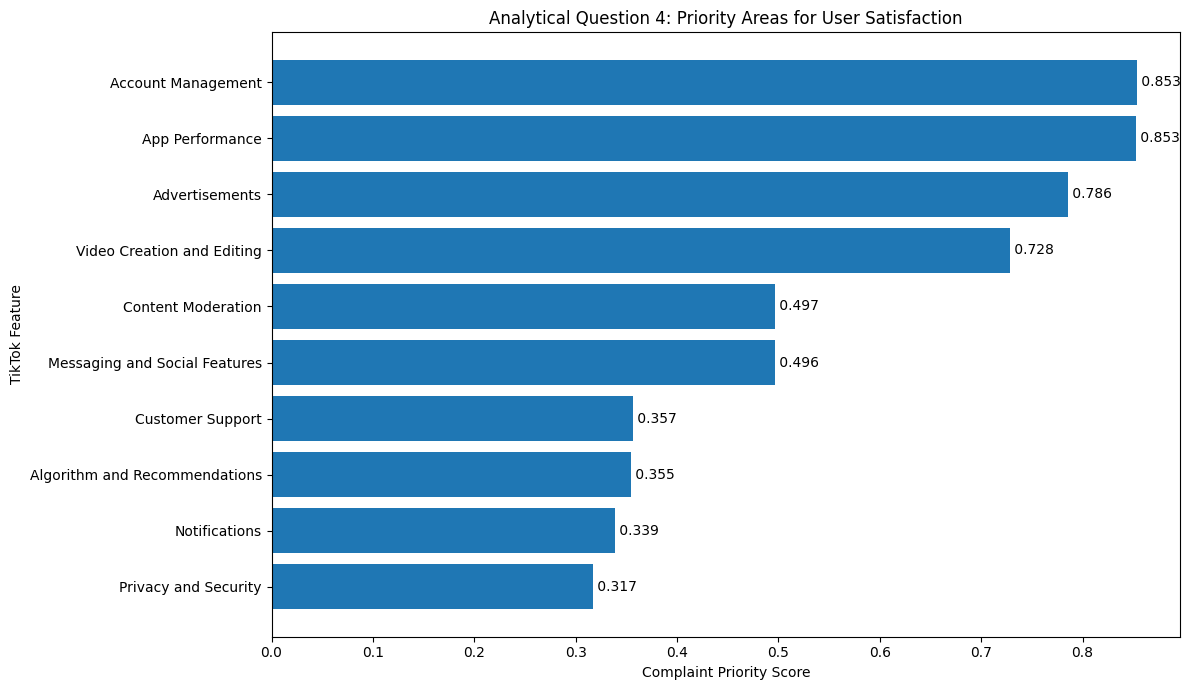

✅ Saved: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/analytical_questions/question4_actionable_priority_ranking.png
✅ Saved: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/analytical_questions/question4_actionable_insights.csv


In [ ]:
ACTION_RECOMMENDATIONS = {
    "Account Management": (
        "Improve login recovery, account verification, "
        "ban explanations and appeal tracking."
    ),
    "Content Moderation": (
        "Provide clearer removal reasons, guideline explanations "
        "and faster moderation appeals."
    ),
    "App Performance": (
        "Prioritize crash, lag, loading, freezing, battery "
        "and device-compatibility fixes."
    ),
    "Algorithm and Recommendations": (
        "Provide stronger feed controls and clearer "
        "recommendation settings."
    ),
    "Advertisements": (
        "Reduce repetitive advertisements and add "
        "advertisement-frequency controls."
    ),
    "Privacy and Security": (
        "Improve permission transparency, privacy controls "
        "and data-use explanations."
    ),
    "Messaging and Social Features": (
        "Improve message delivery, comments, sharing "
        "and follower-related reliability."
    ),
    "Video Creation and Editing": (
        "Improve upload reliability, draft recovery, "
        "filters, sounds and editing tools."
    ),
    "Customer Support": (
        "Reduce support-response time and provide "
        "clear case-status updates."
    ),
    "Notifications": (
        "Offer more detailed notification controls "
        "and reduce unnecessary alerts."
    ),
    "Monetization and Purchases": (
        "Improve payment transparency, refunds "
        "and purchase reliability."
    )
}

actionable_insights_df = (
    reliable_negative_aspects_df.copy()
)

maximum_negative_count = max(
    actionable_insights_df["negative"].max(),
    1
)

actionable_insights_df[
    "volume_score"
] = (
    actionable_insights_df["negative"]
    / maximum_negative_count
)

actionable_insights_df[
    "severity_score"
] = (
    actionable_insights_df["negative_rate"]
    / 100
)

actionable_insights_df[
    "priority_score"
] = (
    actionable_insights_df["volume_score"] * 0.60
    + actionable_insights_df["severity_score"] * 0.40
)

median_negative_volume = (
    actionable_insights_df["negative"].median()
)

median_negative_rate = (
    actionable_insights_df["negative_rate"].median()
)

profile_conditions = [
    (
        actionable_insights_df["negative"]
        >= median_negative_volume
    )
    & (
        actionable_insights_df["negative_rate"]
        >= median_negative_rate
    ),
    (
        actionable_insights_df["negative"]
        >= median_negative_volume
    ),
    (
        actionable_insights_df["negative_rate"]
        >= median_negative_rate
    )
]

profile_labels = [
    "Critical: High Volume and High Severity",
    "Frequent Complaint",
    "High Severity but Lower Volume"
]

actionable_insights_df[
    "complaint_profile"
] = np.select(
    profile_conditions,
    profile_labels,
    default="Monitor"
)

actionable_insights_df[
    "recommended_action"
] = (
    actionable_insights_df["aspect_category"]
    .map(ACTION_RECOMMENDATIONS)
    .fillna(
        "Review representative complaints and investigate "
        "the underlying product issue."
    )
)

negative_examples_df = (
    phase12_absa_df[
        phase12_absa_df["aspect_sentiment"]
        == "negative"
    ]
    .copy()
)

if "absa_confidence" in negative_examples_df.columns:
    negative_examples_df = (
        negative_examples_df
        .sort_values(
            "absa_confidence",
            ascending=False
        )
    )

negative_examples_df = (
    negative_examples_df
    .drop_duplicates(
        subset=["aspect_category"]
    )
    [
        [
            "aspect_category",
            "sentence"
        ]
    ]
    .rename(
        columns={
            "sentence": (
                "representative_negative_complaint"
            )
        }
    )
)

actionable_insights_df = (
    actionable_insights_df
    .merge(
        negative_examples_df,
        on="aspect_category",
        how="left"
    )
    .sort_values(
        "priority_score",
        ascending=False
    )
    .reset_index(drop=True)
)

actionable_insights_df.insert(
    0,
    "priority_rank",
    np.arange(
        1,
        len(actionable_insights_df) + 1
    )
)

display(
    actionable_insights_df[
        [
            "priority_rank",
            "aspect_category",
            "negative",
            "negative_rate",
            "priority_score",
            "complaint_profile",
            "recommended_action",
            "representative_negative_complaint"
        ]
    ]
    .head(10)
    .style
    .format({
        "negative_rate": "{:.2f}%",
        "priority_score": "{:.3f}"
    })
)

top_priorities_df = (
    actionable_insights_df
    .head(10)
    .sort_values(
        "priority_score",
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_priorities_df["aspect_category"],
    top_priorities_df["priority_score"]
)

plt.title(
    "Analytical Question 4: "
    "Priority Areas for User Satisfaction"
)
plt.xlabel("Complaint Priority Score")
plt.ylabel("TikTok Feature")

for bar, score in zip(
    bars,
    top_priorities_df["priority_score"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {score:.3f}",
        va="center"
    )

plt.tight_layout()

QUESTION4_PRIORITY_FIGURE = os.path.join(
    PHASE12_ANALYTICAL_DIR,
    "question4_actionable_priority_ranking.png"
)

plt.savefig(
    QUESTION4_PRIORITY_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

QUESTION4_INSIGHTS_FILE = os.path.join(
    PHASE12_ANALYTICAL_DIR,
    "question4_actionable_insights.csv"
)

actionable_insights_df.to_csv(
    QUESTION4_INSIGHTS_FILE,
    index=False
)

print(f"✅ Saved: {QUESTION4_PRIORITY_FIGURE}")
print(f"✅ Saved: {QUESTION4_INSIGHTS_FILE}")

### 12.7.5 N-Gram Evidence for Complaint Profiles

Negative ABSA sentences are analyzed using:

- **Bigrams:** two-word patterns such as `cannot login`.
- **Trigrams:** three-word patterns such as `app keeps crashing`.
- **Four-grams:** four-word patterns such as `cannot log into account`.

N-grams support the aspect-level findings by showing the repeated wording behind each complaint profile.

,ngram,frequency,document_frequency,ngram_size,ngram_type
0,tiktok team,424,400,2,Bigram
1,tiktok account,408,376,2,Bigram
2,community guidelines,348,333,2,Bigram
3,no reason,334,319,2,Bigram
4,hello tiktok,247,247,2,Bigram
...,...,...,...,...,...
70,check account unfreeze thanks,26,26,4,Four-gram
71,not solved tense solve,26,26,4,Four-gram
72,solved tense solve problem,26,26,4,Four-gram
73,worried problem not solved,26,26,4,Four-gram


,aspect_category,ngram_type,rank,complaint_phrase,frequency,document_frequency
0,Account Management,Bigram,1,tiktok account,231,217
1,Account Management,Bigram,2,no reason,167,161
2,Account Management,Bigram,3,tiktok team,153,143
3,Account Management,Bigram,4,got banned,101,101
4,Account Management,Bigram,5,community guidelines,83,81
5,Account Management,Trigram,1,banned no reason,64,64
6,Account Management,Trigram,2,hello tiktok team,60,60
7,Account Management,Trigram,3,account permanently banned,47,47
8,Account Management,Trigram,4,tiktok team account,37,37
9,Account Management,Trigram,5,violations community guidelines,35,35


,priority_rank,aspect_category,complaint_profile,Bigram,Trigram,Four-gram,recommended_action
0,1,Account Management,Frequent Complaint,tiktok account; no reason; tiktok team; got ba...,banned no reason; hello tiktok team; account p...,multiple violations community guidelines; acco...,"Improve login recovery, account verification, ..."
1,2,App Performance,Critical: High Volume and High Severity,unfreeze account; keeps crashing; tiktok team;...,app keeps crashing; check account unfreeze; ti...,check account unfreeze thanks; tiktok team unf...,"Prioritize crash, lag, loading, freezing, batt..."
2,3,Advertisements,Critical: High Volume and High Severity,bad app; no reason; ai remix; download app; it...,banned no reason; time open app; added ai remi...,mistake tiktok police account; not mistake tik...,Reduce repetitive advertisements and add adver...
3,4,Video Creation and Editing,Frequent Complaint,ai remix; videos not; video not; single video;...,ai remix videos; hello tiktok team; videos use...,forced ai remix videos; videos not getting vie...,"Improve upload reliability, draft recovery, fi..."
4,5,Content Moderation,Critical: High Volume and High Severity,community guidelines; permanently banned; acco...,account permanently banned; violations communi...,multiple violations community guidelines; acco...,"Provide clearer removal reasons, guideline exp..."
5,6,Messaging and Social Features,Frequent Complaint,can't send; community guidelines; comment sect...,tiktok message not; send receive messages; sen...,problem tiktok message not; tiktok message not...,"Improve message delivery, comments, sharing an..."
6,7,Customer Support,High Severity but Lower Volume,tiktok support; support team; customer service...,tiktok support team; hello tiktok support; dea...,hello tiktok support team; dear tiktok support...,Reduce support-response time and provide clear...
7,8,Algorithm and Recommendations,Monitor,waste time; not interested; algorithm sucks; t...,time wasting app; app waste time; i'm not inte...,age checks easily let; algorithm feed toxic tr...,Provide stronger feed controls and clearer rec...
8,9,Notifications,High Severity but Lower Volume,getting notifications; don't notifications; li...,not getting notifications; algorithm creates s...,algorithm creates specifically best; appear no...,Offer more detailed notification controls and ...
9,10,Privacy and Security,High Severity but Lower Volume,security reasons; ai remix; invasion privacy; ...,ai use content; account business account; proc...,ai use content permission; couldn't proceed se...,"Improve permission transparency, privacy contr..."


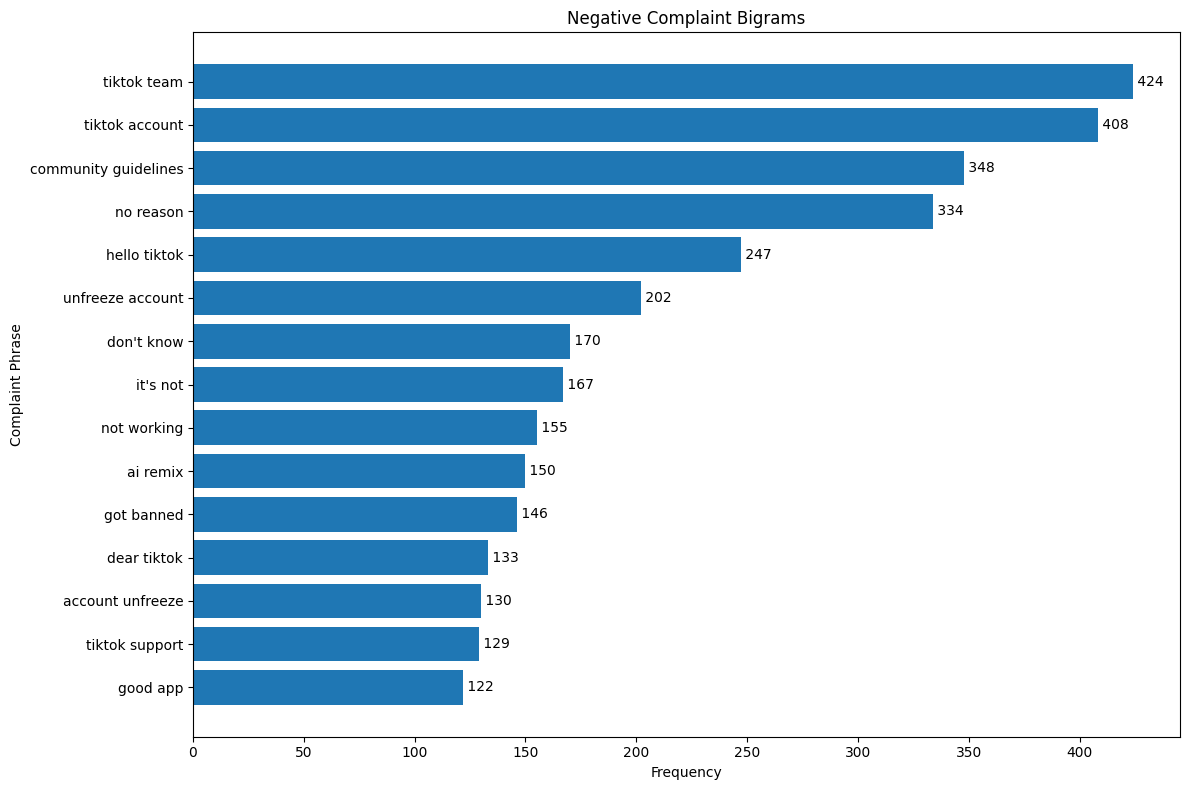

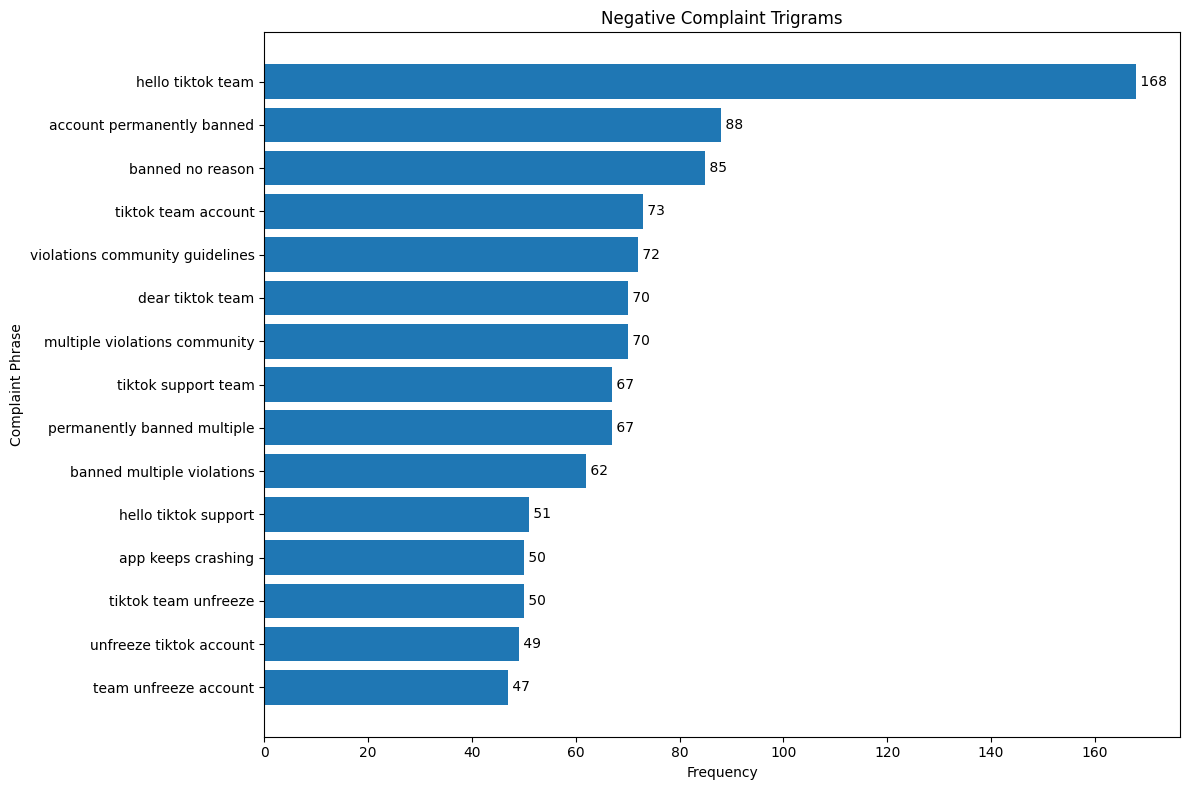

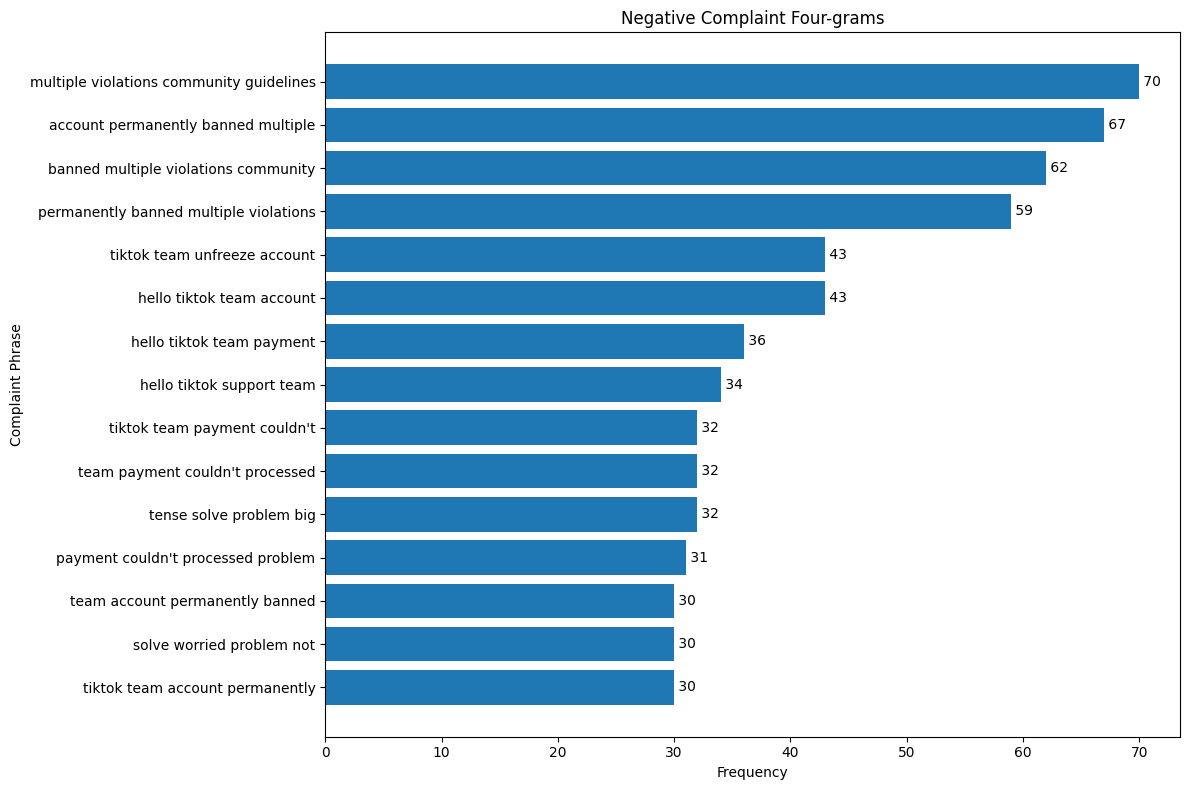

✅ N-gram complaint evidence saved.
   Overall phrases : /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/analytical_questions/question4_overall_negative_ngrams.csv
   Aspect phrases  : /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/analytical_questions/question4_aspect_negative_ngrams.csv
   Actionable table: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/analytical_questions/question4_actionable_insights_with_ngrams.csv


In [ ]:
from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS
)

negative_complaints_df = (
    phase12_absa_df[
        phase12_absa_df["aspect_sentiment"]
        == "negative"
    ]
    .copy()
)

negative_complaints_df["sentence"] = (
    negative_complaints_df["sentence"]
    .fillna("")
    .astype(str)
)

deduplication_columns = [
    column
    for column in [
        "review_id",
        "aspect_category",
        "sentence"
    ]
    if column in negative_complaints_df.columns
]

negative_complaints_df = (
    negative_complaints_df
    .drop_duplicates(
        subset=deduplication_columns
    )
    .reset_index(drop=True)
)

NEGATION_WORDS = {
    "no",
    "not",
    "nor",
    "never",
    "cannot"
}

NGRAM_STOP_WORDS = list(
    set(ENGLISH_STOP_WORDS)
    - NEGATION_WORDS
)

GENERIC_NGRAMS = {
    "this app",
    "the app",
    "tik tok",
    "tiktok app",
    "please fix",
    "please fix app"
}


def clean_ngram_text(text_series):
    return (
        text_series
        .fillna("")
        .astype(str)
        .str.lower()
        .str.replace(
            r"https?://\S+|www\.\S+",
            " ",
            regex=True
        )
        .str.replace(
            r"[^a-z0-9\s']",
            " ",
            regex=True
        )
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
        .str.strip()
    )


def extract_exact_ngrams(
    text_series,
    ngram_size,
    top_n=20,
    minimum_document_frequency=2
):
    clean_texts = clean_ngram_text(
        text_series
    )

    clean_texts = clean_texts[
        clean_texts.str.len() > 0
    ]

    empty_result = pd.DataFrame(
        columns=[
            "ngram",
            "frequency",
            "document_frequency",
            "ngram_size"
        ]
    )

    if clean_texts.empty:
        return empty_result

    actual_min_df = (
        minimum_document_frequency
        if len(clean_texts) >= 10
        else 1
    )

    vectorizer = CountVectorizer(
        ngram_range=(
            ngram_size,
            ngram_size
        ),
        stop_words=NGRAM_STOP_WORDS,
        min_df=actual_min_df,
        token_pattern=(
            r"(?u)\b[a-zA-Z]"
            r"[a-zA-Z']+\b"
        )
    )

    try:
        matrix = vectorizer.fit_transform(
            clean_texts
        )
    except ValueError:
        return empty_result

    ngram_names = (
        vectorizer
        .get_feature_names_out()
    )

    total_frequencies = np.asarray(
        matrix.sum(axis=0)
    ).ravel()

    document_frequencies = np.asarray(
        (matrix > 0).sum(axis=0)
    ).ravel()

    result = pd.DataFrame({
        "ngram": ngram_names,
        "frequency": total_frequencies,
        "document_frequency": document_frequencies,
        "ngram_size": ngram_size
    })

    result = result[
        ~result["ngram"].isin(
            GENERIC_NGRAMS
        )
    ]

    return (
        result
        .sort_values(
            [
                "frequency",
                "document_frequency",
                "ngram"
            ],
            ascending=[
                False,
                False,
                True
            ]
        )
        .head(top_n)
        .reset_index(drop=True)
    )


overall_ngram_frames = []

for ngram_size in [2, 3, 4]:
    ngram_result = extract_exact_ngrams(
        negative_complaints_df["sentence"],
        ngram_size=ngram_size,
        top_n=25,
        minimum_document_frequency=2
    )

    ngram_result["ngram_type"] = {
        2: "Bigram",
        3: "Trigram",
        4: "Four-gram"
    }[ngram_size]

    overall_ngram_frames.append(
        ngram_result
    )

overall_negative_ngrams_df = pd.concat(
    overall_ngram_frames,
    ignore_index=True
)

display(overall_negative_ngrams_df)

aspect_ngram_records = []

for aspect_category, aspect_group in (
    negative_complaints_df
    .groupby("aspect_category")
):
    for ngram_size in [2, 3, 4]:
        aspect_ngrams = extract_exact_ngrams(
            aspect_group["sentence"],
            ngram_size=ngram_size,
            top_n=5,
            minimum_document_frequency=2
        )

        for rank, row in aspect_ngrams.iterrows():
            aspect_ngram_records.append({
                "aspect_category": aspect_category,
                "ngram_type": {
                    2: "Bigram",
                    3: "Trigram",
                    4: "Four-gram"
                }[ngram_size],
                "rank": rank + 1,
                "complaint_phrase": row["ngram"],
                "frequency": int(
                    row["frequency"]
                ),
                "document_frequency": int(
                    row["document_frequency"]
                )
            })

aspect_ngrams_df = pd.DataFrame(
    aspect_ngram_records
)

display(aspect_ngrams_df.head(50))

if aspect_ngrams_df.empty:
    aspect_ngram_summary_df = pd.DataFrame({
        "aspect_category": (
            actionable_insights_df[
                "aspect_category"
            ]
        )
    })
else:
    aspect_ngram_summary_df = (
        aspect_ngrams_df
        .sort_values(
            [
                "aspect_category",
                "ngram_type",
                "rank"
            ]
        )
        .groupby(
            [
                "aspect_category",
                "ngram_type"
            ]
        )["complaint_phrase"]
        .apply(
            lambda phrases: "; ".join(
                phrases
            )
        )
        .unstack(
            fill_value=""
        )
        .reset_index()
    )

actionable_insights_with_ngrams_df = (
    actionable_insights_df
    .merge(
        aspect_ngram_summary_df,
        on="aspect_category",
        how="left"
    )
)

for ngram_column in [
    "Bigram",
    "Trigram",
    "Four-gram"
]:
    if ngram_column not in (
        actionable_insights_with_ngrams_df.columns
    ):
        actionable_insights_with_ngrams_df[
            ngram_column
        ] = ""

    actionable_insights_with_ngrams_df[
        ngram_column
    ] = (
        actionable_insights_with_ngrams_df[
            ngram_column
        ]
        .fillna(
            "No repeated phrase met "
            "the minimum frequency."
        )
        .replace(
            "",
            "No repeated phrase met "
            "the minimum frequency."
        )
    )

display(
    actionable_insights_with_ngrams_df[
        [
            "priority_rank",
            "aspect_category",
            "complaint_profile",
            "Bigram",
            "Trigram",
            "Four-gram",
            "recommended_action"
        ]
    ].head(10)
)

for ngram_type in [
    "Bigram",
    "Trigram",
    "Four-gram"
]:
    plot_data = (
        overall_negative_ngrams_df[
            overall_negative_ngrams_df[
                "ngram_type"
            ] == ngram_type
        ]
        .head(15)
        .sort_values(
            "frequency",
            ascending=True
        )
    )

    if plot_data.empty:
        print(
            f"⚠️ No repeated {ngram_type.lower()} "
            f"met the minimum frequency."
        )
        continue

    plt.figure(figsize=(12, 8))

    bars = plt.barh(
        plot_data["ngram"],
        plot_data["frequency"]
    )

    plt.title(
        f"Negative Complaint {ngram_type}s"
    )
    plt.xlabel("Frequency")
    plt.ylabel("Complaint Phrase")

    for bar, frequency in zip(
        bars,
        plot_data["frequency"]
    ):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {int(frequency)}",
            va="center"
        )

    plt.tight_layout()

    ngram_figure_file = os.path.join(
        PHASE12_ANALYTICAL_DIR,
        (
            "question4_negative_"
            f"{ngram_type.lower().replace('-', '')}s.png"
        )
    )

    plt.savefig(
        ngram_figure_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

OVERALL_NGRAM_FILE = os.path.join(
    PHASE12_ANALYTICAL_DIR,
    "question4_overall_negative_ngrams.csv"
)

ASPECT_NGRAM_FILE = os.path.join(
    PHASE12_ANALYTICAL_DIR,
    "question4_aspect_negative_ngrams.csv"
)

ACTIONABLE_NGRAM_FILE = os.path.join(
    PHASE12_ANALYTICAL_DIR,
    "question4_actionable_insights_with_ngrams.csv"
)

overall_negative_ngrams_df.to_csv(
    OVERALL_NGRAM_FILE,
    index=False
)

aspect_ngrams_df.to_csv(
    ASPECT_NGRAM_FILE,
    index=False
)

actionable_insights_with_ngrams_df.to_csv(
    ACTIONABLE_NGRAM_FILE,
    index=False
)

print("✅ N-gram complaint evidence saved.")
print(f"   Overall phrases : {OVERALL_NGRAM_FILE}")
print(f"   Aspect phrases  : {ASPECT_NGRAM_FILE}")
print(f"   Actionable table: {ACTIONABLE_NGRAM_FILE}")

### 12.7.6 Automatic Analytical Summary

This cell prints and saves a concise evidence-based response to all four analytical questions. The text should be checked against the generated tables before being copied into the report.

In [ ]:
top_action_row = (
    actionable_insights_with_ngrams_df
    .sort_values(
        "priority_score",
        ascending=False
    )
    .iloc[0]
)

analytical_summary_lines = [
    "ANALYTICAL QUESTION 1 — SENTIMENT DISTRIBUTION",
    (
        f"{dominant_sentiment_row['sentiment'].title()} "
        f"was the largest sentiment group, representing "
        f"{dominant_sentiment_row['percentage']:.2f}% "
        f"of the analyzed reviews."
    ),
    "",
    "ANALYTICAL QUESTION 2 — NEGATIVE FEATURES",
    (
        f"{top_negative_feature['aspect_category']} had the "
        f"highest negative complaint volume in the reliable "
        f"aspect groups, with "
        f"{int(top_negative_feature['negative'])} negative mentions "
        f"and a negative rate of "
        f"{top_negative_feature['negative_rate']:.2f}%."
    ),
    "",
    "ANALYTICAL QUESTION 3 — MODEL DIFFERENCES",
    (
        f"{best_model_row['Model']} achieved the strongest "
        f"five-fold mean Macro F1 "
        f"({best_model_row['Macro F1 Mean']:.4f}). "
        f"{fastest_model_row['Model']} was the fastest to train, "
        f"while {most_stable_model_row['Model']} had the lowest "
        f"fold-to-fold Macro F1 variation."
    ),
    "",
    "ANALYTICAL QUESTION 4 — ACTIONABLE INSIGHTS",
    (
        f"The highest-priority improvement area was "
        f"{top_action_row['aspect_category']}. "
        f"Recommended action: "
        f"{top_action_row['recommended_action']}"
    ),
    (
        f"Repeated complaint evidence — "
        f"Bigram: {top_action_row['Bigram']}; "
        f"Trigram: {top_action_row['Trigram']}; "
        f"Four-gram: {top_action_row['Four-gram']}."
    )
]

analytical_summary_text = "\n".join(
    analytical_summary_lines
)

print("=" * 78)
print("FINAL ANALYTICAL SUMMARY")
print("=" * 78)
print(analytical_summary_text)

ANALYTICAL_SUMMARY_FILE = os.path.join(
    PHASE12_ANALYTICAL_DIR,
    "analytical_questions_summary.txt"
)

with open(
    ANALYTICAL_SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as file:
    file.write(
        analytical_summary_text
    )

print(
    f"\n✅ Analytical summary saved: "
    f"{ANALYTICAL_SUMMARY_FILE}"
)

FINAL ANALYTICAL SUMMARY
ANALYTICAL QUESTION 1 — SENTIMENT DISTRIBUTION
Positive was the largest sentiment group, representing 52.38% of the analyzed reviews.

ANALYTICAL QUESTION 2 — NEGATIVE FEATURES
Account Management had the highest negative complaint volume in the reliable aspect groups, with 4583 negative mentions and a negative rate of 63.34%.

ANALYTICAL QUESTION 3 — MODEL DIFFERENCES
BERT achieved the strongest five-fold mean Macro F1 (0.8777). SVM was the fastest to train, while GRU had the lowest fold-to-fold Macro F1 variation.

ANALYTICAL QUESTION 4 — ACTIONABLE INSIGHTS
The highest-priority improvement area was Account Management. Recommended action: Improve login recovery, account verification, ban explanations and appeal tracking.
Repeated complaint evidence — Bigram: tiktok account; no reason; tiktok team; got banned; community guidelines; Trigram: banned no reason; hello tiktok team; account permanently banned; tiktok team account; violations community guidelines; Fou

## 12.8 Visualization Output Manifest

In [ ]:
visualization_manifest = pd.DataFrame([
    {
        "section": "Core Visualization",
        "output": "Overall sentiment distribution",
        "file": SENTIMENT_DISTRIBUTION_FILE,
        "format": "PNG"
    },
    {
        "section": "Core Visualization",
        "output": "Positive and negative word clouds",
        "file": WORDCLOUD_FILE,
        "format": "PNG"
    },
    {
        "section": "Core Visualization",
        "output": "Aspect sentiment distribution",
        "file": ASPECT_SENTIMENT_FILE,
        "format": "PNG"
    },
    {
        "section": "Core Visualization",
        "output": "Held-out model performance",
        "file": HELD_OUT_MODEL_FILE,
        "format": "PNG"
    },
    {
        "section": "Core Visualization",
        "output": "Five-fold Macro F1 comparison",
        "file": CV_MODEL_FILE,
        "format": "PNG"
    },
    {
        "section": "Analytical Question 1",
        "output": "Sentiment distribution",
        "file": QUESTION1_FIGURE,
        "format": "PNG"
    },
    {
        "section": "Analytical Question 2",
        "output": "Negative aspect volume",
        "file": QUESTION2_VOLUME_FIGURE,
        "format": "PNG"
    },
    {
        "section": "Analytical Question 2",
        "output": "Aspect sentiment heatmap",
        "file": QUESTION2_HEATMAP_FIGURE,
        "format": "PNG"
    },
    {
        "section": "Analytical Question 3",
        "output": "Model performance and cost",
        "file": QUESTION3_FIGURE,
        "format": "PNG"
    },
    {
        "section": "Analytical Question 4",
        "output": "Actionable priority ranking",
        "file": QUESTION4_PRIORITY_FIGURE,
        "format": "PNG"
    },
    {
        "section": "Analytical Question 4",
        "output": "Actionable insights with N-grams",
        "file": ACTIONABLE_NGRAM_FILE,
        "format": "CSV"
    },
    {
        "section": "Analytical Questions",
        "output": "Automatic written summary",
        "file": ANALYTICAL_SUMMARY_FILE,
        "format": "TXT"
    }
])

VISUALIZATION_MANIFEST_FILE = os.path.join(
    PHASE12_OUTPUT_DIR,
    "visualization_manifest.csv"
)

visualization_manifest.to_csv(
    VISUALIZATION_MANIFEST_FILE,
    index=False
)

display(visualization_manifest)

print(
    f"✅ Phase 12 completed. Manifest saved to: "
    f"{VISUALIZATION_MANIFEST_FILE}"
)

,section,output,file,format
0,Core Visualization,Overall sentiment distribution,/content/drive/MyDrive/SMC_Assignment/phase_12...,PNG
1,Core Visualization,Positive and negative word clouds,/content/drive/MyDrive/SMC_Assignment/phase_12...,PNG
2,Core Visualization,Aspect sentiment distribution,/content/drive/MyDrive/SMC_Assignment/phase_12...,PNG
3,Core Visualization,Held-out model performance,/content/drive/MyDrive/SMC_Assignment/phase_12...,PNG
4,Core Visualization,Five-fold Macro F1 comparison,/content/drive/MyDrive/SMC_Assignment/phase_12...,PNG
5,Analytical Question 1,Sentiment distribution,/content/drive/MyDrive/SMC_Assignment/phase_12...,PNG
6,Analytical Question 2,Negative aspect volume,/content/drive/MyDrive/SMC_Assignment/phase_12...,PNG
7,Analytical Question 2,Aspect sentiment heatmap,/content/drive/MyDrive/SMC_Assignment/phase_12...,PNG
8,Analytical Question 3,Model performance and cost,/content/drive/MyDrive/SMC_Assignment/phase_12...,PNG
9,Analytical Question 4,Actionable priority ranking,/content/drive/MyDrive/SMC_Assignment/phase_12...,PNG


✅ Phase 12 completed. Manifest saved to: /content/drive/MyDrive/SMC_Assignment/phase_12_visualization/visualization_manifest.csv
